# stream

In [ ]:
import os
import os.path as op
import sys
import warnings
from pathlib import Path
from typing import Tuple, List

warnings.filterwarnings("ignore")


import numpy as np
import pandas as pd
import scipy.stats as stats
from scipy.ndimage import zoom


import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from nilearn import plotting


import nibabel as nib
from skimage import restoration


import joblib
import xgboost as xgb
import shap
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import (
    label_binarize,
    OneHotEncoder,
    PowerTransformer
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import (
    KNNImputer,
    SimpleImputer
)
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    matthews_corrcoef,
    balanced_accuracy_score,
    classification_report,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    auc,
    precision_recall_curve
)
from sklearn.calibration import calibration_curve


import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import DataLoader, Dataset


SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


creative_day = "0901"

save_dirs = [
    f"./pic/{creative_day}",
    f"./{creative_day}",
    f"./models_joint/{creative_day}",
    f"./index/{creative_day}",
]

for dir_path in save_dirs:
    os.makedirs(dir_path, exist_ok=True)

# structure

In [ ]:
def random_cutout_3d(img, max_ratio=0.2):
    if np.random.rand() < 0.5:
        return img
    d, h, w = img.shape[-3:]
    cut_d = int(d * max_ratio * np.random.rand())
    cut_h = int(h * max_ratio * np.random.rand())
    cut_w = int(w * max_ratio * np.random.rand())
    start_d = np.random.randint(0, d - cut_d)
    start_h = np.random.randint(0, h - cut_h)
    start_w = np.random.randint(0, w - cut_w)
    img[..., start_d:start_d+cut_d,
              start_h:start_h+cut_h,
              start_w:start_w+cut_w] = 0
    return img

def torch_random_cutout_3d(img_tensor, max_ratio=0.2):
    if torch.rand(1, device=img_tensor.device).item() > 0.5:
        return img_tensor

    d, h, w = img_tensor.shape[-3:]  
    cut_d = int(d * max_ratio * torch.rand(1, device=img_tensor.device).item())
    cut_h = int(h * max_ratio * torch.rand(1, device=img_tensor.device).item())
    cut_w = int(w * max_ratio * torch.rand(1, device=img_tensor.device).item())
    start_d = torch.randint(0, max(1, d - cut_d), (1,), device=img_tensor.device).item()
    start_h = torch.randint(0, max(1, h - cut_h), (1,), device=img_tensor.device).item()
    start_w = torch.randint(0, max(1, w - cut_w), (1,), device=img_tensor.device).item()
    
    img_masked = img_tensor.clone()
    img_masked[..., start_d:start_d+cut_d, 
                    start_h:start_h+cut_h, 
                    start_w:start_w+cut_w] = 0
    
    return img_masked

class RandomFeatureMask(nn.Module):
    def __init__(self, p: float = .15):
        super().__init__()
        self.p = p

    def forward(self, x: torch.Tensor):
        if not self.training or self.p == 0:
            mask = torch.ones_like(x)
            return x, mask
        keep_prob = 1 - self.p
        mask = torch.bernoulli(torch.full_like(x, keep_prob))
        return x * mask, mask

class LabelSmoothingLoss(nn.Module):
    def __init__(self, smoothing=0.2):
        super(LabelSmoothingLoss, self).__init__()
        self.smoothing = smoothing

    def forward(self, logits, target):
        
        target_smoothed = target * (1.0 - self.smoothing) + (1.0 - target) * (self.smoothing / (2.0))

        loss = nn.BCEWithLogitsLoss()(logits, target_smoothed)
        return loss

class MultiModalFusion(nn.Module):
    def __init__(self, img_shape, text_dim, num_dim):
        super(MultiModalFusion, self).__init__()
        
        self.img_model = ImageCNN3D(img_shape, output_dim=256)
        self.text_model = TextMLP(text_dim, output_dim=128)
        self.num_model = NumericMLP(num_dim, output_dim=128)
        
        self.fusion_fc1 = nn.Linear(512, 64)
        self.fusion_relu1 = nn.ReLU()
        self.fusion_dropout1 = nn.Dropout(0.5)
        self.fusion_bn1 = nn.BatchNorm1d(64)
        
        self.fusion_fc2 = nn.Linear(64, 32)
        self.fusion_relu2 = nn.ReLU()
        self.fusion_dropout2 = nn.Dropout(0.5)
        self.fusion_bn2 = nn.BatchNorm1d(32)
        
        self.fusion_fc3 = nn.Linear(32, 1)
        self.sigmoid = nn.Sigmoid()

        self.temperature = nn.Parameter(torch.ones(1) * 2.0)

        self.l2_lambda = 0.01
        self.optimizer = optim.Adam(self.parameters(), lr=0.001, weight_decay=self.l2_lambda)
        
    def forward(self, img, text, num, return_intermediate=False):
        img_features = self.img_model(img)
        text_features = self.text_model(text)
        num_features = self.num_model(num)
        if torch.isnan(img_features).any():
            print("NaN in img_feat")
        if torch.isnan(text_features).any():
            print("NaN in text_feat")
        if torch.isnan(num_features).any():
            print("NaN in num_feat")
        
        combined = torch.cat((img_features, text_features, num_features), dim=1)
        
        x = self.fusion_fc1(combined)
        x = self.fusion_relu1(x)
        x = self.fusion_bn1(x)
        x = self.fusion_dropout1(x)
        
        x = self.fusion_fc2(x)
        x = self.fusion_relu2(x)
        x = self.fusion_bn2(x)
        x = self.fusion_dropout2(x)
        
        x = self.fusion_fc3(x)
        
        x = x / self.temperature
        x = self.sigmoid(x)
        if return_intermediate:
            return x, combined
        if torch.isnan(x).any() or torch.isinf(x).any():
            print("Warning: NaN/Inf in logits")
        return x
 
class evaluate_MultiModalDataset(Dataset):
    def __init__(self, images, texts, nums, yNC, yMCI, yDE,
                 num_mask_p=.15, txt_mask_p=.10, img_cutout=True,
                 training=True):
        self.images = images
        self.texts = texts
        self.nums = nums
        self.yNC = yNC
        self.yMCI = yMCI
        self.yDE = yDE

        self.num_mask_p = num_mask_p
        self.txt_mask_p = txt_mask_p
        self.img_cutout = img_cutout
        self.training   = training

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        text = self.texts[idx]
        num = self.nums[idx]
        nc = self.yNC[idx]
        mci = self.yMCI[idx]
        de = self.yDE[idx]

        if self.training:

            if self.img_cutout:
                img = torch.as_tensor(random_cutout_3d(img.numpy()),
                                      dtype=torch.float32)

            if self.txt_mask_p > 0:
                keep = torch.rand_like(text) > self.txt_mask_p
                text = text * keep

            if self.num_mask_p > 0:
                keep = torch.rand_like(num) > self.num_mask_p
                num = num * keep

       
        return {
            "img": torch.tensor(image).float(),
            "text": torch.tensor(text).float(),
            "num": torch.tensor(num).float(),
            "NC": torch.tensor(nc, dtype=torch.float32),
            "MCI": torch.tensor(mci, dtype=torch.float32),
            "DE": torch.tensor(de, dtype=torch.float32),
            "index" : idx
        }

class MLPBlock(nn.Sequential):
    def __init__(self, inp, out, p=0.3):
        super().__init__(
            nn.Linear(inp, out),
            nn. BatchNorm1d(out),
            nn.ReLU(),
            nn.Dropout(p)
        )

class SEBlock(nn.Module):
    def __init__(self, channels, r=4):
        super().__init__()
        self.avg = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // r, bias=False),
            nn.GELU(),
            nn.Linear(channels // r, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        w = self.avg(x.unsqueeze(-1)).squeeze(-1)
        w = self.fc(w)
        return x * w

def rows(arr, idx):
    return arr.iloc[idx].values if hasattr(arr, "iloc") else arr[idx]

def pad_list(lst, max_len):
    if len(lst) < max_len:
        lst.extend([lst[-1]] * (max_len - len(lst)))
    return lst

def find_optimal_threshold(y_true, y_probs, step=0.01, metric='f1'):
    thresholds = np.arange(0.0, 1.0 + step, step)
    best_thr, best_score = 0.5, -1.0

    for thr in thresholds:
        preds = (y_probs >= thr).astype(int)
        if   metric == 'acc':
            score = accuracy_score(y_true, preds)
        elif metric == 'f1':
            score = f1_score(y_true, preds, average='macro',zero_division=0)
        elif metric == 'precision':
            score = precision_score(y_true, preds, zero_division=0)
        elif metric == 'recall':
            score = recall_score(y_true, preds, zero_division=0)
        elif metric == 'auc':
            score = roc_auc_score(y_true, y_probs)
        elif metric == 'prauc':
            score = average_precision_score(y_true, y_probs) 
        else:
            raise ValueError("Unsupported metric")

        if score > best_score:
            best_score, best_thr = score, thr

    return best_thr, best_score

def evaluate_with_optimal_threshold(model, loader, criterion, device, fixed_threshold=None):
    epoch_loss, y_probs, y_true = evaluate(model, loader, criterion, device)
    
    if fixed_threshold is None:
        best_threshold, best_f1 = find_optimal_threshold(y_true, y_probs, step=0.01)
    else:
        best_threshold, best_f1 = find_optimal_threshold(y_true, y_probs, step=0.01)
        best_threshold = fixed_threshold

    y_pred = (y_probs >= best_threshold).astype(int)
    
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_probs)
    prauc = average_precision_score(y_true, y_probs) 
    print(f"最佳阈值: {best_threshold:.2f}, 对应 f1分数: {best_f1:.4f}")
    print(f"Loss: {epoch_loss:.4f}, Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, "
          f"Recall: {recall:.4f}, F1: {f1:.4f}, AUC: {auc:.4f}, PR-AUC: {prauc:.4f}")
    return epoch_loss, y_pred, y_probs, y_true, best_threshold

def analyze_fold_metrics(df_metrics,task = None):
    df_metrics = df_metrics.astype(float)
    
    print("\n=== 5-Fold Cross-Validation Metrics Summary ===")
    print(df_metrics.describe())
    
    print("\n=== Fold-wise Metrics ===")
    print(df_metrics)
    
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df_metrics)
    plt.title("Fold-wise Metrics Distribution")
    plt.xticks(rotation=45)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(f'./pic/{creative_day}/{task}_Metrics Distribution.pdf')
    plt.show()
    plt.close()

    
    plt.figure(figsize=(14, 8))
    for i, col in enumerate(df_metrics.columns):
        plt.subplot(2, 4, i+1)
        plt.plot(range(1, len(df_metrics)+1), df_metrics[col], marker='o')
        plt.title(col)
        plt.xlabel("Fold")
        plt.ylabel(col)
        plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig(f'./pic/{creative_day}/{task}_index.pdf')
    plt.show()
    plt.close()


In [4]:

class ImageCNN3D(nn.Module):
    def __init__(self, img_shape, output_dim=64, p_ch_drop=.1):
        super(ImageCNN3D, self).__init__()
        
        channels, depth, height, width = img_shape
        
        self.conv1 = nn.Conv3d(in_channels=channels, out_channels=8, kernel_size=3, stride=2, padding=1)
        self.bn1 = nn.BatchNorm3d(8)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool3d(kernel_size=2, stride=2)
        self.channel_drop = nn.Dropout3d(p=p_ch_drop)
        depth = depth // 4
        height = height // 4
        width = width // 4
        
        self.conv2 = nn.Conv3d(in_channels=8, out_channels=16, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm3d(16)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool3d(kernel_size=2, stride=2)
        
        depth = depth // 2
        height = height // 2
        width = width // 2
        
        self.conv3 = nn.Conv3d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm3d(32)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool3d(kernel_size=2)
        
        depth = depth // 2
        height = height // 2
        width = width // 2
        
        self.conv4 = nn.Conv3d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm3d(64)
        self.relu4 = nn.ReLU()
        
        self.global_pool = nn.AdaptiveAvgPool3d((1, 1, 1))
        
        self.fc = nn.Linear(64, output_dim)
        self.relu5 = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
    
    def forward(self, x):
        x = self.channel_drop(x)
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.pool1(x)
        
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu2(x)
        x = self.pool2(x)
        
        x = self.conv3(x)
        x = self.bn3(x)
        x = self.relu3(x)
        x = self.pool3(x)
        
        x = self.conv4(x)
        x = self.bn4(x)
        x = self.relu4(x)
        
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        
        x = self.fc(x)
        x = self.relu5(x)
        x = self.dropout(x)
        
        return x

class TextMLP(nn.Module):
    def __init__(self, input_dim, output_dim=32, p_mask = 0.15):
        super(TextMLP, self).__init__()
        self.rand_mask = RandomFeatureMask(p_mask)
        self.fc1 = nn.Linear(input_dim*3, 64)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.3)
        
        self.fc2 = nn.Linear(64, output_dim)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.3)
    
    def forward(self, x):
        zero_mask = (x == 0).float()
        x, rand_mask = self.rand_mask(x)
        x = torch.cat([x, zero_mask, rand_mask], dim=1)

        x = self.fc1(x)
        x = self.relu1(x)
        x = self.dropout1(x)
        
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.dropout2(x)
        
        return x

class NumericMLP(nn.Module):
    def __init__(self, input_dim, output_dim=32, p_mask = 0.15):
        super(NumericMLP, self).__init__()
        self.rand_mask = RandomFeatureMask(p_mask)
        self.fc1 = nn.Linear(input_dim*3, 64)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.3)
        
        self.fc2 = nn.Linear(64, output_dim)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.3)
    
    def forward(self, x):
        zero_mask = (x == 0).float()
        x, rand_mask = self.rand_mask(x)
        x = torch.cat([x, zero_mask, rand_mask], dim=1)

        x = self.fc1(x)
        x = self.relu1(x)
        x = self.dropout1(x)
        
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.dropout2(x)
        
        return x


In [ ]:
text_columns = {
    'his_SEX': {'male': 1, 'female': 2, np.nan: 0.0},
    'his_HISPANIC': {'no': 0, 'yes': 1, np.nan: 0.0},
    'his_RACE': {'whi': 1, 'blk': 2, 'ind': 3, 'haw': 4, 'asi': 5, 'oth': 50, np.nan: 0.0},
    'his_RACETER': {'whi': 1, 'blk': 2, 'ind': 3, 'haw': 4, 'asi': 5, 'oth': 50, np.nan: 0.0},
    'his_NACCNIHR': {'whi': 1, 'blk': 2, 'ind': 3, 'haw': 4, 'asi': 5, 'mul': 6, np.nan: 0.0},
    'sym_NACCCOGF': {'mem': 1, 'orient': 2, 'exec': 3, 'lang': 4, 'vis': 5, 'att': 6, 'fluct': 7, 'oth': 8, np.nan: 0.0},
    'sym_NACCMOTF': {'Gait disorder': 1, 'Falls': 2, 'Tremor': 3, 'Slowness': 4, np.nan: 0.0},
    'sym_FRSTCHG': {'Cognition': 1, 'Behavior': 2, 'Motor function': 3, np.nan: 0.0},
    'cli_DIABET': {'Type1': 1, 'Type2': 2, 'Typeo': 3, np.nan: 0.0},
    'cli_ARTYPE': {'Rheumatoid': 1, 'Osteoarthritis': 2, 'Other': 3, np.nan: 0.0, 0: 0.0}
}

labels = [
    "NC",
    "MCI",
    "DE",
    "CI",
    "MCI_A",
    "MCI_AM",
    "MCI_Na",
    "MCI_NaM",
    "AD",
    "LBD",
    "VD",
    "diagnosis_FTD",
    "EXC",
    "PSY",
    "ODE"
]
main_labels = ["NC", "MCI", "DE"]
task1 = ["CI", "MCI_A", "MCI_AM", "MCI_Na", "MCI_NaM"]
task2 = ["AD", "LBD", "VD", "diagnosis_FTD", "EXC", "PSY", "ODE"]

# load data

In [ ]:
output_path = './dataset/nacc_oasis_merged_data.csv'
data= pd.read_csv(output_path)
data = data.drop(columns=['sym_DECAGE'])



In [ ]:

print(f'✅ data1和data2已成功合并，保存到: {output_path}')
data['t1_path'] =data['t1_path'].astype(str)
data['t2_path'] =data['t2_path'].astype(str)

data['t1_path_exists']  = data['t1_path'].map(lambda x:os.path.exists(x))
data['t2_path_exists']  = data['t2_path'].map(lambda x:os.path.exists(x))
data['IDage'] = data['ID'].astype(str) + "_" + data['Visit_Age'].astype(str)
df = data[['IDage', 't1_path', 't2_path']]
df.shape

In [8]:

label_sum = data[main_labels].sum(axis=1)
multiple_main_labels = data[label_sum > 1]
if not multiple_main_labels.empty:
    print("出现多个NC/MCI/DE标签的病人：")
    print(multiple_main_labels[['ID'] + main_labels ])
else:
    print("所有病人都只有一个三分类标签，数据干净！")
data_cleaned = data[~((data[main_labels].fillna(0).sum(axis=1)) == 0)].reset_index(drop=True)
data = data_cleaned
for target in labels:
    print(data[target].value_counts())
    print("-"*30)


所有病人都只有一个三分类标签，数据干净！
1.0    8043
0.0    4937
Name: NC, dtype: int64
------------------------------
0.0    10197
1.0     2783
Name: MCI, dtype: int64
------------------------------
0.0    10826
1.0     2154
Name: DE, dtype: int64
------------------------------
0.0    12613
1.0      367
Name: CI, dtype: int64
------------------------------
0.0    12121
1.0      859
Name: MCI_A, dtype: int64
------------------------------
0.0    11908
1.0     1072
Name: MCI_AM, dtype: int64
------------------------------
0.0    12693
1.0      287
Name: MCI_Na, dtype: int64
------------------------------
0.0    12782
1.0      198
Name: MCI_NaM, dtype: int64
------------------------------
0.0    11403
1.0     1577
Name: AD, dtype: int64
------------------------------
0.0    12809
1.0      171
Name: LBD, dtype: int64
------------------------------
0.0    12771
1.0      209
Name: VD, dtype: int64
------------------------------
0.0    12824
1.0      156
Name: diagnosis_FTD, dtype: int64
-----------------------

In [9]:

def convert_text_to_numeric(df, text_columns):
    
    converted_df = df.copy()
    
    for col, mapping in text_columns.items():
        if col in converted_df.columns:
            converted_df[col] = converted_df[col].replace(mapping)  
            converted_df[col] = converted_df[col].fillna(0.0)  
            converted_df[col] = converted_df[col].apply(lambda x: 0.0 if isinstance(x, str) else x)
    
    return converted_df[text_columns.keys()]


In [ ]:
X_nums = data[features]
for column in X_nums.columns:
    if X_nums[column].dtype == 'object':
        X_nums[column] = 0.0
X_nums = X_nums.astype(np.float32)
X_nums = X_nums.fillna(0.0)
print(X_nums.dtypes)


In [ ]:
null_count = (X_nums == 0).mean()
num_features = null_count[null_count<1].index
X_nums = X_nums[num_features]
print(X_nums.dtypes)


In [ ]:
output_dir = "."
os.makedirs(output_dir, exist_ok=True)

key_col = None
for k in ["IDage", "ID"]:
    if k in data.columns:
        key_col = k
        break

if key_col is None:
    data = data.reset_index(drop=True)
    key_col = None

def save_feature_dataframe(df_feat: pd.DataFrame, name: str):
    df_feat = df_feat.loc[:, ~df_feat.columns.duplicated()].copy()

    col_df = pd.DataFrame({"column": df_feat.columns.tolist()})
    col_df.to_csv(os.path.join(output_dir, f"{name}_columns.csv"), index=False)

    if key_col is not None:
        out_df = pd.concat([data[[key_col]].reset_index(drop=True), df_feat.reset_index(drop=True)], axis=1)
    else:
        out_df = df_feat.reset_index(drop=True)

    out_df.to_csv(os.path.join(output_dir, f"{name}.csv"), index=False)

if 'X_nums' in locals() and isinstance(X_nums, pd.DataFrame):
    save_feature_dataframe(X_nums, "X_nums")
    print(f"✅ 已保存 X_nums 至 {output_dir}/X_nums.csv 与列名至 {output_dir}/X_nums_columns.csv")
else:
    print("⚠️ X_nums 不存在或不是 DataFrame，未保存。")

if 'X_texts' in locals() and isinstance(X_texts, pd.DataFrame) and X_texts.shape[1] > 0:
    save_feature_dataframe(X_texts, "X_texts")
    print(f"✅ 已保存 X_texts 至 {output_dir}/X_texts.csv 与列名至 {output_dir}/X_texts_columns.csv")
else:
    print("ℹ️ X_texts 不存在、不是 DataFrame 或无列，已跳过保存。")



# load mri

In [ ]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from nilearn import plotting
import os.path as op
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import pandas as pd
import nibabel as nib
import numpy as np
from tqdm import tqdm
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from skimage import restoration
from torch.utils.data import DataLoader, Dataset
from scipy.ndimage import zoom
def preprocess_image(img_np):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    img = torch.from_numpy(img_np).float().to(device).unsqueeze(0).unsqueeze(0)

    def get_gaussian_kernel(kernel_size=5, sigma=1.0):
        coords = torch.arange(kernel_size) - kernel_size//2
        grid = coords[:, None, None]**2 + coords[None, :, None]**2 + coords[None, None, :]**2
        kernel = torch.exp(-grid / (2 * sigma**2))
        kernel /= kernel.sum()
        return kernel

    kernel_size = 5
    sigma = 1.0
    kernel = get_gaussian_kernel(kernel_size, sigma).to(device)
    kernel = kernel.unsqueeze(0).unsqueeze(0)

    padding = kernel_size // 2

    denoised = F.conv3d(img, kernel, padding=padding)

    denoised_min = denoised.min()
    denoised_max = denoised.max()
    norm_img = (denoised - denoised_min) / (denoised_max - denoised_min + 1e-8)
    
    norm_img_cpu = norm_img.squeeze().cpu().numpy()


    return norm_img_cpu.astype(np.float32)
def load_nifti_data(file_paths_t1, file_paths_t2, scale_factor=1):
    first_img_t1 = nib.load(file_paths_t1[0]) if os.path.exists(file_paths_t1[0]) else None
    first_data_t1 = first_img_t1.get_fdata() if first_img_t1 else np.zeros((91, 109, 91))

    scaled_shape = tuple(int(dim * scale_factor) for dim in first_data_t1.shape)

    X_imgs = np.zeros((len(file_paths_t1),) + scaled_shape + (2,), dtype=np.float32)
    image_shapes = []

    for i, (file_path_t1, file_path_t2) in enumerate(zip(file_paths_t1, file_paths_t2)):
        try:
            if os.path.exists(file_path_t1):
                img_t1 = nib.load(file_path_t1)
                data_t1 = img_t1.get_fdata()
                if data_t1.max() != 0:
                    data_t1 = (data_t1 - data_t1.min()) / (data_t1.max() - data_t1.min())
                data_t1 = preprocess_image(data_t1)
            else:
                print(f"t1文件不存在: {file_path_t1}")
                data_t1 = np.zeros(scaled_shape)

            if os.path.exists(file_path_t2):
                img_t2 = nib.load(file_path_t2)
                data_t2 = img_t2.get_fdata()
                if data_t2.max() != 0:
                    data_t2 = (data_t2 - data_t2.min()) / (data_t2.max() - data_t2.min())
                data_t2 = preprocess_image(data_t2)
            else:
                print(f"t2文件不存在: {file_path_t2}")
                data_t2 = np.zeros(data_t1.shape)

            if data_t1.shape != data_t2.shape:
                scale_factors_t2 = tuple(float(s) / o for s, o in zip(data_t1.shape, data_t2.shape))
                data_t2 = zoom(data_t2, scale_factors_t2, order=1)

            scale_factors = tuple(float(target) / original for target, original in zip(scaled_shape, data_t1.shape))
            scaled_data_t1 = zoom(data_t1, scale_factors, order=1)
            scaled_data_t2 = zoom(data_t2, scale_factors, order=1)

            X_imgs[i, ..., 0] = scaled_data_t1
            X_imgs[i, ..., 1] = scaled_data_t2

            image_shapes.append(scaled_data_t1.shape)

        except Exception as e:
            print(f"读取文件 {file_path_t1} 或 {file_path_t2} 时出错: {e}")
            X_imgs[i, ..., 0] = np.zeros(scaled_shape)
            X_imgs[i, ..., 1] = np.zeros(scaled_shape)
            image_shapes.append(scaled_shape)

    print(f"加载完成。X_imgs形状: {X_imgs.shape}")
    return X_imgs, image_shapes

t1_paths = df['t1_path'].tolist()
t2_paths = df['t2_path'].tolist()
X_imgs, image_shapes = load_nifti_data(t1_paths, t2_paths, scale_factor=0.5)

print("所有图像形状统计:")
unique_shapes = set(str(shape) for shape in image_shapes)
for shape in unique_shapes:
    count = image_shapes.count(eval(shape))
    print(f"形状 {shape}: {count} 个样本")

print(f"最终数据形状: {X_imgs.shape} - 适合3D CNN的输入形状")

# stratify dataset

In [ ]:
def infer_main_label(row):
    for label in main_labels:
        if row[label] == 1:
            return label
    return "UNKNOWN"

data["main_label"] = data.apply(infer_main_label, axis=1)

def generate_stratify_label(row):
    if row["main_label"] == "NC":
        return "NC"
    elif row["main_label"] == "MCI":
        for label in task1:
            if row[label] == 1:
                return f"MCI_{label}"
        return "MCI_Unknown"
    elif row["main_label"] == "DE":
        labels = [label for label in task2 if row[label] == 1]
        return "DE_" + "+".join(sorted(labels)) if labels else "DE_None"
    else:
        return "Unknown"
unknown_rows = data[data["main_label"] == "UNKNOWN"]
print(f"❗ 共发现 {len(unknown_rows)} 行未匹配到 NC / MCI / DE：\n")
print("\n🧾 完整信息（main_labels + task1 + task2）：")
print("异常行索引：", unknown_rows.index.tolist())
print(unknown_rows[main_labels + task1 + task2])
data["stratify_label"] = data.apply(generate_stratify_label, axis=1)

print("📊 stratify_label 分布：")
print(data["stratify_label"].value_counts())
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
idx_all = np.arange(len(data))
for fold, (idx_train, idx_test) in enumerate(skf.split(idx_all, data["stratify_label"])):
    np.save(f"./index/{creative_day}/idx_train_fold{fold}.npy", idx_train)
    np.save(f"./index/{creative_day}/idx_test_fold{fold}.npy", idx_test)
    data.iloc[idx_train].to_csv(f"./index/{creative_day}/train_fold{fold}.csv", index=False)
    data.iloc[idx_test].to_csv(f"./index/{creative_day}/test_fold{fold}.csv", index=False)

    print(f"\n✅ Fold {fold} 划分完成: Train={len(idx_train)}, Test={len(idx_test)}")
    print("Train stratify_label 分布：")
    print(data.iloc[idx_train]["stratify_label"].value_counts())


# statistics

In [ ]:

print(f"✅ 总表加载完成，共 {data.shape[0]} 个样本，{data.shape[1]} 列。\n")

def get_feature_cols(filename):
    filepath = os.path.join(feature_dir, filename)
    if os.path.exists(filepath):
        return pd.read_csv(filepath)['column'].tolist()
    else:
        print(f"⚠️ 未找到特征文件: {filepath}")
        return []

expected_num_cols = get_feature_cols('X_nums_columns.csv')
expected_text_cols = get_feature_cols('X_texts_columns.csv')

actual_num_cols = [c for c in expected_num_cols if c in data.columns]
actual_text_cols = [c for c in expected_text_cols if c in data.columns]

print(f"📊 数值特征: 预期 {len(expected_num_cols)} 个，实际匹配 {len(actual_num_cols)} 个")
print(f"📝 文本特征: 预期 {len(expected_text_cols)} 个，实际匹配 {len(actual_text_cols)} 个\n")

def calculate_missing_rates(df, columns, feature_type_name):
    if not columns:
        return None
    
    subset = df[columns]
    
    total_cells = subset.size
    missing_cells = subset.isnull().sum().sum()
    overall_missing_rate = missing_cells / total_cells if total_cells > 0 else 0
    
    feature_missing_rates = subset.isnull().mean().sort_values(ascending=False)
    
    print("-" * 40)
    print(f"🔍 {feature_type_name} 缺失分析")
    print("-" * 40)
    print(f"👉 整体矩阵缺失率: {overall_missing_rate:.2%}")
    print(f"👉 完全没有缺失的特征数量: {(feature_missing_rates == 0).sum()} / {len(columns)}")
    print(f"👉 缺失率 > 50% 的特征数量: {(feature_missing_rates > 0.5).sum()} / {len(columns)}")
    
    print("\n📈 缺失率最高的 Top 5 特征:")
    for col, rate in feature_missing_rates.head(5).items():
        print(f"   - {col}: {rate:.2%}")
        
    return feature_missing_rates

num_missing_info = calculate_missing_rates(data, actual_num_cols, "数值型特征 (X_nums)")
print("\n")
text_missing_info = calculate_missing_rates(data, actual_text_cols, "文本型特征 (X_texts)")

all_actual_cols = actual_num_cols + actual_text_cols
if all_actual_cols:
    global_missing = data[all_actual_cols].isnull().sum().sum() / data[all_actual_cols].size
    print("\n" + "=" * 40)
    print(f"🌟 全局多模态特征矩阵 (数值+文本) 总缺失率: {global_missing:.2%}")
    print("=" * 40)

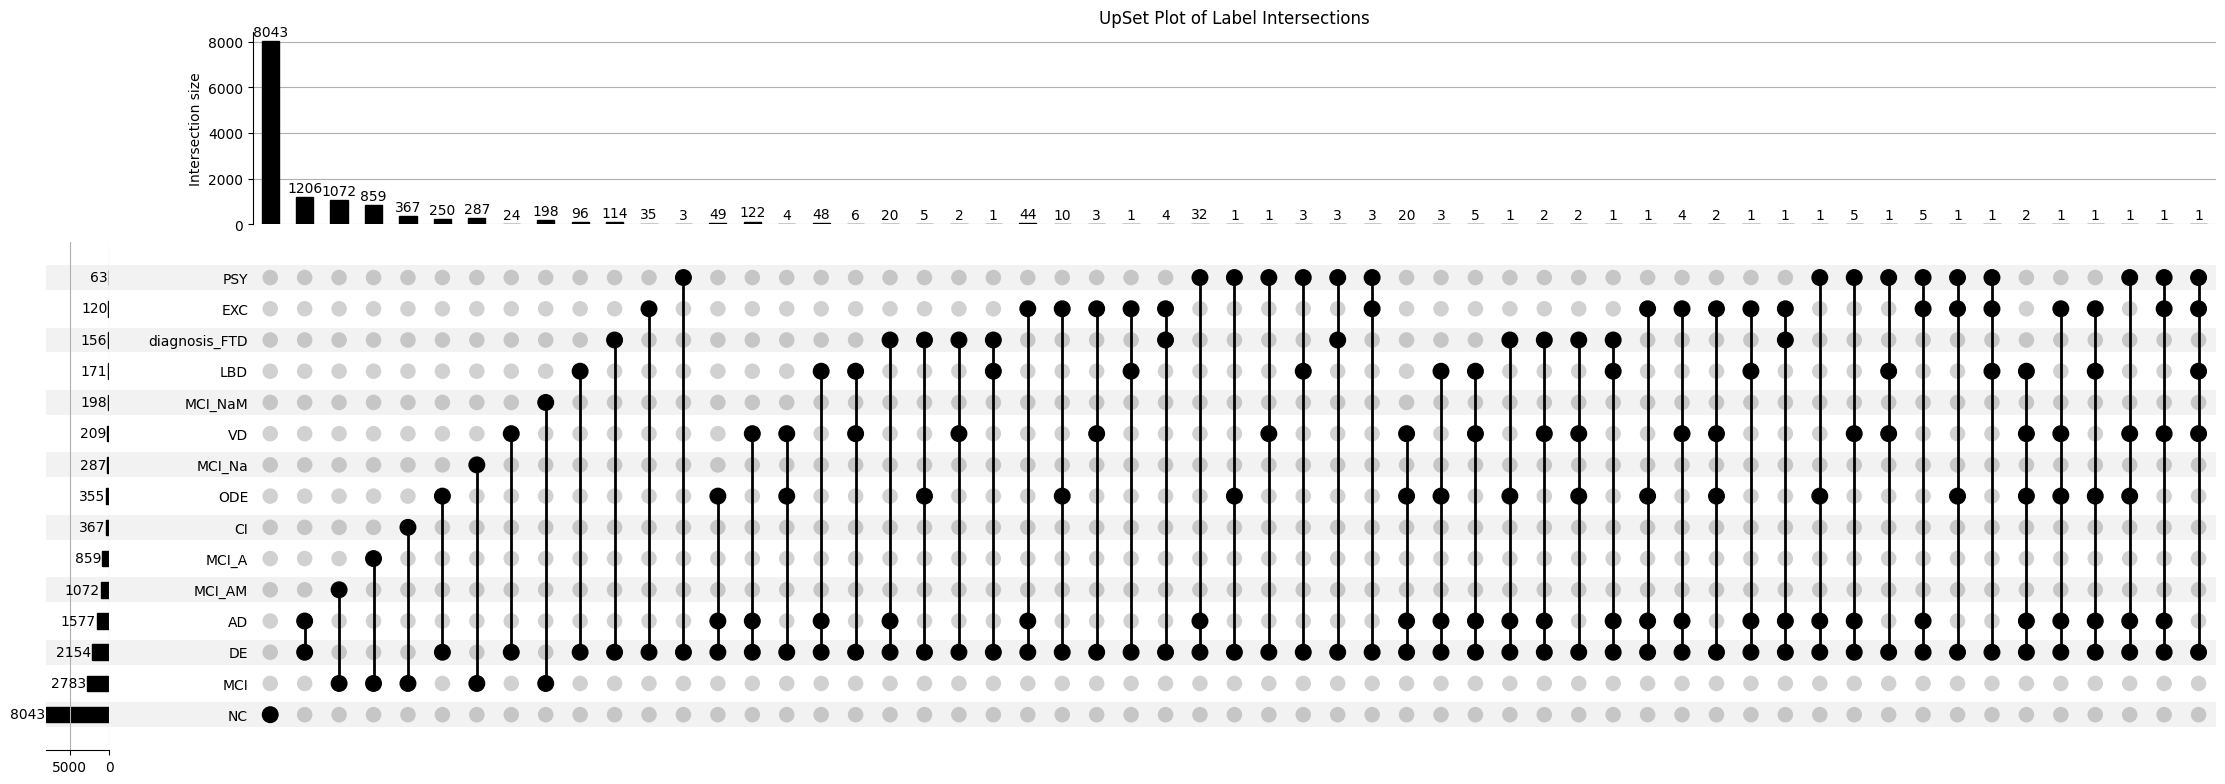

In [ ]:
label_data = data[labels].fillna(0).astype(int)
import matplotlib.pyplot as plt
from upsetplot import UpSet, from_indicators

label_data = data[labels].fillna(0).astype(bool)

indicator_series = from_indicators(labels, label_data)

upset = UpSet(indicator_series, subset_size='count', show_counts='%d')
upset.plot()
plt.title("UpSet Plot of Label Intersections")
plt.savefig(f'./pic/{creative_day}/UpSet Plot of Label Intersections', dpi=1000, bbox_inches='tight')
plt.show()

# multimodal all label

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    hamming_loss,
    jaccard_score,
    matthews_corrcoef,
    classification_report
)

os.makedirs('./pic/', exist_ok=True)

original_stdout = sys.stdout
log_file = open(f'./{creative_day}/all_label_multimodal_log.txt', 'w')
sys.stdout = log_file
class MultiLabelDataset(Dataset):
    def __init__(self, img, text, num, labels_dict,
                 num_mask_p=.15, txt_mask_p=.10, img_cutout=True,
                 training=True):
        self.img = torch.tensor(img, dtype=torch.float32)
        self.text = torch.tensor(text, dtype=torch.float32)
        self.num = torch.tensor(num, dtype=torch.float32)
        
        label_list = [
            labels_dict['NC'], labels_dict['MCI'], labels_dict['DE'],
            labels_dict['AD'], labels_dict['LBD'], labels_dict['VD'],
            labels_dict['diagnosis_FTD'], labels_dict['EXC'], labels_dict['PSY'],
            labels_dict['ODE'], labels_dict['CI'], labels_dict['MCI_A'],
            labels_dict['MCI_AM'], labels_dict['MCI_Na'], labels_dict['MCI_NaM']
        ]
        self.labels = torch.tensor(np.stack(label_list, axis=1), dtype=torch.float32)

        self.num_mask_p = num_mask_p
        self.txt_mask_p = txt_mask_p
        self.img_cutout = img_cutout
        self.training = training

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = self.img[idx].clone()
        text = self.text[idx].clone()
        num = self.num[idx].clone()

        if self.training:
            if self.img_cutout:
                img = torch.as_tensor(random_cutout_3d(img.numpy()),
                                      dtype=torch.float32)
            if self.txt_mask_p > 0:
                keep = torch.rand_like(text) > self.txt_mask_p
                text = text * keep
            if self.num_mask_p > 0:
                keep = torch.rand_like(num) > self.num_mask_p
                num = num * keep

        return {
            "img": img,
            "text": text,
            "num": num,
            "label": self.labels[idx],
        }


class MultiLabelMultiModalFusion(nn.Module):
    def __init__(self, img_shape, text_dim, num_dim, num_labels=15, use_text=True, use_num=True):
        super(MultiLabelMultiModalFusion, self).__init__()
        self.img_model = ImageCNN3D(img_shape, output_dim=256)
        self.text_model = TextMLP(text_dim, output_dim=128)
        self.num_model = NumericMLP(num_dim, output_dim=128)
        
        self.use_text = use_text
        self.use_num = use_num

        self.fusion_fc1 = nn.Linear(512, 64)
        self.fusion_relu1 = nn.ReLU()
        self.fusion_dropout1 = nn.Dropout(0.5)
        self.fusion_bn1 = nn.BatchNorm1d(64)

        self.fusion_fc2 = nn.Linear(64, 32)
        self.fusion_relu2 = nn.ReLU()
        self.fusion_dropout2 = nn.Dropout(0.5)
        self.fusion_bn2 = nn.BatchNorm1d(32)

        self.fusion_fc3 = nn.Linear(32, num_labels)

    def forward(self, img, text=None, num=None):
        img_features = self.img_model(img)
        batch_size = img_features.size(0)
        
        if self.use_text and text is not None:
            text_features = self.text_model(text)
        else:
            text_features = torch.zeros(batch_size, 128, device=img_features.device)
        
        if self.use_num and num is not None:
            num_features = self.num_model(num)
        else:
            num_features = torch.zeros(batch_size, 128, device=img_features.device)
        
        combined = torch.cat((img_features, text_features, num_features), dim=1)

        x = self.fusion_fc1(combined)
        x = self.fusion_relu1(x)
        x = self.fusion_bn1(x)
        x = self.fusion_dropout1(x)

        x = self.fusion_fc2(x)
        x = self.fusion_relu2(x)
        x = self.fusion_bn2(x)
        x = self.fusion_dropout2(x)

        logits = self.fusion_fc3(x)
        output_probs = torch.sigmoid(logits)
        return output_probs


def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for batch in tqdm(loader, desc="训练"):
        imgs = batch['img'].to(device)
        texts = batch['text'].to(device)
        nums = batch['num'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(imgs, texts, nums)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        
        preds = (outputs > 0.5).float()
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)
    
    exact_match = (all_preds == all_labels).all(axis=1).mean()
    
    return running_loss / len(all_labels), exact_match


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(loader, desc="评估"):
            imgs = batch['img'].to(device)
            texts = batch['text'].to(device)
            nums = batch['num'].to(device)
            labels = batch['label'].to(device)

            outputs = model(imgs, texts, nums)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * imgs.size(0)
            
            probs = outputs.cpu().numpy()
            preds = (outputs > 0.5).float().cpu().numpy()

            all_preds.append(preds)
            all_probs.append(probs)
            all_labels.append(labels.cpu().numpy())

    all_preds = np.vstack(all_preds)
    all_probs = np.vstack(all_probs)
    all_labels = np.vstack(all_labels)
    
    exact_match = (all_preds == all_labels).all(axis=1).mean()

    return running_loss / len(all_labels), exact_match, all_preds, all_probs, all_labels

def model_multilabel_crossval(data, X_imgs_reshaped, X_texts, X_nums, device, n_splits=5):
    label_names = ['NC', 'MCI', 'DE', 'AD', 'LBD', 'VD', 'diagnosis_FTD', 'EXC', 
                   'PSY', 'ODE', 'CI', 'MCI_A', 'MCI_AM', 'MCI_Na', 'MCI_NaM']
    
    all_train_losses, all_train_accs = [], []
    all_val_losses, all_val_accs = [], []
    fold_metrics = []

    for fold in range(n_splits):
        print(f"\n=== Fold {fold + 1}/{n_splits} ===")

        idx_train = np.load(f"./index/{creative_day}/idx_train_fold{fold}.npy")
        idx_test = np.load(f"./index/{creative_day}/idx_test_fold{fold}.npy")

        labels_dict = {
            'NC': data["NC"].values.astype(np.float32),
            'MCI': data["MCI"].values.astype(np.float32),
            'DE': data["DE"].values.astype(np.float32),
            'AD': data["AD"].values.astype(np.float32),
            'LBD': data["LBD"].values.astype(np.float32),
            'VD': data["VD"].values.astype(np.float32),
            'diagnosis_FTD': data["diagnosis_FTD"].values.astype(np.float32),
            'EXC': data["EXC"].values.astype(np.float32),
            'PSY': data["PSY"].values.astype(np.float32),
            'ODE': data["ODE"].values.astype(np.float32),
            'CI': data["CI"].values.astype(np.float32),
            'MCI_A': data["MCI_A"].values.astype(np.float32),
            'MCI_AM': data["MCI_AM"].values.astype(np.float32),
            'MCI_Na': data["MCI_Na"].values.astype(np.float32),
            'MCI_NaM': data["MCI_NaM"].values.astype(np.float32)
        }

        labels_train = {k: v[idx_train] for k, v in labels_dict.items()}
        labels_test = {k: v[idx_test] for k, v in labels_dict.items()}

        X_img_train, X_img_test = X_imgs_reshaped[idx_train], X_imgs_reshaped[idx_test]
        X_text_train, X_text_test = rows(X_texts, idx_train), rows(X_texts, idx_test)
        X_num_train, X_num_test = rows(X_nums, idx_train), rows(X_nums, idx_test)

        train_dataset = MultiLabelDataset(
            X_img_train, X_text_train, X_num_train, labels_train,
            num_mask_p=.15, txt_mask_p=.1, img_cutout=True, training=True
        )
        val_dataset = MultiLabelDataset(
            X_img_test, X_text_test, X_num_test, labels_test,
            num_mask_p=0.0, txt_mask_p=0.0, img_cutout=False, training=False
        )

        train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

        img_shape = X_imgs_reshaped.shape[1:]
        text_dim = X_texts.shape[1]
        num_dim = X_nums.shape[1]

        model = MultiLabelMultiModalFusion(
            img_shape, text_dim, num_dim, num_labels=15,
            use_text=True, use_num=True
        ).to(device)

        class WeightedBCELoss(nn.Module):
            def __init__(self, pos_weights):
                super(WeightedBCELoss, self).__init__()
                self.pos_weights = pos_weights
            
            def forward(self, outputs, targets):
                return F.binary_cross_entropy(outputs, targets, weight=self.pos_weights)

        def calculate_pos_weights(labels, device):
            pos_counts = labels.sum(axis=0)
            neg_counts = len(labels) - pos_counts
            pos_weights = neg_counts / (pos_counts + 1e-5)
            return torch.tensor(pos_weights, dtype=torch.float32).to(device)

        pos_weights = calculate_pos_weights(
            np.stack([labels_train[k] for k in label_names], axis=1), 
            device
        )
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)


        optimizer = optim.Adam(model.parameters(), lr=0.0001)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6)

        max_epochs = 300
        patience = 30
        best_f1 = -np.inf
        counter = 0

        train_losses, train_accs, val_losses, val_accs = [], [], [], []

        for epoch in range(max_epochs):
            train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
            val_loss, val_acc, val_preds, val_probs, val_labels = evaluate(
                model, val_loader, criterion, device
            )

            val_f1 = f1_score(val_labels, val_preds, average='macro', zero_division=0)
            scheduler.step(val_loss)

            print(f"Fold {fold + 1} Epoch {epoch + 1} - "
                  f"Train Loss: {train_loss:.4f} Val Loss: {val_loss:.4f} Val F1: {val_f1:.4f}")

            train_losses.append(train_loss)
            train_accs.append(train_acc)
            val_losses.append(val_loss)
            val_accs.append(val_acc)

            if val_f1 > best_f1:
                best_f1 = val_f1
                torch.save(model.state_dict(), 
                          f'./models_joint/{creative_day}/multilabel_fold{fold + 1}.pt')
                counter = 0
            else:
                counter += 1
                if counter >= patience:
                    print(f"Early stopping at epoch {epoch + 1} for fold{fold + 1}")
                    break

        train_losses = pad_list(train_losses, max_epochs)
        train_accs = pad_list(train_accs, max_epochs)
        val_losses = pad_list(val_losses, max_epochs)
        val_accs = pad_list(val_accs, max_epochs)

        all_train_losses.append(train_losses)
        all_train_accs.append(train_accs)
        all_val_losses.append(val_losses)
        all_val_accs.append(val_accs)

        model.load_state_dict(torch.load(
            f'./models_joint/{creative_day}/multilabel_fold{fold + 1}.pt'
        ))
        model.eval()
        final_loss, final_acc, val_preds, val_probs, val_labels = evaluate(
            model, val_loader, criterion, device
        )

        print(f"Fold {fold + 1} Final Eval: Loss: {final_loss:.4f}, "
              f"Exact Match Accuracy: {final_acc:.4f}")

        hamming = hamming_loss(val_labels, val_preds)
        jaccard = jaccard_score(val_labels, val_preds, average='samples')
        prec_macro = precision_score(val_labels, val_preds, average='macro', zero_division=0)
        rec_macro = recall_score(val_labels, val_preds, average='macro', zero_division=0)
        f1_macro = f1_score(val_labels, val_preds, average='macro', zero_division=0)
        
        try:
            auc_macro = roc_auc_score(val_labels, val_probs, average='macro')
        except:
            auc_macro = 0
        
        try:
            aupr_macro = average_precision_score(val_labels, val_probs, average='macro')
        except:
            aupr_macro = 0

        print(f"Fold {fold + 1} Overall Metrics:")
        print(f"  Hamming Loss: {hamming:.4f}")
        print(f"  Jaccard Score: {jaccard:.4f}")
        print(f"  Precision (Macro): {prec_macro:.4f}")
        print(f"  Recall (Macro): {rec_macro:.4f}")
        print(f"  F1 (Macro): {f1_macro:.4f}")
        print(f"  AUC (Macro): {auc_macro:.4f}")
        print(f"  AUPR (Macro): {aupr_macro:.4f}")

        print(f"\nPer-Label Metrics:")
        per_label_metrics = {}
        for i, label_name in enumerate(label_names):
            y_true = val_labels[:, i]
            y_pred = val_preds[:, i]
            y_prob = val_probs[:, i]

            tp = ((y_true == 1) & (y_pred == 1)).sum()
            tn = ((y_true == 0) & (y_pred == 0)).sum()
            fp = ((y_true == 0) & (y_pred == 1)).sum()
            fn = ((y_true == 1) & (y_pred == 0)).sum()

            acc = accuracy_score(y_true, y_pred)
            prec = precision_score(y_true, y_pred, zero_division=0)
            rec = recall_score(y_true, y_pred, zero_division=0)
            f1 = f1_score(y_true, y_pred, zero_division=0)

            spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0

            denom = (tp + fp) * (tp + fn) * (tn + fp) * (tn + fn)
            if denom == 0:
                mcc = 0.0
            else:
                mcc = ((tp * tn) - (fp * fn)) / (denom ** 0.5)

            try:
                auroc = roc_auc_score(y_true, y_prob)
            except Exception:
                auroc = 0.0

            try:
                aupr = average_precision_score(y_true, y_prob)
            except Exception:
                aupr = 0.0

            per_label_metrics[label_name] = {
                "Accuracy": acc,
                "Precision": prec,
                "Recall": rec,
                "Specificity": spec,
                "F1 Score": f1,
                "MCC": mcc,
                "AUROC": auroc,
                "AUPR": aupr
            }

            print(
                f"  {label_name}: "
                f"Accuracy={acc:.4f}, Precision={prec:.4f}, Recall={rec:.4f}, "
                f"Specificity={spec:.4f}, F1 Score={f1:.4f}, MCC={mcc:.4f}, "
                f"AUROC={auroc:.4f}, AUPR={aupr:.4f}"
            )

        subset1_labels = ['NC','MCI', 'DE']
        subset1_idx = [label_names.index(k) for k in subset1_labels]
        y_true_s1 = val_labels[:, subset1_idx]
        y_pred_s1 = val_preds[:, subset1_idx]
        exact_match_s1 = np.all(y_true_s1 == y_pred_s1, axis=1).mean()
        hamming_loss_s1 = hamming_loss(y_true_s1, y_pred_s1)
        hamming_acc_s1 = 1.0 - hamming_loss_s1
        f1_macro_s1 = f1_score(y_true_s1, y_pred_s1, average='macro', zero_division=0)

        subset2_labels = ['CI', 'MCI_A', 'MCI_AM', 'MCI_Na', 'MCI_NaM']
        subset2_idx = [label_names.index(k) for k in subset2_labels]
        y_true_s2 = val_labels[:, subset2_idx]
        y_pred_s2 = val_preds[:, subset2_idx]
        exact_match_s2 = np.all(y_true_s2 == y_pred_s2, axis=1).mean()
        hamming_loss_s2 = hamming_loss(y_true_s2, y_pred_s2)
        hamming_acc_s2 = 1.0 - hamming_loss_s2
        f1_macro_s2 = f1_score(y_true_s2, y_pred_s2, average='macro', zero_division=0)

        subset3_labels = ['AD', 'LBD', 'VD', 'diagnosis_FTD', 'EXC', 'PSY', 'ODE']
        subset3_idx = [label_names.index(k) for k in subset3_labels]
        y_true_s3 = val_labels[:, subset3_idx]
        y_pred_s3 = val_preds[:, subset3_idx]
        exact_match_s3 = np.all(y_true_s3 == y_pred_s3, axis=1).mean()
        hamming_loss_s3 = hamming_loss(y_true_s3, y_pred_s3)
        hamming_acc_s3 = 1.0 - hamming_loss_s3
        f1_macro_s3 = f1_score(y_true_s3, y_pred_s3, average='macro', zero_division=0)

        fold_metrics.append({
            "fold": fold + 1,
            "exact_match": final_acc,
            "hamming_loss": hamming,
            "jaccard_score": jaccard,
            "precision_macro": prec_macro,
            "recall_macro": rec_macro,
            "f1_macro": f1_macro,
            "auc_macro": auc_macro,
            "aupr_macro": aupr_macro,
            "per_label": per_label_metrics,

            "subset1_labels": subset1_labels,
            "subset1_overall_accuracy": exact_match_s1,
            "subset1_hamming_accuracy": hamming_acc_s1,
            "subset1_f1_macro": f1_macro_s1,

            "subset2_labels": subset2_labels,
            "subset2_overall_accuracy": exact_match_s2,
            "subset2_hamming_accuracy": hamming_acc_s2,
            "subset2_f1_macro": f1_macro_s2,

            "subset3_labels": subset1_labels,
            "subset3_overall_accuracy": exact_match_s3,
            "subset3_hamming_accuracy": hamming_acc_s3,
            "subset3_f1_macro": f1_macro_s3,
        })


    avg_train_loss = np.mean(all_train_losses, axis=0)
    avg_val_loss = np.mean(all_val_losses, axis=0)
    avg_train_acc = np.mean(all_train_accs, axis=0)
    avg_val_acc = np.mean(all_val_accs, axis=0)

    epochs = range(1, len(avg_train_loss) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, avg_train_acc, label='Train Accuracy')
    plt.plot(epochs, avg_val_acc, label='Validation Accuracy')
    plt.title('Model Accuracy (Exact Match)')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, avg_train_loss, label='Train Loss')
    plt.plot(epochs, avg_val_loss, label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig(f'./pic/{creative_day}/multilabel_training_curve.pdf', dpi=150)
    plt.close()

    print("\n=== 5-Fold Cross-Validation Summary ===")
    
    avg_metrics = {}
    for key in ['exact_match', 'hamming_loss', 'jaccard_score', 
                'precision_macro', 'recall_macro', 'f1_macro', 
                'auc_macro', 'aupr_macro',
                'subset1_overall_accuracy','subset1_hamming_accuracy', 'subset1_f1_macro',
                'subset2_overall_accuracy','subset2_hamming_accuracy', 'subset2_f1_macro',
                'subset3_overall_accuracy','subset3_hamming_accuracy', 'subset3_f1_macro']:
        values = [fm[key] for fm in fold_metrics]
        avg_metrics[key] = {
            'mean': np.mean(values),
            'std': np.std(values)
        }
        print(f"{key}: {avg_metrics[key]['mean']:.4f} ± {avg_metrics[key]['std']:.4f}")

    print("\n=== Per-Label Average Metrics ===")
    per_label_summary = {}
    for label_name in label_names:
        per_label_summary[label_name] = {}
        for metric_name in ['Accuracy', 'Precision', 'Recall', 'Specificity', 
                            'F1 Score', 'MCC', 'AUROC', 'AUPR']:
            values = [fm['per_label'][label_name][metric_name] for fm in fold_metrics]
            per_label_summary[label_name][metric_name] = {
                'mean': np.mean(values),
                'std': np.std(values)
            }
        
        print(f"\n{label_name}:")
        for metric_name, stats in per_label_summary[label_name].items():
            print(f"  {metric_name}: {stats['mean']:.4f} ± {stats['std']:.4f}")

    results_df = pd.DataFrame([
        {k: v for k, v in fm.items() if k != 'per_label'}
        for fm in fold_metrics
    ])
    results_df.to_csv(f'./results/{creative_day}/multilabel_cv_results.csv', index=False)
    
    return fold_metrics, per_label_summary


if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    
    if X_imgs.ndim == 4:
        if X_imgs.shape[-1] in [1, 3]:
            X_imgs = np.transpose(X_imgs, (0, 3, 1, 2))
        X_imgs = np.expand_dims(X_imgs, axis=2)
    X_imgs_reshaped = np.transpose(X_imgs, (0, 4, 1, 2, 3))
    
    fold_metrics, per_label_summary = model_multilabel_crossval(
        data, X_imgs_reshaped, X_texts, X_nums, device, n_splits=5
    )
    
    sys.stdout = original_stdout
    log_file.close()
    print("训练日志已保存到 training_log.txt，图片保存到 ./pic/ 文件夹")


评估: 100%|██████████| 21/21 [00:01<00:00, 17.77it/s]


# Secondary label
focal fail
pos_weight success

In [ ]:

class MultiLabelDataset(Dataset):
    def __init__(self, img, text, num, labels_dict,
                 num_mask_p=.15, txt_mask_p=.10, img_cutout=True,
                 training=True):
        self.img = torch.tensor(img, dtype=torch.float32)
        self.text = torch.tensor(text, dtype=torch.float32)
        self.num = torch.tensor(num, dtype=torch.float32)
        if labels_dict is not None:
            label_list = [
                labels_dict['NC'], labels_dict['MCI'], labels_dict['DE'],
                labels_dict['AD'], labels_dict['LBD'], labels_dict['VD'],
                labels_dict['diagnosis_FTD'], labels_dict['EXC'], labels_dict['PSY'],
                labels_dict['ODE'], labels_dict['CI'], labels_dict['MCI_A'],
                labels_dict['MCI_AM'], labels_dict['MCI_Na'], labels_dict['MCI_NaM']
            ]
            self.labels = torch.tensor(np.stack(label_list, axis=1), dtype=torch.float32)
        else:
            self.labels = torch.zeros((len(img), 15), dtype=torch.float32)
        self.num_mask_p = num_mask_p
        self.txt_mask_p = txt_mask_p
        self.img_cutout = img_cutout
        self.training = training

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = self.img[idx].clone()
        text = self.text[idx].clone()
        num = self.num[idx].clone()

        if self.training:
            if self.img_cutout:
                img = torch.as_tensor(random_cutout_3d(img.numpy()),
                                      dtype=torch.float32)
            if self.txt_mask_p > 0:
                keep = torch.rand_like(text) > self.txt_mask_p
                text = text * keep
            if self.num_mask_p > 0:
                keep = torch.rand_like(num) > self.num_mask_p
                num = num * keep

        return {
            "img": img,
            "text": text,
            "num": num,
            "label": self.labels[idx],
        }


class MultiLabelMultiModalFusion(nn.Module):
    def __init__(self, img_shape, text_dim, num_dim, num_labels=15, use_text=True, use_num=True):
        super(MultiLabelMultiModalFusion, self).__init__()
        self.img_model = ImageCNN3D(img_shape, output_dim=256)
        self.text_model = TextMLP(text_dim, output_dim=128)
        self.num_model = NumericMLP(num_dim, output_dim=128)
        
        self.use_text = use_text
        self.use_num = use_num

        self.fusion_fc1 = nn.Linear(512, 64)
        self.fusion_relu1 = nn.ReLU()
        self.fusion_dropout1 = nn.Dropout(0.5)
        self.fusion_bn1 = nn.BatchNorm1d(64)

        self.fusion_fc2 = nn.Linear(64, 32)
        self.fusion_relu2 = nn.ReLU()
        self.fusion_dropout2 = nn.Dropout(0.5)
        self.fusion_bn2 = nn.BatchNorm1d(32)

        self.fusion_fc3 = nn.Linear(32, num_labels)

    def forward(self, img, text=None, num=None):
        img_features = self.img_model(img)
        batch_size = img_features.size(0)
        
        if self.use_text and text is not None:
            text_features = self.text_model(text)
        else:
            text_features = torch.zeros(batch_size, 128, device=img_features.device)
        
        if self.use_num and num is not None:
            num_features = self.num_model(num)
        else:
            num_features = torch.zeros(batch_size, 128, device=img_features.device)
        
        combined = torch.cat((img_features, text_features, num_features), dim=1)

        x = self.fusion_fc1(combined)
        x = self.fusion_relu1(x)
        x = self.fusion_bn1(x)
        x = self.fusion_dropout1(x)

        x = self.fusion_fc2(x)
        x = self.fusion_relu2(x)
        x = self.fusion_bn2(x)
        x = self.fusion_dropout2(x)

        logits = self.fusion_fc3(x)
        output_probs = torch.sigmoid(logits)
        return output_probs

class InferenceDataset(Dataset):
    def __init__(self, X_img, X_txt, X_num):
        self.X_img = torch.FloatTensor(X_img)
        self.X_txt = torch.FloatTensor(X_txt)
        self.X_num = torch.FloatTensor(X_num)
    def __getitem__(self, idx):
        return self.X_img[idx], self.X_txt[idx], self.X_num[idx]
    def __len__(self):
        return len(self.X_img)

def preprocess_image(img_np):
    img_min = img_np.min()
    img_max = img_np.max()
    if img_max != img_min:
        norm_img = (img_np - img_min) / (img_max - img_min)
    else:
        norm_img = img_np
    return norm_img.astype(np.float32)

def load_nifti_data_inference(file_paths_t1, file_paths_t2, scale_factor=0.5):
    target_shape = (45, 54, 45)
    X_imgs = np.zeros((len(file_paths_t1),) + target_shape + (2,), dtype=np.float32)
    
    print(f"    正在加载 {len(file_paths_t1)} 个样本的图像...")
    for i, (p1, p2) in enumerate(zip(file_paths_t1, file_paths_t2)):
        if os.path.exists(str(p1)):
            d1 = nib.load(p1).get_fdata()
            d1 = preprocess_image(d1)
            scale = tuple(t/o for t,o in zip(target_shape, d1.shape))
            d1 = zoom(d1, scale, order=1)
        else:
            d1 = np.zeros(target_shape, dtype=np.float32)
        if os.path.exists(str(p2)):
            d2 = nib.load(p2).get_fdata()
            d2 = preprocess_image(d2)
            scale = tuple(t/o for t,o in zip(target_shape, d2.shape))
            d2 = zoom(d2, scale, order=1)
        else:
            d2 = np.zeros(target_shape, dtype=np.float32)
            
        X_imgs[i, ..., 0] = d1
        X_imgs[i, ..., 1] = d2
        
    X_imgs = np.transpose(X_imgs, (0, 4, 1, 2, 3))
    return X_imgs


class DownstreamDataset(Dataset):
    def __init__(self, img, text, num, labels, prior, device, num_mask_p=.15, txt_mask_p=.10, img_cutout=True, training=True):
        self.img = torch.as_tensor(img, dtype=torch.float32).to(device)
        self.text = torch.as_tensor(text, dtype=torch.float32).to(device)
        self.num = torch.as_tensor(num, dtype=torch.float32).to(device)
        self.prior = torch.as_tensor(prior, dtype=torch.float32).to(device)
        
        if labels is not None:
            self.labels = torch.tensor(labels, dtype=torch.float32)
        else:
            self.labels = torch.zeros((len(img), 1), dtype=torch.float32)

        self.num_mask_p = num_mask_p
        self.txt_mask_p = txt_mask_p
        self.img_cutout = img_cutout
        self.training = training

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        img = self.img[idx]
        text = self.text[idx]
        num = self.num[idx]
        prior = self.prior[idx]
        
        if self.training:
            img = img.clone()
            text = text.clone()
            num = num.clone()
            
            if self.img_cutout: 
                img = torch_random_cutout_3d(img)
            
            if self.txt_mask_p > 0: 
                text = text * (torch.rand_like(text) > self.txt_mask_p)
            
            if self.num_mask_p > 0: 
                num = num * (torch.rand_like(num) > self.num_mask_p)
            
        return {"img": img, "text": text, "num": num, "label": self.labels[idx], "prior": prior}


class PriorMultiLabelMultiModalFusion(nn.Module):
    def __init__(self, 
                 img_shape, 
                 text_dim, 
                 num_dim, 
                 num_labels=15,
                 prior_dim=15,
                 img_feat=256,
                 txt_feat=128,
                 num_feat=128,
                 fusion_dim=256,
                 hidden_dim=64,
                 dropout=0.5,
                 use_text=True,
                 use_num=True):
        super(PriorMultiLabelMultiModalFusion, self).__init__()
        
        self.use_text = use_text
        self.use_num = use_num
        self.img_feat = img_feat
        self.txt_feat = txt_feat
        self.num_feat = num_feat

        self.img_model = ImageCNN3D(img_shape, output_dim=img_feat)
        self.text_model = TextMLP(text_dim, output_dim=txt_feat)
        self.num_model = NumericMLP(num_dim, output_dim=num_feat)

        total_in_dim = img_feat + txt_feat + num_feat
        self.fusion1 = MLPBlock(total_in_dim, fusion_dim, p=dropout)

        self.prior_proj = nn.Sequential(
            nn.Linear(prior_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU()
        )
        self.film_gamma = nn.Linear(hidden_dim, fusion_dim)
        self.film_beta  = nn.Linear(hidden_dim, fusion_dim)

        self.se = SEBlock(fusion_dim)

        self.fusion2 = MLPBlock(fusion_dim, hidden_dim, p=dropout)

        self.fusion3 = MLPBlock(hidden_dim + prior_dim, hidden_dim, p=dropout)

        self.out = nn.Linear(hidden_dim, num_labels)

    def forward(self, img, text, num, prior_knowledge):
        if img is not None:
            batch_size = img.size(0)
            device = img.device
        else:
            batch_size = num.size(0)
            device = num.device

        prior_knowledge = prior_knowledge.view(batch_size, -1).float().to(device)

        if img is not None:
            f_img = self.img_model(img)
        else:
            f_img = torch.zeros((batch_size, self.img_feat), device=device)

        if self.use_text and text is not None:
            f_txt = self.text_model(text)
        else:
            f_txt = torch.zeros((batch_size, self.txt_feat), device=device)

        if self.use_num and num is not None:
            f_num = self.num_model(num)
        else:
            f_num = torch.zeros((batch_size, self.num_feat), device=device)

        x = torch.cat([f_img, f_txt, f_num], dim=1)
        x = self.fusion1(x)

        h_prior = self.prior_proj(prior_knowledge)
        gamma = self.film_gamma(h_prior)
        beta  = self.film_beta(h_prior)
        
        x = x + (gamma * x + beta)

        x = self.se(x)

        x = self.fusion2(x)

        x = torch.cat([x, prior_knowledge], dim=1)
        x = self.fusion3(x)

        logits = self.out(x)
        
        return logits

class ClinicalInferenceEngine:
    def __init__(self, model_dir, feature_dir, device=None, fold=1):
        self.model_dir = model_dir
        self.feature_dir = feature_dir
        self.device = device if device else torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.fold = fold
        
        self.label_names = [
            'NC', 'MCI', 'DE',
            'AD', 'LBD', 'VD', 'diagnosis_FTD', 'EXC', 'PSY', 'ODE',
            'CI', 'MCI_A', 'MCI_AM', 'MCI_Na', 'MCI_NaM'
        ]
        self.s_global = slice(0, 3)
        self.s_etio = slice(3, 10)
        self.s_sub = slice(10, 15)

    def _align_features(self, df):
        col_nums_path = os.path.join(self.feature_dir, "X_nums_columns.csv")
        if os.path.exists(col_nums_path):
            cols_nums = pd.read_csv(col_nums_path)["column"].tolist()
            X_nums = df.reindex(columns=cols_nums).fillna(0.0)
            for col in X_nums.columns:
                X_nums[col] = pd.to_numeric(X_nums[col], errors='coerce').fillna(0.0)
            X_nums = X_nums.values.astype(np.float32)
        else:
            print("⚠️ 警告: 未找到 X_nums_columns.csv，数值特征置0")
            X_nums = np.zeros((len(df), 1), dtype=np.float32)

        col_texts_path = os.path.join(self.feature_dir, "X_texts_columns.csv")
        if os.path.exists(col_texts_path):
            cols_texts = pd.read_csv(col_texts_path)["column"].tolist()
            X_texts = df.reindex(columns=cols_texts).fillna(0.0)
            X_texts = X_texts.apply(pd.to_numeric, errors='coerce').fillna(0.0)
            X_texts = X_texts.values.astype(np.float32)
        else:
            print("ℹ️ 未找到 X_texts_columns.csv，文本特征置0")
            X_texts = np.zeros((len(df), 1), dtype=np.float32)
            
        return X_nums, X_texts

    def run(self, new_csv_path, output_path, batch_size=512):
        print(f"\n🚀 开始推理: {new_csv_path}")
        
        df = pd.read_csv(new_csv_path)
        df['t1_path'] = df['t1_path'].astype(str)
        df['t2_path'] = df['t2_path'].astype(str)
        
        print(">>> [Step 1/4] Loading Data...")
        X_imgs = load_nifti_data_inference(df['t1_path'].tolist(), df['t2_path'].tolist())
        X_nums, X_texts = self._align_features(df)
        
        print(f"    Data Shapes -> Img:{X_imgs.shape}, Txt:{X_texts.shape}, Num:{X_nums.shape}")
        
        ds = InferenceDataset(X_imgs, X_texts, X_nums)
        loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
        
        print(">>> [Step 2/4] Running Global Model...")
        global_path = os.path.join(self.model_dir, f'multilabel_fold{self.fold}.pt')
        if not os.path.exists(global_path):
            raise FileNotFoundError(f"Global model not found: {global_path}")
            
        model_global = MultiLabelMultiModalFusion(
            X_imgs.shape[1:],       
            X_texts.shape[1],       
            X_nums.shape[1],        
            num_labels=15           
        ).to(self.device)
        
        model_global.load_state_dict(torch.load(global_path, map_location=self.device))
        model_global.eval()
        
        global_probs_list = []
        with torch.no_grad():
            for img, txt, num in loader:
                img, txt, num = img.to(self.device), txt.to(self.device), num.to(self.device)
                logits = model_global(img, txt, num)
                probs = torch.sigmoid(logits) if (logits.min() < 0 or logits.max() > 1) else logits
                global_probs_list.append(probs.cpu().numpy())
        
        global_probs_all = np.concatenate(global_probs_list, axis=0)

        rag_cols = ['NC_rag', 'MCI_rag', 'DE_rag']
        if all(col in df.columns for col in rag_cols):
            print(">>> [Step 2.5] 🟢 执行按需融合 (仅纠正分歧样本的 NC/MCI/DE，下游先验保持原样)...")
            override_count = 0
            
            ALPHA = 0.65 
            
            for r in range(len(df)):
                rag_nc = df.iloc[r].get('NC_rag', 0)
                rag_mci = df.iloc[r].get('MCI_rag', 0)
                rag_de = df.iloc[r].get('DE_rag', 0)

                if rag_nc == 1 or rag_mci == 1 or rag_de == 1:
                    rag_idx = 0 if rag_nc == 1 else (1 if rag_mci == 1 else 2)
                    
                    p_global = global_probs_all[r, self.s_global]
                    pred_idx = int(np.argmax(p_global))
                    
                    if rag_idx != pred_idx:
                        
                        rag_one_hot = np.zeros(3)
                        rag_one_hot[rag_idx] = 1.0
                        global_probs_all[r, self.s_global] = ALPHA * rag_one_hot + (1.0 - ALPHA) * p_global
                        
                        
                        override_count += 1

            print(f"    🧠 RAG 按需纠错完毕，共修改了 {override_count}/{len(df)} 个样本的前3维概率 (下游未变动)！")

        
        all_probs = np.zeros((len(df), 15))
        all_preds = np.zeros((len(df), 15))
        all_probs[:, self.s_global] = global_probs_all[:, self.s_global]
        
        print(">>> [Step 3/4] Running Downstream Models...")
        prior_input = torch.FloatTensor(global_probs_all).to(self.device)
        
        for i in range(3, 15):
            target_name = self.label_names[i]
            down_path = os.path.join(self.model_dir, f'{target_name}_fold{self.fold}.pt')
            
            if not os.path.exists(down_path):
                print(f"    ⚠️ Model missing for {target_name}, skipping...")
                continue
            
            model_down = PriorMultiLabelMultiModalFusion(
                X_imgs.shape[1:],       
                X_texts.shape[1],       
                X_nums.shape[1],        
                prior_dim=15,           
                num_labels=1            
            ).to(self.device)
            
            model_down.load_state_dict(torch.load(down_path, map_location=self.device))
            model_down.eval()
            
            task_probs_list = []
            with torch.no_grad():
                for idx in range(0, len(df), batch_size):
                    end_idx = min(idx + batch_size, len(df))
                    b_img = torch.FloatTensor(X_imgs[idx:end_idx]).to(self.device)
                    b_txt = torch.FloatTensor(X_texts[idx:end_idx]).to(self.device)
                    b_num = torch.FloatTensor(X_nums[idx:end_idx]).to(self.device)
                    b_prior = prior_input[idx:end_idx]
                    
                    logits = model_down(b_img, b_txt, b_num, b_prior)
                    probs = torch.sigmoid(logits)
                    task_probs_list.append(probs.cpu().numpy())
            
            all_probs[:, i] = np.concatenate(task_probs_list, axis=0).flatten()

        print(">>> [Step 4/4] Applying Clinical Logic Masks...")
        for r in range(len(df)):
            global_idx = np.argmax(all_probs[r, self.s_global])
            all_preds[r, self.s_global] = 0
            all_preds[r, global_idx] = 1
            
            if global_idx == 0:
                all_preds[r, self.s_etio] = 0
                all_preds[r, self.s_sub] = 0
            elif global_idx == 1:
                all_preds[r, self.s_etio] = 0
                sub_probs = all_probs[r, self.s_sub]
                if np.max(sub_probs) > 0.1:
                    sub_idx = np.argmax(sub_probs)
                    all_preds[r, 10 + sub_idx] = 1
                else:
                    all_preds[r, self.s_sub] = 0
            elif global_idx == 2:
                all_preds[r, self.s_sub] = 0
                all_preds[r, self.s_etio] = (all_probs[r, self.s_etio] >= 0.5).astype(int)

        print(">>> [Step 5/5] Saving Results (Filtering columns)...")

        cols_to_keep = []
        base_candidates = ['ID', 'IDage', 'PTID', 'RID', 'Subject', 't1_path', 't2_path']
        for c in base_candidates:
            if c in df.columns:
                cols_to_keep.append(c)

        col_nums_path = os.path.join(self.feature_dir, "X_nums_columns.csv")
        if os.path.exists(col_nums_path):
            cols_nums = pd.read_csv(col_nums_path)["column"].tolist()
            cols_to_keep.extend([c for c in cols_nums if c in df.columns])

        col_texts_path = os.path.join(self.feature_dir, "X_texts_columns.csv")
        if os.path.exists(col_texts_path):
            cols_texts = pd.read_csv(col_texts_path)["column"].tolist()
            cols_to_keep.extend([c for c in cols_texts if c in df.columns])

        gt_labels = self.label_names
        for label in gt_labels:
            if label in df.columns:
                cols_to_keep.append(label)

        cols_to_keep = list(dict.fromkeys(cols_to_keep))
        output_df = df[cols_to_keep].copy()

        for label in gt_labels:
            if label not in output_df.columns:
                output_df[label] = np.nan

        for i, name in enumerate(self.label_names):
            output_df[f'{name}_prob'] = all_probs[:, i]
            output_df[f'{name}_label'] = all_preds[:, i].astype(int)
            
        output_df.to_csv(output_path, index=False)
        print(f"✅ Inference Complete! Saved to: {output_path}")
        print(f"   Retained {len(cols_to_keep)} original columns.")
        print(f"   Ensured {len(gt_labels)} GT columns exist.")
        print(f"   Added 30 generated columns (prob + label).")
        
        return output_df

def predict(model, loader, device):
    model.eval()
    all_probs = []
    with torch.no_grad():
        for batch in loader:
            imgs = batch['img'].to(device)
            texts = batch['text'].to(device)
            nums = batch['num'].to(device)
            
            logits = model(imgs, texts, nums)
            probs = torch.sigmoid(logits)
            all_probs.append(probs.cpu().numpy())
            
    return np.vstack(all_probs)

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for batch in tqdm(loader, desc="训练", leave=False):
        imgs = batch['img'].to(device)
        texts = batch['text'].to(device)
        nums = batch['num'].to(device)
        labels = batch['label'].to(device)
        priors = batch['prior'].to(device)

        optimizer.zero_grad()
        logits = model(imgs, texts, nums,priors)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)
    exact_match = (all_preds == all_labels).all(axis=1).mean()
    
    return running_loss / len(all_labels), exact_match

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(loader, desc="评估", leave=False):
            imgs = batch['img'].to(device)
            texts = batch['text'].to(device)
            nums = batch['num'].to(device)
            labels = batch['label'].to(device)
            priors = batch['prior'].to(device)

            logits = model(imgs, texts, nums, priors)
            loss = criterion(logits, labels)

            running_loss += loss.item() * imgs.size(0)
            
            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()

            all_preds.append(preds.cpu().numpy())
            all_probs.append(probs.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_preds = np.vstack(all_preds)
    all_probs = np.vstack(all_probs)
    all_labels = np.vstack(all_labels)
    
    exact_match = (all_preds == all_labels).all(axis=1).mean()

    return running_loss / len(all_labels), exact_match, all_preds, all_probs, all_labels


# prior DE etiologies

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, average_precision_score, confusion_matrix, cohen_kappa_score
)

def run_downstream_tasks(data, X_imgs, X_texts, X_nums, device, n_splits=5):
    
    all_label_names = ['NC', 'MCI', 'DE', 'AD', 'LBD', 'VD', 'diagnosis_FTD', 'EXC', 
                       'PSY', 'ODE', 'CI', 'MCI_A', 'MCI_AM', 'MCI_Na', 'MCI_NaM']
    
    target_tasks = ['AD', 'LBD', 'VD', 'diagnosis_FTD', 'EXC', 'PSY', 'ODE']

    task_metrics_storage = {t: [] for t in target_tasks}
    task_curve_storage = {t: {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []} for t in target_tasks}
    
    global_metrics_storage = [] 
    print(f"🔥 Training Device: {device}")
    print(f"🔥 CUDA Available: {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"🔥 Current Device Name: {torch.cuda.get_device_name(0)}")
        print(f"🔥 Initial Memory: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

    for fold in range(n_splits):
        print(f"\n{'#'*30} Fold {fold + 1}/{n_splits} {'#'*30}")
        
        idx_train = np.load(f"./index/{creative_day}/idx_train_fold{fold}.npy")
        idx_test = np.load(f"./index/{creative_day}/idx_test_fold{fold}.npy")
        
        X_img_train, X_img_test = X_imgs[idx_train], X_imgs[idx_test]
        X_txt_train, X_txt_test = rows(X_texts, idx_train), rows(X_texts, idx_test)
        X_num_train, X_num_test = rows(X_nums, idx_train), rows(X_nums, idx_test)
        
        labels_dict = {k: data[k].values.astype(np.float32) for k in all_label_names}
        labels_train = {k: v[idx_train] for k, v in labels_dict.items()}
        labels_test = {k: v[idx_test] for k, v in labels_dict.items()}

        print(">>> Phase 1: Generating Priors...")
        ds_global_train = MultiLabelDataset(X_img_train, X_txt_train, X_num_train, labels_train, num_mask_p=0, txt_mask_p=0, img_cutout=False, training=False)
        ds_global_test = MultiLabelDataset(X_img_test, X_txt_test, X_num_test, labels_test, num_mask_p=0, txt_mask_p=0, img_cutout=False, training=False)
        loader_global_train = DataLoader(ds_global_train, batch_size=128, shuffle=False)
        loader_global_test = DataLoader(ds_global_test, batch_size=128, shuffle=False)

        global_model_path = f'./models_joint/{creative_day}/multilabel_fold{fold + 1}.pt'
        global_model = MultiLabelMultiModalFusion(X_imgs.shape[1:], X_texts.shape[1], X_nums.shape[1], num_labels=15).to(device)
        
        if os.path.exists(global_model_path):
            global_model.load_state_dict(torch.load(global_model_path))
        else:
            print(f"❌ Global model not found: {global_model_path}")
            continue

        prior_train = predict(global_model, loader_global_train, device)
        prior_test = predict(global_model, loader_global_test, device)

        fold_preds_dict = {}
        fold_probs_dict = {}
        fold_labels_dict = {}
            
        log_path = f'./{creative_day}/prior_de_etiologies_fold{fold+1}.txt'
        original_stdout = sys.stdout
        log_file = open(log_path, 'w')
        sys.stdout = log_file
        
        try:  
            for target_name in target_tasks:
                print(f"\n{'='*20} Training Downstream: {target_name} {'='*20}")
                print(f"Training log for {target_name}, Fold {fold+1}")
                y_train = labels_train[target_name]
                y_test = labels_test[target_name]

                ds_down_train = DownstreamDataset(X_img_train, X_txt_train, X_num_train, y_train, prior_train,device=device, training=True)
                ds_down_test = DownstreamDataset(X_img_test, X_txt_test, X_num_test, y_test, prior_test, device=device,training=False)
                
                dl_down_train = DataLoader(ds_down_train, batch_size=512, shuffle=True, num_workers=0, pin_memory=False)
                dl_down_test = DataLoader(ds_down_test, batch_size=512, shuffle=False, num_workers=0, pin_memory=False)

                model = PriorMultiLabelMultiModalFusion(X_imgs.shape[1:], X_texts.shape[1], X_nums.shape[1], prior_dim=15, num_labels=1).to(device)

                pos_weight = (len(y_train) - y_train.sum()) / (y_train.sum() + 1e-5)
                criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight).to(device))
                optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-3)
                scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

                max_epochs = 300
                patience = 30
                best_f1 = -np.inf 
                counter = 0
                train_losses, train_accs, val_losses, val_accs = [], [], [], []

                for epoch in range(max_epochs):
                    train_loss, train_acc = train_epoch(model, dl_down_train, criterion, optimizer, device)
                    val_loss, val_acc, val_preds, val_probs, val_labels = evaluate(model, dl_down_test, criterion, device)
                    val_f1 = f1_score(val_labels, val_preds, average='macro', zero_division=0)
                    scheduler.step(val_loss)

                    print(f"Fold {fold + 1} Epoch {epoch + 1} - "
                        f"Train Loss: {train_loss:.4f} Val Loss: {val_loss:.4f} Val F1: {val_f1:.4f}")

                    train_losses.append(train_loss)
                    train_accs.append(train_acc)
                    val_losses.append(val_loss)
                    val_accs.append(val_acc)

                    if val_f1 > best_f1:
                        best_f1 = val_f1
                        torch.save(model.state_dict(), 
                                f'./models_joint/{creative_day}/{target_name}_fold{fold + 1}.pt')
                        counter = 0
                    else:
                        counter += 1
                        if counter >= patience:
                            print(f"Early stopping at epoch {epoch + 1} for fold{fold + 1}")
                            break
                
                task_curve_storage[target_name]['train_loss'].append(pad_list(train_losses, max_epochs))
                task_curve_storage[target_name]['val_loss'].append(pad_list(val_losses, max_epochs))
                task_curve_storage[target_name]['train_acc'].append(pad_list(train_accs, max_epochs))
                task_curve_storage[target_name]['val_acc'].append(pad_list(val_accs, max_epochs))

                model.load_state_dict(torch.load(f'./models_joint/{creative_day}/{target_name}_fold{fold+1}.pt'))
                model.eval()

                final_loss, _, _, val_probs, val_labels = evaluate(model, dl_down_test, criterion, device)

                y_true = val_labels.flatten()
                y_prob = val_probs.flatten()

                best_thr, best_f1_val = find_optimal_threshold(y_true, y_prob)
                print(f"  > Optimal Threshold found: {best_thr:.4f} (Max F1: {best_f1_val:.4f})")

                y_pred = (y_prob >= best_thr).astype(int)

                fold_preds_dict[target_name] = y_pred
                fold_probs_dict[target_name] = y_prob
                fold_labels_dict[target_name] = y_true

                tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
                acc = accuracy_score(y_true, y_pred)
                prec = precision_score(y_true, y_pred, zero_division=0)
                rec = recall_score(y_true, y_pred, zero_division=0)
                f1 = f1_score(y_true, y_pred,average='macro', zero_division=0)
                kappa = cohen_kappa_score(y_true, y_pred)
                spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
                denom = (tp + fp) * (tp + fn) * (tn + fp) * (tn + fn)
                mcc = ((tp * tn) - (fp * fn)) / (denom ** 0.5) if denom != 0 else 0.0
                try: auroc = roc_auc_score(y_true, y_prob)
                except: auroc = 0.0
                try: aupr = average_precision_score(y_true, y_prob)
                except: aupr = 0.0

                print(f"\nMetrics for {target_name} (Fold {fold+1}):")
                print(f"  Accuracy: {acc:.4f}, F1: {f1:.4f}, AUC: {auroc:.4f}")

                task_metrics_storage[target_name].append({
                    "Fold": fold + 1,
                    "Accuracy": acc, "Kappa": kappa, "Precision": prec, "Recall": rec,
                    "Specificity": spec, "F1 Score": f1, "MCC": mcc, "AUROC": auroc, "AUPR": aupr
                })
                print(f"Finished {target_name} Fold {fold+1}")
            
        finally:
            sys.stdout = original_stdout
            log_file.close()
            print(f"Finished {target_name} Fold {fold+1}")

        print(f"\n>>> Calculating OVERALL Metrics for Fold {fold+1}...")
        
        y_pred_all = np.stack([fold_preds_dict[t] for t in target_tasks], axis=1)
        y_prob_all = np.stack([fold_probs_dict[t] for t in target_tasks], axis=1)
        y_true_all = np.stack([fold_labels_dict[t] for t in target_tasks], axis=1)
        
        exact_match = np.all(y_true_all == y_pred_all, axis=1).mean()
        
        hamming = hamming_loss(y_true_all, y_pred_all)
        
        jaccard = jaccard_score(y_true_all, y_pred_all, average='samples', zero_division=0)
        
        prec_macro = precision_score(y_true_all, y_pred_all, average='macro', zero_division=0)
        rec_macro = recall_score(y_true_all, y_pred_all, average='macro', zero_division=0)
        f1_macro = f1_score(y_true_all, y_pred_all, average='macro', zero_division=0)
        
        try:
            auc_macro = roc_auc_score(y_true_all, y_prob_all, average='macro')
        except:
            auc_macro = 0.0
            
        try:
            aupr_macro = average_precision_score(y_true_all, y_prob_all, average='macro')
        except:
            aupr_macro = 0.0
            
        print(f"  Exact Match: {exact_match:.4f}")
        print(f"  Hamming Loss: {hamming:.4f}")
        print(f"  F1 Macro: {f1_macro:.4f}")
        print(f"  AUC Macro: {auc_macro:.4f}")
        
        global_metrics_storage.append({
            "fold": fold + 1,
            "exact_match": exact_match,
            "hamming_loss": hamming,
            "jaccard_score": jaccard,
            "precision_macro": prec_macro,
            "recall_macro": rec_macro,
            "f1_macro": f1_macro,
            "auc_macro": auc_macro,
            "aupr_macro": aupr_macro
        })

    print(f"\n{'='*40}")
    print(f"=== Final 5-Fold Summary ===")
    print(f"{'='*40}")

    summary_log_path = f'./{creative_day}/downstream_summary.txt'
    all_results_df = []
    
    with open(summary_log_path, 'w') as f:
        def print_log(msg):
            print(msg)
            f.write(msg + "\n")
        
        print_log(f"Date: {creative_day}\n")

        for target_name in target_tasks:
            df = pd.DataFrame(task_metrics_storage[target_name])
            df['Target'] = target_name
            all_results_df.append(df)
            
            print_log(f"\n>>> Target: {target_name}")
            for key in ["Accuracy", "F1 Score", "AUROC", "MCC"]:
                vals = df[key].values
                print_log(f"  {key}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")
                
            
        print_log(f"\n{'-'*30}")
        print_log(f">>> OVERALL Multi-Label Metrics (Average over 5 folds)")
        print_log(f"{'-'*30}")
        
        df_global = pd.DataFrame(global_metrics_storage)
        global_keys = ['exact_match', 'hamming_loss', 'jaccard_score', 
                       'precision_macro', 'recall_macro', 'f1_macro', 
                       'auc_macro', 'aupr_macro']
        
        for key in global_keys:
            vals = df_global[key].values
            print_log(f"  {key}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")

        global_csv_path = f'./results/{creative_day}/overall_metrics.csv'
        df_global.to_csv(global_csv_path, index=False)
        print_log(f"\n[Overall metrics saved to {global_csv_path}]")

    if all_results_df:
        final_df = pd.concat(all_results_df, ignore_index=True)
        final_df.to_csv(f'./results/{creative_day}/downstream_detailed_results.csv', index=False)

    return task_metrics_storage, global_metrics_storage

if __name__ == "__main__":
    if X_imgs.ndim == 4:
        if X_imgs.shape[-1] in [1, 3]: X_imgs = np.transpose(X_imgs, (0, 3, 1, 2))
        X_imgs = np.expand_dims(X_imgs, axis=2)
    X_imgs_reshaped = np.transpose(X_imgs, (0, 4, 1, 2, 3))
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    run_downstream_tasks(data, X_imgs_reshaped, X_texts, X_nums, device, n_splits=5)



# prior MCI subtype

In [ ]:
def run_downstream_tasks(data, X_imgs, X_texts, X_nums, device, n_splits=5):
    
    all_label_names = [
        'NC', 'MCI', 'DE', 
        'AD', 'LBD', 'VD', 'diagnosis_FTD', 'EXC', 'PSY', 'ODE',
        'CI', 'MCI_A', 'MCI_AM', 'MCI_Na', 'MCI_NaM'
    ]
    
    target_tasks = ['CI', 'MCI_A', 'MCI_AM', 'MCI_Na', 'MCI_NaM']

    task_metrics_storage = {t: [] for t in target_tasks} 
    task_curve_storage = {t: {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []} for t in target_tasks}
    global_metrics_storage = [] 
    
    print(f"🔥 Training Device: {device}")
    if torch.cuda.is_available():
        print(f"🔥 Current Device Name: {torch.cuda.get_device_name(0)}")
        print(f"🔥 Initial Memory: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

    for fold in range(n_splits):
        print(f"\n{'#'*30} Fold {fold + 1}/{n_splits} {'#'*30}")
        
        idx_train = np.load(f"./index/{creative_day}/idx_train_fold{fold}.npy")
        idx_test = np.load(f"./index/{creative_day}/idx_test_fold{fold}.npy")
        
        X_img_train, X_img_test = X_imgs[idx_train], X_imgs[idx_test]
        X_txt_train, X_txt_test = rows(X_texts, idx_train), rows(X_texts, idx_test)
        X_num_train, X_num_test = rows(X_nums, idx_train), rows(X_nums, idx_test)
        
        labels_dict = {k: data[k].values.astype(np.float32) for k in all_label_names}
        labels_train = {k: v[idx_train] for k, v in labels_dict.items()}
        labels_test = {k: v[idx_test] for k, v in labels_dict.items()}

        print(">>> Phase 1: Generating Priors (from NC/MCI/DE model)...")
        
        ds_global_train = MultiLabelDataset(X_img_train, X_txt_train, X_num_train, labels_train, num_mask_p=0, txt_mask_p=0, img_cutout=False, training=False)
        ds_global_test = MultiLabelDataset(X_img_test, X_txt_test, X_num_test, labels_test, num_mask_p=0, txt_mask_p=0, img_cutout=False, training=False)
        
        loader_global_train = DataLoader(ds_global_train, batch_size=128, shuffle=False, num_workers=0)
        loader_global_test = DataLoader(ds_global_test, batch_size=128, shuffle=False, num_workers=0)

        global_model_path = f'./models_joint/{creative_day}/multilabel_fold{fold + 1}.pt'

        global_model = MultiLabelMultiModalFusion(X_imgs.shape[1:], X_texts.shape[1], X_nums.shape[1], num_labels=15).to(device)
        
        if os.path.exists(global_model_path):
            global_model.load_state_dict(torch.load(global_model_path))
            print("✅ Loaded global model for prior generation.")
        else:
            print(f"❌ Global model not found: {global_model_path}. Skipping fold.")
            continue

        prior_train = predict(global_model, loader_global_train, device)
        prior_test = predict(global_model, loader_global_test, device)
        
        current_prior_dim = prior_train.shape[1] 

        fold_preds_dict = {}
        fold_probs_dict = {}
        fold_labels_dict = {}
            
        log_path = f'./{creative_day}/prior_MCI_subtypes_fold{fold+1}.txt'
        original_stdout = sys.stdout
        log_file = open(log_path, 'w')
        sys.stdout = log_file
        
        try:  
            for target_name in target_tasks:
                print(f"\n{'='*20} Training Downstream: {target_name} {'='*20}")
                
                y_train = labels_train[target_name]
                y_test = labels_test[target_name]

                pos_count = y_train.sum()
                if pos_count == 0:
                    print(f"⚠️ Warning: {target_name} has 0 positive samples in train set. Skipping.")
                    fold_preds_dict[target_name] = np.zeros_like(y_test)
                    fold_probs_dict[target_name] = np.zeros_like(y_test)
                    fold_labels_dict[target_name] = y_test
                    continue

                ds_down_train = DownstreamDataset(X_img_train, X_txt_train, X_num_train, y_train, prior_train, device=device, training=True)
                ds_down_test = DownstreamDataset(X_img_test, X_txt_test, X_num_test, y_test, prior_test, device=device, training=False)
                
                dl_down_train = DataLoader(ds_down_train, batch_size=128, shuffle=True, num_workers=0)
                dl_down_test = DataLoader(ds_down_test, batch_size=128, shuffle=False, num_workers=0)

                model = PriorMultiLabelMultiModalFusion(
                    X_imgs.shape[1:], X_texts.shape[1], X_nums.shape[1], 
                    prior_dim=current_prior_dim,
                    num_labels=1
                ).to(device)

                pos_weight = (len(y_train) - pos_count) / (pos_count + 1e-5)
                criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight).to(device))
                
                optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-3)
                scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

                max_epochs = 600
                patience = 30
                best_f1 = -np.inf 
                counter = 0
                train_losses, train_accs, val_losses, val_accs = [], [], [], []

                for epoch in range(max_epochs):
                    train_loss, train_acc = train_epoch(model, dl_down_train, criterion, optimizer, device)
                    val_loss, val_acc, val_preds, val_probs, val_labels = evaluate(model, dl_down_test, criterion, device)
                    
                    val_f1 = f1_score(val_labels, val_preds, average='macro', zero_division=0)
                    scheduler.step(val_loss)

                    print(f"Fold {fold + 1} Epoch {epoch + 1} - Loss: {train_loss:.4f}/{val_loss:.4f} | F1: {val_f1:.4f}")

                    train_losses.append(train_loss)
                    train_accs.append(train_acc)
                    val_losses.append(val_loss)
                    val_accs.append(val_acc)

                    if val_f1 > best_f1:
                        best_f1 = val_f1
                        torch.save(model.state_dict(), f'./models_joint/{creative_day}/{target_name}_fold{fold + 1}.pt')
                        counter = 0
                    else:
                        counter += 1
                        if counter >= patience:
                            print(f"Early stopping at epoch {epoch + 1}")
                            break
                
                model.load_state_dict(torch.load(f'./models_joint/{creative_day}/{target_name}_fold{fold+1}.pt'))
                model.eval()
                _, _, _, val_probs, val_labels = evaluate(model, dl_down_test, criterion, device)

                y_true = val_labels.flatten()
                y_prob = val_probs.flatten()

                best_thr, best_f1_val = find_optimal_threshold(y_true, y_prob)
                print(f"  > Optimal Threshold: {best_thr:.4f} (F1: {best_f1_val:.4f})")

                y_pred = (y_prob >= best_thr).astype(int)

                fold_preds_dict[target_name] = y_pred
                fold_probs_dict[target_name] = y_prob
                fold_labels_dict[target_name] = y_true

                acc = accuracy_score(y_true, y_pred)
                f1 = f1_score(y_true, y_pred,  average='macro', zero_division=0)
                try: auroc = roc_auc_score(y_true, y_prob)
                except: auroc = 0.0

                print(f"Metrics for {target_name}: Acc: {acc:.4f}, F1: {f1:.4f},best_F1: {best_f1_val:.4f}, AUC: {auroc:.4f}")

                task_metrics_storage[target_name].append({
                    "Fold": fold + 1,
                    "Accuracy": acc, "F1 Score": f1, "best_f1":best_f1_val,"AUROC": auroc
                })
            
        finally:
            sys.stdout = original_stdout
            log_file.close()

        print(f"\n>>> Calculating OVERALL Metrics for Fold {fold+1}...")
        
        y_pred_all = np.stack([fold_preds_dict[t] for t in target_tasks], axis=1)
        y_true_all = np.stack([fold_labels_dict[t] for t in target_tasks], axis=1)
        
        exact_match = np.all(y_true_all == y_pred_all, axis=1).mean()
        
        hamming = hamming_loss(y_true_all, y_pred_all)
        f1_macro = f1_score(y_true_all, y_pred_all, average='macro', zero_division=0)
        
        print(f"  Exact Match (Subset Acc): {exact_match:.4f}")
        print(f"  Hamming Loss: {hamming:.4f}")
        print(f"  F1 Macro: {f1_macro:.4f}")
        
        global_metrics_storage.append({
            "fold": fold + 1,
            "exact_match": exact_match,
            "hamming_loss": hamming,
            "f1_macro": f1_macro,
        })

    print(f"\n{'='*40}")
    print(f"=== Final Summary (MCI Subtypes) ===")
    
    summary_log_path = f'./{creative_day}/mci_subtypes_summary.txt'
    with open(summary_log_path, 'w') as f:
        def print_log(msg):
            print(msg)
            f.write(msg + "\n")
        
        print_log(f"Tasks: {target_tasks}\n")

        for target_name in target_tasks:
            df = pd.DataFrame(task_metrics_storage[target_name])
            print_log(f"\n>>> Target: {target_name}")
            for key in ["Accuracy", "F1 Score", "AUROC"]:
                if key in df.columns:
                    vals = df[key].values
                    print_log(f"  {key}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")
            
        print_log(f"\n>>> OVERALL Metrics")
        df_global = pd.DataFrame(global_metrics_storage)
        for key in ['exact_match', 'hamming_loss', 'f1_macro']:
            vals = df_global[key].values
            print_log(f"  {key}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")

        df_global.to_csv(f'./results/{creative_day}/mci_subtypes_overall.csv', index=False)

    return task_metrics_storage, global_metrics_storage

if __name__ == "__main__":
    if X_imgs.ndim == 4:
        if X_imgs.shape[-1] in [1, 3]: X_imgs = np.transpose(X_imgs, (0, 3, 1, 2))
        X_imgs = np.expand_dims(X_imgs, axis=2)
    X_imgs_reshaped = np.transpose(X_imgs, (0, 4, 1, 2, 3))
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    run_downstream_tasks(data, X_imgs_reshaped, X_texts, X_nums, device, n_splits=5)


# Inference
AD evalue

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import os
import sys
from torch.utils.data import DataLoader
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, average_precision_score, hamming_loss, jaccard_score
)

def run_inference_strict_logic_and_eval(data, X_imgs, X_texts, X_nums, device, n_splits=5):
    
    label_names = [
        'NC', 'MCI', 'DE',
        'AD', 'LBD', 'VD', 'diagnosis_FTD', 'EXC', 'PSY', 'ODE',
        'CI', 'MCI_A', 'MCI_AM', 'MCI_Na', 'MCI_NaM'
    ]
    
    s_global = slice(0, 3)
    s_etio = slice(3, 10)
    s_sub = slice(10, 15)


    log_path = f'./{creative_day}/our_model_strict_logic_metrics_detailed.txt'
    
    log_file = open(log_path, 'w')
    def log_print(msg):
        print(msg)
        log_file.write(msg + "\n")

    fold_metrics = [] 
    log_print(f"🔥 Inference with STRICT Clinical Rules: {device}")
    log_print(f"📝 Logging results to: {log_path}")

    for fold in range(n_splits):
        log_print(f"\n{'#'*40}")
        log_print(f"🚀 Fold {fold + 1}/{n_splits}")
        log_print(f"{'#'*40}")
        
        idx_test_path = f"./index/{creative_day}/idx_test_fold{fold}.npy"
        if not os.path.exists(idx_test_path): 
            log_print(f"❌ Index file missing: {idx_test_path}")
            continue
        idx_test = np.load(idx_test_path)
        
        X_img_test = X_imgs[idx_test]
        X_txt_test = rows(X_texts, idx_test) 
        X_num_test = rows(X_nums, idx_test)
        
        labels_dict = {k: data[k].values.astype(np.float32) for k in label_names}
        val_labels = np.stack([labels_dict[k][idx_test] for k in label_names], axis=1)

        val_probs = np.zeros_like(val_labels)
        val_preds = np.zeros_like(val_labels)

        log_print(">>> [Phase 1] Global Model...")
        ds_global = MultiLabelDataset(X_img_test, X_txt_test, X_num_test, {k:labels_dict[k][idx_test] for k in label_names}, training=False)
        loader_global = DataLoader(ds_global, batch_size=128, shuffle=False)

        global_model_path = f'./models_joint/{creative_day}/multilabel_fold{fold + 1}.pt'
        global_model = MultiLabelMultiModalFusion(X_imgs.shape[1:], X_texts.shape[1], X_nums.shape[1], num_labels=15).to(device)
        
        if os.path.exists(global_model_path):
            global_model.load_state_dict(torch.load(global_model_path, map_location=device))
            global_model.eval()
            prior_test = predict(global_model, loader_global, device)
            val_probs[:, s_global] = prior_test[:, s_global]
        else:
            log_print("❌ Global model missing, skipping fold.")
            continue

        log_print(">>> [Phase 2] Downstream Models...")
        for i in range(3, 15):
            target_name = label_names[i]
            model_path = f'./models_joint/{creative_day}/{target_name}_fold{fold + 1}.pt'
            if not os.path.exists(model_path): continue
                
            y_true_task = val_labels[:, i]
            ds_down = DownstreamDataset(X_img_test, X_txt_test, X_num_test, y_true_task, prior_test, device=device, training=False)
            loader_down = DataLoader(ds_down, batch_size=128, shuffle=False)
            
            model_down = PriorMultiLabelMultiModalFusion(X_imgs.shape[1:], X_texts.shape[1], X_nums.shape[1], prior_dim=15, num_labels=1).to(device)
            model_down.load_state_dict(torch.load(model_path, map_location=device))
            model_down.eval()
            
            dummy_crit = nn.BCEWithLogitsLoss()
            _, _, _, task_probs, _ = evaluate(model_down, loader_down, dummy_crit, device)
            val_probs[:, i] = task_probs.flatten()

        log_print(">>> [Phase 3] Applying STRICT Clinical Rules...")
        
        for r in range(len(val_labels)):
            global_idx = np.argmax(val_probs[r, s_global])
            val_preds[r, s_global] = 0
            val_preds[r, global_idx] = 1 
            
            if global_idx == 0: 
                val_preds[r, s_etio] = 0  
                val_preds[r, s_sub] = 0   

            elif global_idx == 1:
                val_preds[r, s_etio] = 0
                sub_probs = val_probs[r, s_sub]
                if np.max(sub_probs) > 0.2: 
                    sub_idx = np.argmax(sub_probs)
                    val_preds[r, 10 + sub_idx] = 1
                else:
                    val_preds[r, s_sub] = 0

            elif global_idx == 2:
                val_preds[r, s_sub] = 0
                val_preds[r, s_etio] = (val_probs[r, s_etio] >= 0.5).astype(int)

        
        final_acc = accuracy_score(val_labels, val_preds)
        final_loss = 0.0

        log_print(f"Fold {fold + 1} Final Eval: Loss: {final_loss:.4f}, Exact Match Accuracy: {final_acc:.4f}")

        hamming = hamming_loss(val_labels, val_preds)
        jaccard = jaccard_score(val_labels, val_preds, average='samples', zero_division=0)
        prec_macro = precision_score(val_labels, val_preds, average='macro', zero_division=0)
        rec_macro = recall_score(val_labels, val_preds, average='macro', zero_division=0)
        f1_macro = f1_score(val_labels, val_preds, average='macro', zero_division=0)
        
        try: auc_macro = roc_auc_score(val_labels, val_probs, average='macro')
        except: auc_macro = 0.0
        try: aupr_macro = average_precision_score(val_labels, val_probs, average='macro')
        except: aupr_macro = 0.0

        log_print(f"Fold {fold + 1} Overall Metrics:")
        log_print(f"  Hamming Loss: {hamming:.4f}")
        log_print(f"  Jaccard Score: {jaccard:.4f}")
        log_print(f"  Precision (Macro): {prec_macro:.4f}")
        log_print(f"  Recall (Macro): {rec_macro:.4f}")
        log_print(f"  F1 (Macro): {f1_macro:.4f}")
        log_print(f"  AUC (Macro): {auc_macro:.4f}")
        log_print(f"  AUPR (Macro): {aupr_macro:.4f}")

        log_print(f"\nPer-Label Metrics:")
        per_label_metrics = {}
        for i, label_name in enumerate(label_names):
            y_true = val_labels[:, i]
            y_pred = val_preds[:, i]
            y_prob = val_probs[:, i]

            tp = ((y_true == 1) & (y_pred == 1)).sum()
            tn = ((y_true == 0) & (y_pred == 0)).sum()
            fp = ((y_true == 0) & (y_pred == 1)).sum()
            fn = ((y_true == 1) & (y_pred == 0)).sum()

            acc = accuracy_score(y_true, y_pred)
            prec = precision_score(y_true, y_pred, zero_division=0)
            rec = recall_score(y_true, y_pred, zero_division=0)
            f1 = f1_score(y_true, y_pred, zero_division=0)
            spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0

            denom = (tp + fp) * (tp + fn) * (tn + fp) * (tn + fn)
            mcc = ((tp * tn) - (fp * fn)) / (denom ** 0.5) if denom != 0 else 0.0

            try: auroc = roc_auc_score(y_true, y_prob)
            except: auroc = 0.0
            try: aupr = average_precision_score(y_true, y_prob)
            except: aupr = 0.0

            per_label_metrics[label_name] = {
                "Accuracy": acc, "Precision": prec, "Recall": rec, "Specificity": spec,
                "F1 Score": f1, "MCC": mcc, "AUROC": auroc, "AUPR": aupr
            }

            log_print(
                f"  {label_name}: "
                f"Accuracy={acc:.4f}, Precision={prec:.4f}, Recall={rec:.4f}, "
                f"Specificity={spec:.4f}, F1 Score={f1:.4f}, MCC={mcc:.4f}, "
                f"AUROC={auroc:.4f}, AUPR={aupr:.4f}"
            )

        subset1_labels = ['NC','MCI', 'DE']
        subset1_idx = [label_names.index(k) for k in subset1_labels]
        y_true_s1 = val_labels[:, subset1_idx]
        y_pred_s1 = val_preds[:, subset1_idx]
        exact_match_s1 = np.all(y_true_s1 == y_pred_s1, axis=1).mean()
        hamming_loss_s1 = hamming_loss(y_true_s1, y_pred_s1)
        hamming_acc_s1 = 1.0 - hamming_loss_s1
        f1_macro_s1 = f1_score(y_true_s1, y_pred_s1, average='macro', zero_division=0)

        subset2_labels = ['CI', 'MCI_A', 'MCI_AM', 'MCI_Na', 'MCI_NaM']
        subset2_idx = [label_names.index(k) for k in subset2_labels]
        y_true_s2 = val_labels[:, subset2_idx]
        y_pred_s2 = val_preds[:, subset2_idx]
        exact_match_s2 = np.all(y_true_s2 == y_pred_s2, axis=1).mean()
        hamming_loss_s2 = hamming_loss(y_true_s2, y_pred_s2)
        hamming_acc_s2 = 1.0 - hamming_loss_s2
        f1_macro_s2 = f1_score(y_true_s2, y_pred_s2, average='macro', zero_division=0)

        subset3_labels = ['AD', 'LBD', 'VD', 'diagnosis_FTD', 'EXC', 'PSY', 'ODE']
        subset3_idx = [label_names.index(k) for k in subset3_labels]
        y_true_s3 = val_labels[:, subset3_idx]
        y_pred_s3 = val_preds[:, subset3_idx]
        exact_match_s3 = np.all(y_true_s3 == y_pred_s3, axis=1).mean()
        hamming_loss_s3 = hamming_loss(y_true_s3, y_pred_s3)
        hamming_acc_s3 = 1.0 - hamming_loss_s3
        f1_macro_s3 = f1_score(y_true_s3, y_pred_s3, average='macro', zero_division=0)

        fold_metrics.append({
            "fold": fold + 1,
            "exact_match": final_acc,
            "hamming_loss": hamming,
            "jaccard_score": jaccard,
            "precision_macro": prec_macro,
            "recall_macro": rec_macro,
            "f1_macro": f1_macro,
            "auc_macro": auc_macro,
            "aupr_macro": aupr_macro,
            "per_label": per_label_metrics,

            "subset1_labels": subset1_labels,
            "subset1_overall_accuracy": exact_match_s1,
            "subset1_hamming_accuracy": hamming_acc_s1,
            "subset1_f1_macro": f1_macro_s1,

            "subset2_labels": subset2_labels,
            "subset2_overall_accuracy": exact_match_s2,
            "subset2_hamming_accuracy": hamming_acc_s2,
            "subset2_f1_macro": f1_macro_s2,

            "subset3_labels": subset3_labels,
            "subset3_overall_accuracy": exact_match_s3,
            "subset3_hamming_accuracy": hamming_acc_s3,
            "subset3_f1_macro": f1_macro_s3,
        })

    log_print("\n" + "="*40)
    log_print("=== 5-Fold Cross-Validation Summary ===")
    log_print("="*40)
    
    avg_metrics = {}
    metric_keys = [
        'exact_match', 'hamming_loss', 'jaccard_score', 
        'precision_macro', 'recall_macro', 'f1_macro', 
        'auc_macro', 'aupr_macro',
        'subset1_overall_accuracy','subset1_hamming_accuracy', 'subset1_f1_macro',
        'subset2_overall_accuracy','subset2_hamming_accuracy', 'subset2_f1_macro',
        'subset3_overall_accuracy','subset3_hamming_accuracy', 'subset3_f1_macro'
    ]
    
    for key in metric_keys:
        values = [fm[key] for fm in fold_metrics]
        avg_metrics[key] = {'mean': np.mean(values), 'std': np.std(values)}
        log_print(f"{key}: {avg_metrics[key]['mean']:.4f} ± {avg_metrics[key]['std']:.4f}")

    log_print("\n=== Per-Label Average Metrics ===")
    per_label_summary = {}
    for label_name in label_names:
        per_label_summary[label_name] = {}
        log_print(f"\n{label_name}:")
        for metric_name in ['Accuracy', 'Precision', 'Recall', 'Specificity', 
                            'F1 Score', 'MCC', 'AUROC', 'AUPR']:
            values = [fm['per_label'][label_name][metric_name] for fm in fold_metrics]
            mean_val = np.mean(values)
            std_val = np.std(values)
            per_label_summary[label_name][metric_name] = {'mean': mean_val, 'std': std_val}
            log_print(f"  {metric_name}: {mean_val:.4f} ± {std_val:.4f}")

    results_df = pd.DataFrame([
        {k: v for k, v in fm.items() if k != 'per_label'}
        for fm in fold_metrics
    ])
    csv_path = f'./results/{creative_day}/our_multilabel_cv_results.csv'
    results_df.to_csv(csv_path, index=False)
    log_print(f"\n✅ Results saved to:\n  - Text: {log_path}\n  - CSV: {csv_path}")
    
    log_file.close()
    return fold_metrics, per_label_summary

if __name__ == "__main__":
    if X_imgs.ndim == 4:
        if X_imgs.shape[-1] in [1, 3]: X_imgs = np.transpose(X_imgs, (0, 3, 1, 2))
        X_imgs = np.expand_dims(X_imgs, axis=2)
    X_imgs_reshaped = np.transpose(X_imgs, (0, 4, 1, 2, 3))
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    run_inference_strict_logic_and_eval(data, X_imgs_reshaped, X_texts, X_nums, device, n_splits=5)


🔥 Inference with STRICT Clinical Rules: cuda
📝 Logging results to: ./0901/our_model_strict_logic_metrics_detailed.txt

########################################
🚀 Fold 1/5
########################################
>>> [Phase 1] Global Model...
>>> [Phase 2] Downstream Models...


>>> [Phase 3] Applying STRICT Clinical Rules...
Fold 1 Final Eval: Loss: 0.0000, Exact Match Accuracy: 0.6556
Fold 1 Overall Metrics:
  Hamming Loss: 0.0762
  Jaccard Score: 0.7441
  Precision (Macro): 0.3187
  Recall (Macro): 0.5661
  F1 (Macro): 0.3471
  AUC (Macro): 0.8947
  AUPR (Macro): 0.4037

Per-Label Metrics:
  NC: Accuracy=0.9457, Precision=0.9729, Recall=0.9385, Specificity=0.9574, F1 Score=0.9554, MCC=0.8870, AUROC=0.9628, AUPR=0.9809
  MCI: Accuracy=0.8906, Precision=0.7459, Recall=0.7433, Specificity=0.9308, F1 Score=0.7446, MCC=0.6750, AUROC=0.9308, AUPR=0.7358
  DE: Accuracy=0.9380, Precision=0.7751, Recall=0.8814, Specificity=0.9492, F1 Score=0.8248, MCC=0.7897, AUROC=0.9771, AUPR=0.8899
  AD: Accuracy=0.9349, Precision=0.6825, Recall=0.8667, Specificity=0.9443, F1 Score=0.7636, MCC=0.7335, AUROC=0.9669, AUPR=0.8210
  LBD: Accuracy=0.9307, Precision=0.1463, Recall=0.8571, Specificity=0.9317, F1 Score=0.2500, MCC=0.3373, AUROC=0.9830, AUPR=0.5906
  VD: Accuracy=0.8278, 

>>> [Phase 3] Applying STRICT Clinical Rules...
Fold 2 Final Eval: Loss: 0.0000, Exact Match Accuracy: 0.6622
Fold 2 Overall Metrics:
  Hamming Loss: 0.0855
  Jaccard Score: 0.7463
  Precision (Macro): 0.3066
  Recall (Macro): 0.6124
  F1 (Macro): 0.3396
  AUC (Macro): 0.8977
  AUPR (Macro): 0.4059

Per-Label Metrics:
  NC: Accuracy=0.9592, Precision=0.9676, Recall=0.9664, Specificity=0.9473, F1 Score=0.9670, MCC=0.9134, AUROC=0.9759, AUPR=0.9845
  MCI: Accuracy=0.9091, Precision=0.8117, Recall=0.7504, Specificity=0.9524, F1 Score=0.7799, MCC=0.7236, AUROC=0.9498, AUPR=0.8205
  DE: Accuracy=0.9445, Precision=0.8017, Recall=0.8837, Specificity=0.9566, F1 Score=0.8407, MCC=0.8086, AUROC=0.9780, AUPR=0.9044
  AD: Accuracy=0.9291, Precision=0.6633, Recall=0.8371, Specificity=0.9417, F1 Score=0.7401, MCC=0.7061, AUROC=0.9653, AUPR=0.8097
  LBD: Accuracy=0.9326, Precision=0.1569, Recall=0.9143, Specificity=0.9328, F1 Score=0.2678, MCC=0.3631, AUROC=0.9759, AUPR=0.7087
  VD: Accuracy=0.8841, 

>>> [Phase 3] Applying STRICT Clinical Rules...
Fold 3 Final Eval: Loss: 0.0000, Exact Match Accuracy: 0.6641
Fold 3 Overall Metrics:
  Hamming Loss: 0.0598
  Jaccard Score: 0.7656
  Precision (Macro): 0.3072
  Recall (Macro): 0.4681
  F1 (Macro): 0.3408
  AUC (Macro): 0.8590
  AUPR (Macro): 0.3581

Per-Label Metrics:
  NC: Accuracy=0.9522, Precision=0.9684, Recall=0.9540, Specificity=0.9494, F1 Score=0.9612, MCC=0.8993, AUROC=0.9663, AUPR=0.9801
  MCI: Accuracy=0.8995, Precision=0.7701, Recall=0.7576, Specificity=0.9382, F1 Score=0.7638, MCC=0.7000, AUROC=0.9396, AUPR=0.7819
  DE: Accuracy=0.9418, Precision=0.8017, Recall=0.8631, Specificity=0.9575, F1 Score=0.8313, MCC=0.7970, AUROC=0.9795, AUPR=0.9089
  AD: Accuracy=0.9287, Precision=0.6562, Recall=0.8667, Specificity=0.9373, F1 Score=0.7469, MCC=0.7156, AUROC=0.9656, AUPR=0.7964
  LBD: Accuracy=0.9492, Precision=0.1847, Recall=0.8788, Specificity=0.9501, F1 Score=0.3053, MCC=0.3895, AUROC=0.9810, AUPR=0.4657
  VD: Accuracy=0.9696, 

>>> [Phase 3] Applying STRICT Clinical Rules...
Fold 4 Final Eval: Loss: 0.0000, Exact Match Accuracy: 0.6583
Fold 4 Overall Metrics:
  Hamming Loss: 0.0940
  Jaccard Score: 0.7387
  Precision (Macro): 0.3211
  Recall (Macro): 0.6442
  F1 (Macro): 0.3545
  AUC (Macro): 0.8997
  AUPR (Macro): 0.4131

Per-Label Metrics:
  NC: Accuracy=0.9576, Precision=0.9681, Recall=0.9633, Specificity=0.9484, F1 Score=0.9657, MCC=0.9103, AUROC=0.9695, AUPR=0.9800
  MCI: Accuracy=0.9018, Precision=0.7980, Recall=0.7248, Specificity=0.9500, F1 Score=0.7597, MCC=0.6994, AUROC=0.9347, AUPR=0.7621
  DE: Accuracy=0.9411, Precision=0.7841, Recall=0.8912, Specificity=0.9510, F1 Score=0.8342, MCC=0.8010, AUROC=0.9758, AUPR=0.8772
  AD: Accuracy=0.9307, Precision=0.6667, Recall=0.8571, Specificity=0.9408, F1 Score=0.7500, MCC=0.7180, AUROC=0.9671, AUPR=0.8167
  LBD: Accuracy=0.9102, Precision=0.1158, Recall=0.8824, Specificity=0.9106, F1 Score=0.2048, MCC=0.3008, AUROC=0.9782, AUPR=0.5669
  VD: Accuracy=0.8247, 

>>> [Phase 3] Applying STRICT Clinical Rules...
Fold 5 Final Eval: Loss: 0.0000, Exact Match Accuracy: 0.6529
Fold 5 Overall Metrics:
  Hamming Loss: 0.0860
  Jaccard Score: 0.7378
  Precision (Macro): 0.3113
  Recall (Macro): 0.6153
  F1 (Macro): 0.3509
  AUC (Macro): 0.8953
  AUPR (Macro): 0.3922

Per-Label Metrics:
  NC: Accuracy=0.9468, Precision=0.9688, Recall=0.9447, Specificity=0.9504, F1 Score=0.9566, MCC=0.8886, AUROC=0.9671, AUPR=0.9777
  MCI: Accuracy=0.8975, Precision=0.7665, Recall=0.7500, Specificity=0.9377, F1 Score=0.7582, MCC=0.6933, AUROC=0.9388, AUPR=0.7935
  DE: Accuracy=0.9453, Precision=0.7992, Recall=0.8956, Specificity=0.9552, F1 Score=0.8446, MCC=0.8135, AUROC=0.9829, AUPR=0.9043
  AD: Accuracy=0.9418, Precision=0.7234, Recall=0.8527, Specificity=0.9543, F1 Score=0.7827, MCC=0.7528, AUROC=0.9696, AUPR=0.8228
  LBD: Accuracy=0.9565, Precision=0.2158, Recall=0.8824, Specificity=0.9575, F1 Score=0.3468, MCC=0.4241, AUROC=0.9782, AUPR=0.5476
  VD: Accuracy=0.8255, 

# Oracle parent analysis

In [27]:
import os
import numpy as np
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

def ensure_dir(path):
    os.makedirs(path, exist_ok=True)

def save_confmat_heatmap(cm, xlabels, ylabels, title, save_path, cmap='Blues'):
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_percent = np.where(row_sums > 0, (cm / row_sums) * 100, 0)
    
    annot = np.empty_like(cm).astype(str)
    for row in range(cm.shape[0]):
        for col in range(cm.shape[1]):
            count_val = cm[row, col]
            count_str = f"{count_val:.1f}" if count_val % 1 != 0 else f"{int(count_val)}"
            annot[row, col] = f'{count_str}\n({cm_percent[row, col]:.1f}%)'
            
    fig, ax = plt.subplots(figsize=(4.5, 3.5))
    
    heatmap = sns.heatmap(
        cm, annot=annot, fmt='', cmap=cmap,
        xticklabels=xlabels, yticklabels=ylabels,
        ax=ax, annot_kws={"size": 10}
    )
    
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=10)
    ax.set_ylabel('True Label', fontsize=10)
    ax.tick_params(labelsize=10)
    
    cbar = heatmap.collections[0].colorbar
    if cbar is not None:
        cbar.ax.tick_params(labelsize=8)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=1200, bbox_inches='tight')
    plt.close()


def infer_probs_global(model, loader, device):
    model.eval()
    all_probs = []
    with torch.no_grad():
        for batch in loader:
            imgs = batch['img'].to(device)
            texts = batch['text'].to(device)
            nums = batch['num'].to(device)

            out = model(imgs, texts, nums)
            probs = torch.sigmoid(out) if (out.min() < 0 or out.max() > 1) else out
            all_probs.append(probs.detach().cpu().numpy())
    return np.vstack(all_probs)

def infer_probs_downstream(model, loader, device):
    model.eval()
    all_probs = []
    with torch.no_grad():
        for batch in loader:
            imgs = batch['img'].to(device)
            texts = batch['text'].to(device)
            nums = batch['num'].to(device)
            priors = batch['prior'].to(device)

            logits = model(imgs, texts, nums, priors)
            probs = torch.sigmoid(logits)
            all_probs.append(probs.detach().cpu().numpy())
    return np.vstack(all_probs)


def run_inference_only_cv_mean_3cms(data, X_imgs, X_texts, X_nums, device, n_splits=5):
    label_names = [
        'NC', 'MCI', 'DE',
        'AD', 'LBD', 'VD', 'diagnosis_FTD', 'EXC', 'PSY', 'ODE',
        'CI', 'MCI_A', 'MCI_AM', 'MCI_Na', 'MCI_NaM'
    ]
    s_global = slice(0, 3)
    s_etio = slice(3, 10)
    s_sub = slice(10, 15)

    out_dir = f'./results/{creative_day}/confmats/cv_summary'
    ensure_dir(out_dir)

    cm_global_list = []
    cm_etio_list = []
    cm_sub_list = []

    valid_folds = 0

    for fold in range(n_splits):
        idx_test_path = f"./index/{creative_day}/idx_test_fold{fold}.npy"
        if not os.path.exists(idx_test_path):
            print(f"[Fold {fold+1}] missing index file, skip.")
            continue

        idx_test = np.load(idx_test_path)

        X_img_test = X_imgs[idx_test]
        X_txt_test = rows(X_texts, idx_test)
        X_num_test = rows(X_nums, idx_test)

        labels_dict = {k: data[k].values.astype(np.float32) for k in label_names}
        val_labels = np.stack([labels_dict[k][idx_test] for k in label_names], axis=1).astype(np.float32)

        val_probs = np.zeros_like(val_labels, dtype=np.float32)
        val_preds = np.zeros_like(val_labels, dtype=np.float32)

        ds_global = MultiLabelDataset(
            X_img_test, X_txt_test, X_num_test,
            {k: labels_dict[k][idx_test] for k in label_names},
            training=False
        )
        loader_global = DataLoader(ds_global, batch_size=128, shuffle=False)

        global_model_path = f'./models_joint/{creative_day}/multilabel_fold{fold + 1}.pt'
        if not os.path.exists(global_model_path):
            print(f"[Fold {fold+1}] missing global model, skip.")
            continue

        global_model = MultiLabelMultiModalFusion(
            X_imgs.shape[1:], X_texts.shape[1], X_nums.shape[1], num_labels=15
        ).to(device)
        global_model.load_state_dict(torch.load(global_model_path, map_location=device))

        prior_test = infer_probs_global(global_model, loader_global, device)
        val_probs[:, s_global] = prior_test[:, s_global]

        for i in range(3, 15):
            target_name = label_names[i]
            model_path = f'./models_joint/{creative_day}/{target_name}_fold{fold + 1}.pt'
            if not os.path.exists(model_path):
                continue

            y_true_task = val_labels[:, i]
            ds_down = DownstreamDataset(
                X_img_test, X_txt_test, X_num_test, y_true_task, prior_test,
                device=device, training=False
            )
            loader_down = DataLoader(ds_down, batch_size=128, shuffle=False)

            model_down = PriorMultiLabelMultiModalFusion(
                X_imgs.shape[1:], X_texts.shape[1], X_nums.shape[1],
                prior_dim=15, num_labels=1
            ).to(device)
            model_down.load_state_dict(torch.load(model_path, map_location=device))

            task_probs = infer_probs_downstream(model_down, loader_down, device)
            val_probs[:, i] = task_probs.reshape(-1)

        for r in range(len(val_labels)):
            global_idx = int(np.argmax(val_probs[r, s_global]))
            val_preds[r, s_global] = 0
            val_preds[r, global_idx] = 1

            if global_idx == 0:
                val_preds[r, s_etio] = 0
                val_preds[r, s_sub] = 0
            elif global_idx == 1:
                val_preds[r, s_etio] = 0
                sub_probs = val_probs[r, s_sub]
                if np.max(sub_probs) > 0.2:
                    sub_idx = int(np.argmax(sub_probs))
                    val_preds[r, s_sub] = 0
                    val_preds[r, 10 + sub_idx] = 1
                else:
                    val_preds[r, s_sub] = 0
            else:
                val_preds[r, s_sub] = 0
                val_preds[r, s_etio] = (val_probs[r, s_etio] >= 0.5).astype(np.float32)

        y_true_global_cls = np.argmax(val_labels[:, s_global], axis=1).astype(int)
        y_pred_global_cls = np.argmax(val_preds[:, s_global], axis=1).astype(int)
        cm_global = confusion_matrix(y_true_global_cls, y_pred_global_cls, labels=[0, 1, 2])

        y_true_etio_flat = val_labels[:, s_etio].reshape(-1).astype(int)
        y_pred_etio_flat = val_preds[:, s_etio].reshape(-1).astype(int)
        cm_etio = confusion_matrix(y_true_etio_flat, y_pred_etio_flat, labels=[0, 1])

        y_true_sub_flat = val_labels[:, s_sub].reshape(-1).astype(int)
        y_pred_sub_flat = val_preds[:, s_sub].reshape(-1).astype(int)
        cm_sub = confusion_matrix(y_true_sub_flat, y_pred_sub_flat, labels=[0, 1])

        cm_global_list.append(cm_global)
        cm_etio_list.append(cm_etio)
        cm_sub_list.append(cm_sub)

        valid_folds += 1
        print(f"[Fold {fold+1}] done.")

    cm_global_mean = np.mean(np.stack(cm_global_list, axis=0), axis=0)
    cm_etio_mean = np.mean(np.stack(cm_etio_list, axis=0), axis=0)
    cm_sub_mean = np.mean(np.stack(cm_sub_list, axis=0), axis=0)

    save_confmat_heatmap(
        cm_global_mean, ['NC', 'MCI', 'DE'], ['NC', 'MCI', 'DE'],
        'Average Confusion Matrix',
        f"{out_dir}/cv_global_cm_mean.pdf", cmap='Blues'
    )
    save_confmat_heatmap(
        cm_etio_mean, ['Pred 0', 'Pred 1'], ['True 0', 'True 1'],
        'Average Confusion Matrix',
        f"{out_dir}/cv_etiology_cm_mean.pdf", cmap='Oranges'
    )
    save_confmat_heatmap(
        cm_sub_mean, ['Pred 0', 'Pred 1'], ['True 0', 'True 1'],
        'Average Confusion Matrix',
        f"{out_dir}/cv_subtype_cm_mean.pdf", cmap='Greens'
    )

    return cm_global_mean, cm_etio_mean, cm_sub_mean


if __name__ == "__main__":
    if X_imgs.ndim == 4:
        if X_imgs.shape[-1] in [1, 3]:
            X_imgs = np.transpose(X_imgs, (0, 3, 1, 2))
        X_imgs = np.expand_dims(X_imgs, axis=2)

    X_imgs_reshaped = np.transpose(X_imgs, (0, 4, 1, 2, 3))
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    run_inference_only_cv_mean_3cms(
        data=data,
        X_imgs=X_imgs_reshaped,
        X_texts=X_texts,
        X_nums=X_nums,
        device=device,
        n_splits=5
    )


In [ ]:
import os
import numpy as np
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

def ensure_dir(path):
    os.makedirs(path, exist_ok=True)

def save_confmat_heatmap(cm, xlabels, ylabels, title, save_path, cmap='Blues'):
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_percent = np.where(row_sums > 0, (cm / row_sums) * 100, 0)
    
    annot = np.empty_like(cm).astype(str)
    for row in range(cm.shape[0]):
        for col in range(cm.shape[1]):
            count_val = cm[row, col]
            count_str = f"{count_val:.1f}" if count_val % 1 != 0 else f"{int(count_val)}"
            annot[row, col] = f'{count_str}\n({cm_percent[row, col]:.1f}%)'
            
    fig, ax = plt.subplots(figsize=(4.5, 3.5))
    
    heatmap = sns.heatmap(
        cm, annot=annot, fmt='', cmap=cmap,
        xticklabels=xlabels, yticklabels=ylabels,
        ax=ax, annot_kws={"size": 10}
    )
    
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=10)
    ax.set_ylabel('True Label', fontsize=10)
    ax.tick_params(labelsize=10)
    
    cbar = heatmap.collections[0].colorbar
    if cbar is not None:
        cbar.ax.tick_params(labelsize=8)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=1000, bbox_inches='tight')
    plt.close()


def infer_probs_global(model, loader, device):
    model.eval()
    all_probs = []
    with torch.no_grad():
        for batch in loader:
            imgs = batch['img'].to(device)
            texts = batch['text'].to(device)
            nums = batch['num'].to(device)

            out = model(imgs, texts, nums)
            probs = torch.sigmoid(out) if (out.min() < 0 or out.max() > 1) else out
            all_probs.append(probs.detach().cpu().numpy())
    return np.vstack(all_probs)

def infer_probs_downstream(model, loader, device):
    model.eval()
    all_probs = []
    with torch.no_grad():
        for batch in loader:
            imgs = batch['img'].to(device)
            texts = batch['text'].to(device)
            nums = batch['num'].to(device)
            priors = batch['prior'].to(device)

            logits = model(imgs, texts, nums, priors)
            probs = torch.sigmoid(logits)
            all_probs.append(probs.detach().cpu().numpy())
    return np.vstack(all_probs)


def run_inference_only_cv_mean_3cms(data, X_imgs, X_texts, X_nums, device, n_splits=5):
    label_names = [
        'NC', 'MCI', 'DE',
        'AD', 'LBD', 'VD', 'diagnosis_FTD', 'EXC', 'PSY', 'ODE',
        'CI', 'MCI_A', 'MCI_AM', 'MCI_Na', 'MCI_NaM'
    ]
    s_global = slice(0, 3)
    s_etio = slice(3, 10)
    s_sub = slice(10, 15)

    out_dir = f'./results/{creative_day}/confmats_oracle_parent/cv_summary'
    ensure_dir(out_dir)

    cm_global_list = []
    cm_etio_list = []
    cm_sub_list = []

    valid_folds = 0

    for fold in range(n_splits):
        idx_test_path = f"./index/{creative_day}/idx_test_fold{fold}.npy"
        if not os.path.exists(idx_test_path):
            print(f"[Fold {fold+1}] missing index file, skip.")
            continue

        idx_test = np.load(idx_test_path)

        X_img_test = X_imgs[idx_test]
        X_txt_test = rows(X_texts, idx_test)
        X_num_test = rows(X_nums, idx_test)

        labels_dict = {k: data[k].values.astype(np.float32) for k in label_names}
        val_labels = np.stack([labels_dict[k][idx_test] for k in label_names], axis=1).astype(np.float32)

        val_probs = np.zeros_like(val_labels, dtype=np.float32)
        val_preds = np.zeros_like(val_labels, dtype=np.float32)

        ds_global = MultiLabelDataset(
            X_img_test, X_txt_test, X_num_test,
            {k: labels_dict[k][idx_test] for k in label_names},
            training=False
        )
        loader_global = DataLoader(ds_global, batch_size=128, shuffle=False)

        global_model_path = f'./models_joint/{creative_day}/multilabel_fold{fold + 1}.pt'
        if not os.path.exists(global_model_path):
            print(f"[Fold {fold+1}] missing global model, skip.")
            continue

        global_model = MultiLabelMultiModalFusion(
            X_imgs.shape[1:], X_texts.shape[1], X_nums.shape[1], num_labels=15
        ).to(device)
        global_model.load_state_dict(torch.load(global_model_path, map_location=device))

        prior_test = infer_probs_global(global_model, loader_global, device)

        for r in range(len(val_labels)):
            p_global = prior_test[r, s_global]
            true_idx = int(np.argmax(val_labels[r, s_global]))
            pred_idx = int(np.argmax(p_global))
            
            if true_idx != pred_idx:
                for j in range(3):
                    if j != true_idx:
                        p_global[j] /= 2.0
                
                max_other = max([p_global[j] for j in range(3) if j != true_idx])
                new_true_prob = max(p_global[true_idx] * 2.0, max_other + 0.05)
                p_global[true_idx] = min(1.0, new_true_prob)
                prior_test[r, s_global] = p_global

        val_probs[:, s_global] = prior_test[:, s_global]

        for i in range(3, 15):
            target_name = label_names[i]
            model_path = f'./models_joint/{creative_day}/{target_name}_fold{fold + 1}.pt'
            if not os.path.exists(model_path):
                continue

            y_true_task = val_labels[:, i]
            ds_down = DownstreamDataset(
                X_img_test, X_txt_test, X_num_test, y_true_task, prior_test,
                device=device, training=False
            )
            loader_down = DataLoader(ds_down, batch_size=128, shuffle=False)

            model_down = PriorMultiLabelMultiModalFusion(
                X_imgs.shape[1:], X_texts.shape[1], X_nums.shape[1],
                prior_dim=15, num_labels=1
            ).to(device)
            model_down.load_state_dict(torch.load(model_path, map_location=device))

            task_probs = infer_probs_downstream(model_down, loader_down, device)
            val_probs[:, i] = task_probs.reshape(-1)

        for r in range(len(val_labels)):
            global_idx = int(np.argmax(val_probs[r, s_global]))
            val_preds[r, s_global] = 0
            val_preds[r, global_idx] = 1

            if global_idx == 0:
                val_preds[r, s_etio] = 0
                val_preds[r, s_sub] = 0
            elif global_idx == 1:
                val_preds[r, s_etio] = 0
                sub_probs = val_probs[r, s_sub]
                if np.max(sub_probs) > 0.2:
                    sub_idx = int(np.argmax(sub_probs))
                    val_preds[r, s_sub] = 0
                    val_preds[r, 10 + sub_idx] = 1
                else:
                    val_preds[r, s_sub] = 0
            else:
                val_preds[r, s_sub] = 0
                val_preds[r, s_etio] = (val_probs[r, s_etio] >= 0.5).astype(np.float32)

        y_true_global_cls = np.argmax(val_labels[:, s_global], axis=1).astype(int)
        y_pred_global_cls = np.argmax(val_preds[:, s_global], axis=1).astype(int)
        cm_global = confusion_matrix(y_true_global_cls, y_pred_global_cls, labels=[0, 1, 2])

        y_true_etio_flat = val_labels[:, s_etio].reshape(-1).astype(int)
        y_pred_etio_flat = val_preds[:, s_etio].reshape(-1).astype(int)
        cm_etio = confusion_matrix(y_true_etio_flat, y_pred_etio_flat, labels=[0, 1])

        y_true_sub_flat = val_labels[:, s_sub].reshape(-1).astype(int)
        y_pred_sub_flat = val_preds[:, s_sub].reshape(-1).astype(int)
        cm_sub = confusion_matrix(y_true_sub_flat, y_pred_sub_flat, labels=[0, 1])

        cm_global_list.append(cm_global)
        cm_etio_list.append(cm_etio)
        cm_sub_list.append(cm_sub)

        valid_folds += 1
        print(f"[Fold {fold+1}] done.")

    if valid_folds == 0:
        raise RuntimeError("No valid folds processed. Check index/model paths.")

    cm_global_mean = np.mean(np.stack(cm_global_list, axis=0), axis=0)
    cm_etio_mean = np.mean(np.stack(cm_etio_list, axis=0), axis=0)
    cm_sub_mean = np.mean(np.stack(cm_sub_list, axis=0), axis=0)

    np.save(f"{out_dir}/cv_global_cm_mean.npy", cm_global_mean)
    np.save(f"{out_dir}/cv_etiology_cm_mean.npy", cm_etio_mean)
    np.save(f"{out_dir}/cv_subtype_cm_mean.npy", cm_sub_mean)

    save_confmat_heatmap(
        cm_global_mean, ['NC', 'MCI', 'DE'], ['NC', 'MCI', 'DE'],
        'Average Confusion Matrix',
        f"{out_dir}/cv_global_cm_mean.pdf", cmap='Blues'
    )
    save_confmat_heatmap(
        cm_etio_mean, ['Pred 0', 'Pred 1'], ['True 0', 'True 1'],
        'Average Confusion Matrix',
        f"{out_dir}/cv_etiology_cm_mean.pdf", cmap='Oranges'
    )
    save_confmat_heatmap(
        cm_sub_mean, ['Pred 0', 'Pred 1'], ['True 0', 'True 1'],
        'Average Confusion Matrix',
        f"{out_dir}/cv_subtype_cm_mean.pdf", cmap='Greens'
    )

    np.savez(
        f"{out_dir}/cv_mean_3cms.npz",
        cm_global_mean=cm_global_mean,
        cm_etio_mean=cm_etio_mean,
        cm_sub_mean=cm_sub_mean
    )

    print("\n✅ Saved Oracle Parent 5-fold mean confusion matrices with Count(Percentage%) format!")
    print(f"   {out_dir}/cv_global_cm_mean.(npy/pdf)")
    print(f"   {out_dir}/cv_etiology_cm_mean.(npy/pdf)")
    print(f"   {out_dir}/cv_subtype_cm_mean.(npy/pdf)")

    return cm_global_mean, cm_etio_mean, cm_sub_mean


if __name__ == "__main__":
    if X_imgs.ndim == 4:
        if X_imgs.shape[-1] in [1, 3]:
            X_imgs = np.transpose(X_imgs, (0, 3, 1, 2))
        X_imgs = np.expand_dims(X_imgs, axis=2)

    X_imgs_reshaped = np.transpose(X_imgs, (0, 4, 1, 2, 3))
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    run_inference_only_cv_mean_3cms(
        data=data,
        X_imgs=X_imgs_reshaped,
        X_texts=X_texts,
        X_nums=X_nums,
        device=device,
        n_splits=5
    )


# mask validation set20260315

In [16]:
import os
import numpy as np
import pandas as pd

creative_day = "20260315"
base_dir = "./mask"

main_labels = ['NC', 'MCI', 'DE']
task1 = ['CI', 'MCI_A', 'MCI_AM', 'MCI_Na', 'MCI_NaM'] 
task2 = ['AD', 'LBD', 'VD', 'diagnosis_FTD', 'EXC', 'PSY', 'ODE']

def create_stratified_validation_subset(data, creative_day, n_splits=5):
    save_dir = f"./mask/val_base/{creative_day}"
    os.makedirs(save_dir, exist_ok=True)
    
    print(f"🚀 [Script A] Starting Stratified Selection for: {creative_day}")
    print(f"📂 Base files will be saved to: {save_dir}")

    print("🔹 Generating stratify labels and counting features...")
    
    def infer_main_label(row):
        for label in main_labels:
            if row[label] == 1:
                return label
        return "UNKNOWN"

    def generate_stratify_label(row):
        m_label = row["temp_main_label"]
        if m_label == "NC":
            return "NC"
        elif m_label == "MCI":
            for label in task1:
                if row[label] == 1:
                    return f"MCI_{label}"
            return "MCI_Unknown"
        elif m_label == "DE":
            labels = [label for label in task2 if row[label] == 1]
            return "DE_" + "+".join(sorted(labels)) if labels else "DE_None"
        else:
            return "Unknown"

    data_processed = data.copy()
    data_processed["temp_main_label"] = data_processed.apply(infer_main_label, axis=1)
    data_processed["stratify_label"] = data_processed.apply(generate_stratify_label, axis=1)
    
    data_processed["valid_feature_count"] = data_processed.notna().sum(axis=1)
    
    print("📊 Global Stratify Label Distribution:")
    print(data_processed["stratify_label"].value_counts().head(10))

    for fold in range(n_splits):
        print(f"\n🔹 Extracting Fold {fold + 1}/{n_splits}...")
        
        idx_test_path = f"./index/0901/idx_test_fold{fold}.npy"
        if not os.path.exists(idx_test_path):
            print(f"  ❌ Index missing: {idx_test_path}, skipping.")
            continue
        idx_test = np.load(idx_test_path)
        
        test_df = data_processed.iloc[idx_test].copy()
        test_df['original_index'] = idx_test 
        
        val_indices_list = []
        unique_strata = test_df['stratify_label'].unique()
        
        for stratum in unique_strata:
            class_subset = test_df[test_df['stratify_label'] == stratum].copy()
            
            class_subset = class_subset.sort_values(by='valid_feature_count', ascending=False)
            
            n_total = len(class_subset)
            n_select = max(1, int(n_total / 20)) 
            
            sampled_indices = np.linspace(0, n_total - 1, n_select).astype(int)
            selected_rows = class_subset.iloc[sampled_indices]
            
            val_indices_list.extend(selected_rows['original_index'].tolist())
            
        val_indices = np.unique(val_indices_list)
        print(f"  🔒 Selected Subset Size: {len(val_indices)} (from {len(idx_test)} test samples)")

        df_save = data.iloc[val_indices].copy()
        df_save['original_index'] = val_indices
        df_save['split_type'] = 'validation_subset_stratified'
        
        save_path = os.path.join(save_dir, f"val_fold{fold}.csv")
        df_save.to_csv(save_path, index=False)
        print(f"  ✅ Saved Stratified CSV: {save_path}")

if __name__ == "__main__":
    try:
        create_stratified_validation_subset(data, creative_day)
    except NameError as e:
        print(f"❌ Error: {e}")
        print("请确保 'data' 变量已加载，且列名列表 (task1, task2) 正确。")


🚀 [Script A] Starting Stratified Selection for: 20260315
📂 Base files will be saved to: ./mask/val_base/20260315
🔹 Generating stratify labels and counting features...
📊 Global Stratify Label Distribution:
NC                  8043
DE_AD               1206
MCI_MCI_AM          1072
MCI_MCI_A            859
MCI_CI               367
MCI_MCI_Na           287
DE_ODE               250
MCI_MCI_NaM          198
DE_AD+VD             122
DE_diagnosis_FTD     114
Name: stratify_label, dtype: int64

🔹 Extracting Fold 1/5...
  🔒 Selected Subset Size: 146 (from 2596 test samples)
  ✅ Saved Stratified CSV: ./mask/val_base/20260315/val_fold0.csv

🔹 Extracting Fold 2/5...
  🔒 Selected Subset Size: 148 (from 2596 test samples)
  ✅ Saved Stratified CSV: ./mask/val_base/20260315/val_fold1.csv

🔹 Extracting Fold 3/5...
  🔒 Selected Subset Size: 148 (from 2596 test samples)
  ✅ Saved Stratified CSV: ./mask/val_base/20260315/val_fold2.csv

🔹 Extracting Fold 4/5...
  🔒 Selected Subset Size: 147 (from 2596 test 

# inference evaluate mask20260315

In [ ]:
creative_day = "20260315"

feature_dir = "."

baseline_model_dir = "./models_joint/0901"

BASELINE_CKPT_PATTERN = "transformer_multilabel_fold{fold}.pt"

TARGET_MASK_RATIOS = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

def run_evaluation_for_transformer_baseline(csv_file, log_file_path, output_csv_summary_path):

    os.makedirs(os.path.dirname(log_file_path), exist_ok=True)
    f_log = open(log_file_path, "w")

    def log_print(msg):
        print(msg)
        f_log.write(msg + "\n")

    log_print(f"📊 [Transformer Baseline Evaluation] Processing: {csv_file}")

    if not os.path.exists(csv_file):
        log_print(f"❌ File not found: {csv_file}")
        f_log.close()
        return

    df = pd.read_csv(csv_file)

    gt_cols = LABEL_NAMES
    pred_cols = [f"{name}_label" for name in LABEL_NAMES]
    prob_cols = [f"{name}_prob" for name in LABEL_NAMES]

    required_cols = gt_cols + pred_cols + prob_cols

    if not all(c in df.columns for c in required_cols):
        missing = [c for c in required_cols if c not in df.columns]
        log_print(f"❌ Missing columns: {missing}")
        f_log.close()
        return

    unique_folds = sorted(df["Fold_ID"].unique()) if "Fold_ID" in df.columns else [0]
    fold_metrics = []

    for fold_idx in unique_folds:
        df_fold = df[df["Fold_ID"] == fold_idx]

        y_true = df_fold[gt_cols].values.astype(int)
        y_pred = df_fold[pred_cols].values.astype(int)
        y_prob = df_fold[prob_cols].values.astype(float)

        exact_match = accuracy_score(y_true, y_pred)
        hamming = hamming_loss(y_true, y_pred)
        f1_macro_all = f1_score(y_true, y_pred, average="macro", zero_division=0)

        y_true_primary = np.argmax(y_true[:, 0:3], axis=1)
        y_pred_primary = np.argmax(y_pred[:, 0:3], axis=1)
        y_prob_primary = y_prob[:, 0:3]

        primary_acc = accuracy_score(y_true_primary, y_pred_primary)
        primary_f1_macro = f1_score(
            y_true_primary,
            y_pred_primary,
            average="macro",
            zero_division=0
        )

        y_true_primary_onehot = np.eye(3)[y_true_primary]

        try:
            primary_auc_macro = roc_auc_score(
                y_true_primary_onehot,
                y_prob_primary,
                average="macro"
            )
        except Exception:
            primary_auc_macro = np.nan

        try:
            primary_aupr_macro = average_precision_score(
                y_true_primary_onehot,
                y_prob_primary,
                average="macro"
            )
        except Exception:
            primary_aupr_macro = np.nan

        fold_metrics.append({
            "fold": fold_idx,
            "exact_match": exact_match,
            "hamming_loss": hamming,
            "f1_macro_all_labels": f1_macro_all,
            "primary_accuracy": primary_acc,
            "primary_f1_macro": primary_f1_macro,
            "primary_auc_macro": primary_auc_macro,
            "primary_aupr_macro": primary_aupr_macro
        })

        log_print(
            f"Fold {fold_idx}: "
            f"All-label F1={f1_macro_all:.4f}, "
            f"Primary F1={primary_f1_macro:.4f}, "
            f"Primary AUC={primary_auc_macro:.4f}, "
            f"Primary AUPR={primary_aupr_macro:.4f}"
        )

    log_print("\n=== 5-Fold Summary ===")

    summary_data = {}

    metric_keys = [
        "exact_match",
        "hamming_loss",
        "f1_macro_all_labels",
        "primary_accuracy",
        "primary_f1_macro",
        "primary_auc_macro",
        "primary_aupr_macro"
    ]

    for key in metric_keys:
        values = np.array([fm[key] for fm in fold_metrics], dtype=float)

        mean_val = np.nanmean(values)
        std_val = np.nanstd(values)

        log_print(f"{key}: {mean_val:.4f} ± {std_val:.4f}")

        summary_data[f"{key}_mean"] = mean_val
        summary_data[f"{key}_std"] = std_val

    pd.DataFrame([summary_data]).to_csv(output_csv_summary_path, index=False)

    f_log.close()

    print(f"✅ Transformer baseline evaluation saved: {log_file_path}")

def run_transformer_baseline_comparison_pipeline(X_texts, X_nums):

    print(f"🚀 Starting Transformer Baseline Pipeline for: {creative_day}")
    print(f"🎯 Target Ratios: {TARGET_MASK_RATIOS}")

    base_dir = f"./mask/val_base/{creative_day}"

    if not os.path.exists(base_dir):
        print(f"❌ Error: Base directory not found: {base_dir}")
        print("请先运行 Script A，生成固定的 50% val_base 队列。")
        return

    all_ratio_summaries = []

    for ratio in TARGET_MASK_RATIOS:
        print(f"\n{'=' * 70}")
        print(f"🎭 Transformer Baseline: Mask Ratio {ratio} ({ratio * 100:.0f}%)")
        print(f"{'=' * 70}")

        masked_data_dir = f"./mask/val_subset{ratio}/{creative_day}"
        result_dir = f"./mask/results_transformer_subset{ratio}/{creative_day}"
        eval_dir = f"./mask/evaluation_reports_transformer/{creative_day}/ratio{ratio}"

        os.makedirs(masked_data_dir, exist_ok=True)
        os.makedirs(result_dir, exist_ok=True)
        os.makedirs(eval_dir, exist_ok=True)

        folds_results = []

        for fold_idx in range(5):
            base_csv_path = os.path.join(base_dir, f"val_fold{fold_idx}.csv")
            masked_csv_path = os.path.join(masked_data_dir, f"val_fold{fold_idx}_masked.csv")

            if not os.path.exists(base_csv_path):
                print(f"⚠️ Base file missing: {base_csv_path}, skipping.")
                continue

            if os.path.exists(masked_csv_path):
                print(f"  ✅ Fold {fold_idx}: using existing masked CSV.")
            else:
                print(f"  🧩 Fold {fold_idx}: masked CSV not found, creating it now.")

                df_current = pd.read_csv(base_csv_path)

                if ratio > 0:
                    indices = df_current["original_index"].astype(int).values

                    if isinstance(X_texts, pd.DataFrame):
                        txt_vals = X_texts.iloc[indices].values.astype(np.float32)

                        valid_mask_txt = ~np.isnan(txt_vals)
                        rand_matrix_txt = np.random.rand(*txt_vals.shape)
                        drop_mask_txt = valid_mask_txt & (rand_matrix_txt < ratio)

                        txt_vals[drop_mask_txt] = np.nan
                        df_current[X_texts.columns] = txt_vals

                    if isinstance(X_nums, pd.DataFrame):
                        num_vals = X_nums.iloc[indices].values.astype(np.float32)

                        valid_mask_num = ~np.isnan(num_vals)
                        rand_matrix_num = np.random.rand(*num_vals.shape)
                        drop_mask_num = valid_mask_num & (rand_matrix_num < ratio)

                        num_vals[drop_mask_num] = np.nan
                        df_current[X_nums.columns] = num_vals

                df_current["mask_ratio"] = ratio
                df_current.to_csv(masked_csv_path, index=False)

            output_csv = os.path.join(
                result_dir,
                f"val_fold{fold_idx}_transformer_inference.csv"
            )

            try:
                engine = TransformerBaselineInferenceEngine(
                    model_dir=baseline_model_dir,
                    feature_dir=feature_dir,
                    fold=fold_idx + 1,
                    ckpt_pattern=BASELINE_CKPT_PATTERN,
                    apply_clinical_logic=True
                )

                df_result = engine.run(masked_csv_path, output_csv)

                df_result["Fold_ID"] = fold_idx
                df_result["Mask_Ratio"] = ratio

                folds_results.append(df_result)

            except Exception as e:
                print(f"\n❌ Error in Transformer baseline Fold {fold_idx}: {e}")

        print(f"\n✅ Transformer baseline inference complete for ratio {ratio}.")

        if len(folds_results) > 0:
            merged_df = pd.concat(folds_results, axis=0, ignore_index=True)

            merged_output_path = os.path.join(
                result_dir,
                f"val_ALL_folds_transformer_merged_ratio{ratio}.csv"
            )

            merged_df.to_csv(merged_output_path, index=False)

            print(f"🔗 Merged Transformer CSV saved: {merged_output_path}")

            log_path = os.path.join(eval_dir, "eval_log.txt")
            summary_csv_path = os.path.join(eval_dir, "eval_summary.csv")

            run_evaluation_for_transformer_baseline(
                merged_output_path,
                log_path,
                summary_csv_path
            )

            if os.path.exists(summary_csv_path):
                summary_df = pd.read_csv(summary_csv_path)
                summary_df.insert(0, "method", "Transformer")
                summary_df.insert(1, "mask_ratio", ratio)
                all_ratio_summaries.append(summary_df)

        else:
            print(f"⚠️ No Transformer baseline results for ratio {ratio}")

    if len(all_ratio_summaries) > 0:
        final_summary = pd.concat(all_ratio_summaries, axis=0, ignore_index=True)

        final_summary_path = f"./mask/evaluation_reports_transformer/{creative_day}/transformer_baseline_all_ratios_summary.csv"
        os.makedirs(os.path.dirname(final_summary_path), exist_ok=True)

        final_summary.to_csv(final_summary_path, index=False)

        print(f"\n📌 Final Transformer baseline summary saved: {final_summary_path}")

    print("\n🎉 Transformer baseline comparison finished!")

if __name__ == "__main__":
    try:
        run_transformer_baseline_comparison_pipeline(X_texts, X_nums)
    except NameError as e:
        print(f"❌ 错误: {e}")
        print("请确保 X_texts, X_nums, TransformerMultiModalFusion, InferenceDataset, load_nifti_data_inference 已定义。")

In [ ]:
import os
import pandas as pd
import numpy as np
import sys
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, average_precision_score, hamming_loss, jaccard_score
)

creative_day = "20260315"
feature_dir = "."
model_dir = f'./models_joint/0901'

TARGET_MASK_RATIOS = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

LABEL_NAMES = [
    'NC', 'MCI', 'DE',
    'AD', 'LBD', 'VD', 'diagnosis_FTD', 'EXC', 'PSY', 'ODE',
    'CI', 'MCI_A', 'MCI_AM', 'MCI_Na', 'MCI_NaM'
]

def run_evaluation_strict_style(csv_file, log_file_path, output_csv_summary_path):
    os.makedirs(os.path.dirname(log_file_path), exist_ok=True)
    f_log = open(log_file_path, 'w')
    
    def log_print(msg):
        print(msg)
        f_log.write(msg + "\n")

    log_print(f"📊 [Evaluation] Processing: {csv_file}")

    if not os.path.exists(csv_file):
        log_print(f"❌ File not found: {csv_file}")
        f_log.close()
        return

    df = pd.read_csv(csv_file)
    
    gt_cols = LABEL_NAMES
    pred_cols = [f"{name}_label" for name in LABEL_NAMES]
    
    if not all(c in df.columns for c in gt_cols + pred_cols):
        log_print("❌ Error: Missing Ground Truth or Prediction columns.")
        f_log.close()
        return

    unique_folds = sorted(df['Fold_ID'].unique()) if 'Fold_ID' in df.columns else [0]
    fold_metrics = []

    for fold_idx in unique_folds:
        df_fold = df[df['Fold_ID'] == fold_idx]
        val_labels = df_fold[gt_cols].values
        val_preds = df_fold[pred_cols].values

        final_acc = accuracy_score(val_labels, val_preds)
        hamming = hamming_loss(val_labels, val_preds)
        f1_macro = f1_score(val_labels, val_preds, average='macro', zero_division=0)

        fold_metrics.append({
            "fold": fold_idx,
            "exact_match": final_acc,
            "hamming_loss": hamming,
            "f1_macro": f1_macro
        })

    log_print("\n=== 5-Fold Summary ===")
    summary_data = {}
    for key in ['exact_match', 'hamming_loss', 'f1_macro']:
        values = [fm[key] for fm in fold_metrics]
        mean_val, std_val = np.mean(values), np.std(values)
        log_print(f"{key}: {mean_val:.4f} ± {std_val:.4f}")
        summary_data[f"{key}_mean"] = mean_val
        summary_data[f"{key}_std"] = std_val

    pd.DataFrame([summary_data]).to_csv(output_csv_summary_path, index=False)
    
    f_log.close()
    print(f"    ✅ Eval Report Saved: {log_file_path}")


def run_full_experiment_pipeline(data, X_texts, X_nums):     
    print(f"🚀 Starting Full Pipeline for: {creative_day}")
    print(f"🎯 Target Ratios: {TARGET_MASK_RATIOS}")
    
    base_dir = f"./mask/val_base/{creative_day}"
    if not os.path.exists(base_dir):
        print(f"❌ Error: Base directory not found: {base_dir}")
        print("   Please run Script A (Data Selection) first!")
        return

    for ratio in TARGET_MASK_RATIOS:
        print(f"\n{'='*60}")
        print(f"🎭 PIPELINE START: Mask Ratio {ratio} ({ratio*100}%)")
        print(f"{'='*60}")

        temp_data_dir = f"./mask/val_subset{ratio}/{creative_day}"
        result_dir = f'./mask/results_subset{ratio}/{creative_day}'
        eval_dir = f"./mask/evaluation_reports/{creative_day}/ratio{ratio}"
        
        os.makedirs(temp_data_dir, exist_ok=True)
        os.makedirs(result_dir, exist_ok=True)
        os.makedirs(eval_dir, exist_ok=True)

        folds_results = []

        for fold_idx in range(5):
            base_csv_path = os.path.join(base_dir, f"val_fold{fold_idx}.csv")
            if not os.path.exists(base_csv_path):
                print(f"  ⚠️ Base file missing: {base_csv_path}, skipping.")
                continue
            
            df_current = pd.read_csv(base_csv_path)
            
            if ratio > 0:
                indices = df_current['original_index'].values
                
                if isinstance(X_texts, pd.DataFrame):
                    txt_vals = X_texts.iloc[indices].values.astype(np.float32)
                    
                    valid_mask_txt = ~np.isnan(txt_vals)
                    rand_matrix_txt = np.random.rand(*txt_vals.shape)
                    drop_mask_txt = valid_mask_txt & (rand_matrix_txt < ratio)
                    
                    txt_vals[drop_mask_txt] = np.nan
                    df_current[X_texts.columns] = txt_vals
                
                if isinstance(X_nums, pd.DataFrame):
                    num_vals = X_nums.iloc[indices].values.astype(np.float32)
                    
                    valid_mask_num = ~np.isnan(num_vals)
                    rand_matrix_num = np.random.rand(*num_vals.shape)
                    drop_mask_num = valid_mask_num & (rand_matrix_num < ratio)
                    
                    num_vals[drop_mask_num] = np.nan
                    df_current[X_nums.columns] = num_vals
            
            masked_csv_path = os.path.join(temp_data_dir, f"val_fold{fold_idx}_masked.csv")
            df_current['mask_ratio'] = ratio
            df_current.to_csv(masked_csv_path, index=False)

            output_csv = os.path.join(result_dir, f"val_fold{fold_idx}_inference.csv")
            print(f"  🔄 Fold {fold_idx + 1}/5: Inference...", end="\r")
            
            try:
                engine = ClinicalInferenceEngine(
                    model_dir=model_dir, 
                    feature_dir=feature_dir, 
                    fold=fold_idx + 1
                )
                df_result = engine.run(masked_csv_path, output_csv)
                
                df_result['Fold_ID'] = fold_idx
                df_result['Mask_Ratio'] = ratio
                folds_results.append(df_result)
                
            except Exception as e:
                print(f"\n  ❌ Error in Fold {fold_idx}: {e}")

        print(f"\n  ✅ Inference complete for Ratio {ratio}.")

        if len(folds_results) > 0:
            merged_df = pd.concat(folds_results, axis=0, ignore_index=True)
            merged_output_path = os.path.join(result_dir, f"val_ALL_folds_merged_ratio{ratio}.csv")
            merged_df.to_csv(merged_output_path, index=False)
            print(f"  🔗 Merged CSV saved: {merged_output_path}")
            
            log_path = os.path.join(eval_dir, "eval_log.txt")
            summary_csv_path = os.path.join(eval_dir, "eval_summary.csv")
            
            run_evaluation_strict_style(merged_output_path, log_path, summary_csv_path)
            
        else:
            print(f"  ⚠️ No results to merge/evaluate for Ratio {ratio}")

    print("\n🎉 All experiments finished!")

if __name__ == "__main__":
    try:
        run_full_experiment_pipeline(data, X_texts, X_nums)
    except NameError as e:
        print(f"❌ 错误: {e}")
        print("请确保 data, X_texts, X_nums 以及 ClinicalInferenceEngine 已定义。")


# evaluate mask20260315

In [76]:
import pandas as pd
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, average_precision_score, hamming_loss, jaccard_score
)
import os
import sys

creative_day = "20260315"

TARGET_MASK_RATIOS = [0, 0.2, 0.5, 0.7,0.9,0.1, 0.3, 0.4, 0.6,0.8] 

label_names = [
    'NC', 'MCI', 'DE',
    'AD', 'LBD', 'VD', 'diagnosis_FTD', 'EXC', 'PSY', 'ODE',
    'CI', 'MCI_A', 'MCI_AM', 'MCI_Na', 'MCI_NaM'
]

def run_evaluation_strict_style(csv_file, log_file_path, output_csv_summary_path):
    os.makedirs(os.path.dirname(log_file_path), exist_ok=True)
    
    f_log = open(log_file_path, 'w')
    def log_print(msg):
        print(msg)
        f_log.write(msg + "\n")

    log_print(f"🔥 Evaluation with STRICT Clinical Rules Metrics")
    log_print(f"📂 Input CSV: {csv_file}")
    log_print(f"📝 Logging results to: {log_file_path}")

    if not os.path.exists(csv_file):
        log_print(f"❌ File not found: {csv_file}")
        f_log.close()
        return

    df = pd.read_csv(csv_file)
    
    gt_cols = label_names
    pred_cols = [f"{name}_label" for name in label_names]
    prob_cols = [f"{name}_prob" for name in label_names]
    
    missing_cols = [c for c in gt_cols + pred_cols if c not in df.columns]
    if missing_cols:
        log_print(f"❌ Error: CSV missing columns: {missing_cols[:5]}...")
        f_log.close()
        return

    if 'Fold_ID' in df.columns:
        unique_folds = sorted(df['Fold_ID'].unique())
        log_print(f"📊 Found {len(unique_folds)} Folds in CSV: {unique_folds}")
    else:
        unique_folds = [0]
        df['Fold_ID'] = 0
        log_print("⚠️ 'Fold_ID' column not found. Treating entire CSV as Fold 1.")

    fold_metrics = []


    for fold_idx in unique_folds:
        real_fold_num = int(fold_idx) + 1
        log_print(f"\n{'#'*40}")
        log_print(f"🚀 Fold {real_fold_num}")
        log_print(f"{'#'*40}")

        df_fold = df[df['Fold_ID'] == fold_idx]
        
        val_labels = df_fold[gt_cols].values
        val_preds = df_fold[pred_cols].values
        val_probs = df_fold[prob_cols].values

        
        final_acc = accuracy_score(val_labels, val_preds)
        final_loss = 0.0
        
        log_print(f"Fold {real_fold_num} Final Eval: Loss: {final_loss:.4f}, Exact Match Accuracy: {final_acc:.4f}")

        hamming = hamming_loss(val_labels, val_preds)
        jaccard = jaccard_score(val_labels, val_preds, average='samples', zero_division=0)
        prec_macro = precision_score(val_labels, val_preds, average='macro', zero_division=0)
        rec_macro = recall_score(val_labels, val_preds, average='macro', zero_division=0)
        f1_macro = f1_score(val_labels, val_preds, average='macro', zero_division=0)
        
        try: auc_macro = roc_auc_score(val_labels, val_probs, average='macro')
        except: auc_macro = 0.0
        try: aupr_macro = average_precision_score(val_labels, val_probs, average='macro')
        except: aupr_macro = 0.0

        log_print(f"Fold {real_fold_num} Overall Metrics:")
        log_print(f"  Hamming Loss: {hamming:.4f}")
        log_print(f"  Jaccard Score: {jaccard:.4f}")
        log_print(f"  Precision (Macro): {prec_macro:.4f}")
        log_print(f"  Recall (Macro): {rec_macro:.4f}")
        log_print(f"  F1 (Macro): {f1_macro:.4f}")
        log_print(f"  AUC (Macro): {auc_macro:.4f}")
        log_print(f"  AUPR (Macro): {aupr_macro:.4f}")

        log_print(f"\nPer-Label Metrics:")
        per_label_metrics = {}
        
        for i, label_name in enumerate(label_names):
            y_true = val_labels[:, i]
            y_pred = val_preds[:, i]
            y_prob = val_probs[:, i]

            tp = ((y_true == 1) & (y_pred == 1)).sum()
            tn = ((y_true == 0) & (y_pred == 0)).sum()
            fp = ((y_true == 0) & (y_pred == 1)).sum()
            fn = ((y_true == 1) & (y_pred == 0)).sum()

            acc = accuracy_score(y_true, y_pred)
            prec = precision_score(y_true, y_pred, zero_division=0)
            rec = recall_score(y_true, y_pred, zero_division=0)
            f1 = f1_score(y_true, y_pred, zero_division=0)
            
            spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0

            denom = (tp + fp) * (tp + fn) * (tn + fp) * (tn + fn)
            mcc = ((tp * tn) - (fp * fn)) / (denom ** 0.5) if denom != 0 else 0.0

            try: auroc = roc_auc_score(y_true, y_prob)
            except: auroc = 0.0
            try: aupr = average_precision_score(y_true, y_prob)
            except: aupr = 0.0

            per_label_metrics[label_name] = {
                "Accuracy": acc, "Precision": prec, "Recall": rec, "Specificity": spec,
                "F1 Score": f1, "MCC": mcc, "AUROC": auroc, "AUPR": aupr
            }

            log_print(
                f"  {label_name}: "
                f"Accuracy={acc:.4f}, Precision={prec:.4f}, Recall={rec:.4f}, "
                f"Specificity={spec:.4f}, F1 Score={f1:.4f}, MCC={mcc:.4f}, "
                f"AUROC={auroc:.4f}, AUPR={aupr:.4f}"
            )

        subset1_labels = ['NC','MCI', 'DE']
        subset1_idx = [label_names.index(k) for k in subset1_labels]
        y_true_s1 = val_labels[:, subset1_idx]
        y_pred_s1 = val_preds[:, subset1_idx]
        
        exact_match_s1 = np.all(y_true_s1 == y_pred_s1, axis=1).mean()
        hamming_loss_s1 = hamming_loss(y_true_s1, y_pred_s1)
        hamming_acc_s1 = 1.0 - hamming_loss_s1
        f1_macro_s1 = f1_score(y_true_s1, y_pred_s1, average='macro', zero_division=0)

        subset2_labels = ['CI', 'MCI_A', 'MCI_AM', 'MCI_Na', 'MCI_NaM']
        subset2_idx = [label_names.index(k) for k in subset2_labels]
        y_true_s2 = val_labels[:, subset2_idx]
        y_pred_s2 = val_preds[:, subset2_idx]
        
        exact_match_s2 = np.all(y_true_s2 == y_pred_s2, axis=1).mean()
        hamming_loss_s2 = hamming_loss(y_true_s2, y_pred_s2)
        hamming_acc_s2 = 1.0 - hamming_loss_s2
        f1_macro_s2 = f1_score(y_true_s2, y_pred_s2, average='macro', zero_division=0)

        subset3_labels = ['AD', 'LBD', 'VD', 'diagnosis_FTD', 'EXC', 'PSY', 'ODE']
        subset3_idx = [label_names.index(k) for k in subset3_labels]
        y_true_s3 = val_labels[:, subset3_idx]
        y_pred_s3 = val_preds[:, subset3_idx]
        
        exact_match_s3 = np.all(y_true_s3 == y_pred_s3, axis=1).mean()
        hamming_loss_s3 = hamming_loss(y_true_s3, y_pred_s3)
        hamming_acc_s3 = 1.0 - hamming_loss_s3
        f1_macro_s3 = f1_score(y_true_s3, y_pred_s3, average='macro', zero_division=0)

        fold_metrics.append({
            "fold": real_fold_num,
            "exact_match": final_acc,
            "hamming_loss": hamming,
            "jaccard_score": jaccard,
            "precision_macro": prec_macro,
            "recall_macro": rec_macro,
            "f1_macro": f1_macro,
            "auc_macro": auc_macro,
            "aupr_macro": aupr_macro,
            "per_label": per_label_metrics,

            "subset1_labels": subset1_labels,
            "subset1_overall_accuracy": exact_match_s1,
            "subset1_hamming_accuracy": hamming_acc_s1,
            "subset1_f1_macro": f1_macro_s1,

            "subset2_labels": subset2_labels,
            "subset2_overall_accuracy": exact_match_s2,
            "subset2_hamming_accuracy": hamming_acc_s2,
            "subset2_f1_macro": f1_macro_s2,

            "subset3_labels": subset3_labels,
            "subset3_overall_accuracy": exact_match_s3,
            "subset3_hamming_accuracy": hamming_acc_s3,
            "subset3_f1_macro": f1_macro_s3,
        })

    log_print("\n" + "="*40)
    log_print("=== 5-Fold Cross-Validation Summary ===")
    log_print("="*40)
    
    avg_metrics = {}
    metric_keys = [
        'exact_match', 'hamming_loss', 'jaccard_score', 
        'precision_macro', 'recall_macro', 'f1_macro', 
        'auc_macro', 'aupr_macro',
        'subset1_overall_accuracy','subset1_hamming_accuracy', 'subset1_f1_macro',
        'subset2_overall_accuracy','subset2_hamming_accuracy', 'subset2_f1_macro',
        'subset3_overall_accuracy','subset3_hamming_accuracy', 'subset3_f1_macro'
    ]
    
    for key in metric_keys:
        values = [fm[key] for fm in fold_metrics]
        avg_metrics[key] = {'mean': np.mean(values), 'std': np.std(values)}
        log_print(f"{key}: {avg_metrics[key]['mean']:.4f} ± {avg_metrics[key]['std']:.4f}")

    log_print("\n=== Per-Label Average Metrics ===")
    per_label_summary = {}
    for label_name in label_names:
        per_label_summary[label_name] = {}
        log_print(f"\n{label_name}:")
        for metric_name in ['Accuracy', 'Precision', 'Recall', 'Specificity', 
                            'F1 Score', 'MCC', 'AUROC', 'AUPR']:
            values = [fm['per_label'][label_name][metric_name] for fm in fold_metrics]
            mean_val = np.mean(values)
            std_val = np.std(values)
            per_label_summary[label_name][metric_name] = {'mean': mean_val, 'std': std_val}
            log_print(f"  {metric_name}: {mean_val:.4f} ± {std_val:.4f}")

    flat_results = []
    for fm in fold_metrics:
        row = {k: v for k, v in fm.items() if k != 'per_label' and not isinstance(v, list)}
        for lbl, metrics in fm['per_label'].items():
            for m_name, m_val in metrics.items():
                row[f"{lbl}_{m_name}"] = m_val
        flat_results.append(row)
        
    results_df = pd.DataFrame(flat_results)
    results_df.to_csv(output_csv_summary_path, index=False)
    
    f_log.close()
    print(f"\n✅ Evaluation Complete!")
    print(f"   Report: {log_file_path}")
    print(f"   Summary CSV: {output_csv_summary_path}")


if __name__ == "__main__":
    
    print(f"🚀 Starting Batch Evaluation for Ratios: {TARGET_MASK_RATIOS}")
    
    for ratio in TARGET_MASK_RATIOS:
        print(f"\n{'='*60}")
        print(f"📊 Evaluating Mask Ratio: {ratio} ({ratio*100}%)")
        print(f"{'='*60}")
        
        input_csv = f"./mask/results_subset{ratio}/{creative_day}/val_ALL_folds_merged_ratio{ratio}.csv"
        
        eval_output_dir = f"./mask/evaluation_reports/{creative_day}/ratio{ratio}"
        os.makedirs(eval_output_dir, exist_ok=True)
        
        log_path = os.path.join(eval_output_dir, "eval_log.txt")
        summary_csv_path = os.path.join(eval_output_dir, "eval_summary.csv")
        
        if os.path.exists(input_csv):
            try:
                run_evaluation_strict_style(input_csv, log_path, summary_csv_path)
            except Exception as e:
                print(f"❌ Error evaluating ratio {ratio}: {e}")
        else:
            print(f"⚠️ Input CSV not found: {input_csv}")
            print("   (Did you run the inference script for this ratio?)")
            
    print("\n🎉 All evaluations completed!")


🚀 Starting Batch Evaluation for Ratios: [0, 0.2, 0.5, 0.7, 0.9, 0.1, 0.3, 0.4, 0.6, 0.8]

📊 Evaluating Mask Ratio: 0 (0%)
🔥 Evaluation with STRICT Clinical Rules Metrics
📂 Input CSV: ./mask/results_subset0/20260315/val_ALL_folds_merged_ratio0.csv
📝 Logging results to: ./mask/evaluation_reports/20260315/ratio0/eval_log.txt
📊 Found 5 Folds in CSV: [0, 1, 2, 3, 4]

########################################
🚀 Fold 1
########################################
Fold 1 Final Eval: Loss: 0.0000, Exact Match Accuracy: 0.5479
Fold 1 Overall Metrics:
  Hamming Loss: 0.1365
  Jaccard Score: 0.6207
  Precision (Macro): 0.2615
  Recall (Macro): 0.4335
  F1 (Macro): 0.2880
  AUC (Macro): 0.7419
  AUPR (Macro): 0.2892

Per-Label Metrics:
  NC: Accuracy=0.8082, Precision=0.7407, Recall=1.0000, Specificity=0.5758, F1 Score=0.8511, MCC=0.6531, AUROC=0.8829, AUPR=0.8388
  MCI: Accuracy=0.8219, Precision=0.3333, Recall=0.0400, Specificity=0.9835, F1 Score=0.0714, MCC=0.0623, AUROC=0.5907, AUPR=0.2547
  DE: Acc

In [77]:

creative_day = "20260315"

TARGET_MASK_RATIOS = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

LABEL_NAMES = [
    'NC', 'MCI', 'DE',
    'AD', 'LBD', 'VD', 'diagnosis_FTD', 'EXC', 'PSY', 'ODE',
    'CI', 'MCI_A', 'MCI_AM', 'MCI_Na', 'MCI_NaM'
]

def merge_inference_to_masked(masked_path, inference_path):
    if not os.path.exists(masked_path):
        print(f"    ❌ Masked file missing: {masked_path}")
        return None
    if not os.path.exists(inference_path):
        print(f"    ❌ Inference file missing: {inference_path}")
        return None

    df_masked = pd.read_csv(masked_path)
    df_inf = pd.read_csv(inference_path)

    if 'ID' in df_masked.columns: df_masked['ID'] = df_masked['ID'].astype(str)
    if 'ID' in df_inf.columns: df_inf['ID'] = df_inf['ID'].astype(str)

    cols_to_copy = []
    for label in LABEL_NAMES:
        cols_to_copy.append(label)
        cols_to_copy.append(f"{label}_prob")
        cols_to_copy.append(f"{label}_label")
    
    valid_cols = [c for c in cols_to_copy if c in df_inf.columns]
    
    if not valid_cols:
        print("    ⚠️ No valid prediction columns found in inference file.")
        return df_masked

    df_inf_subset = df_inf[['ID'] + valid_cols].drop_duplicates(subset=['ID'])

    cols_to_drop = [c for c in valid_cols if c in df_masked.columns]
    if cols_to_drop:
        df_masked = df_masked.drop(columns=cols_to_drop)

    df_merged = pd.merge(df_masked, df_inf_subset, on='ID', how='left')

    df_merged.to_csv(masked_path, index=False, na_rep='NaN')
    
    print(f"    ✅ Merged {len(valid_cols)} cols into: {os.path.basename(masked_path)}")
    
    return df_merged



def run_post_processing_only():
    print(f"🚀 Starting Post-Processing Only for: {creative_day}")
    print(f"🎯 Target Ratios: {TARGET_MASK_RATIOS}")
    
    for ratio in TARGET_MASK_RATIOS:
        print(f"\n{'='*60}")
        print(f"🛠️ PROCESSING: Mask Ratio {ratio}")
        print(f"{'='*60}")

        temp_data_dir = f"./mask/val_subset{ratio}/{creative_day}"
        result_dir = f'./mask/results_subset{ratio}/{creative_day}'
        eval_dir = f"./mask/evaluation_reports/{creative_day}/ratio{ratio}"
        
        os.makedirs(eval_dir, exist_ok=True)

        folds_results = []

        for fold_idx in range(5):
            masked_csv_path = os.path.join(temp_data_dir, f"val_fold{fold_idx}_masked.csv")
            inference_csv_path = os.path.join(result_dir, f"val_fold{fold_idx}_inference.csv")
            
            df_merged = merge_inference_to_masked(masked_csv_path, inference_csv_path)
            
            if df_merged is not None:
                df_merged['Fold_ID'] = fold_idx
                
                if 'mask_ratio' not in df_merged.columns:
                    df_merged['mask_ratio'] = ratio
                
                folds_results.append(df_merged)

        if len(folds_results) > 0:
            print(f"  🔗 Concatenating {len(folds_results)} folds...")
            merged_df = pd.concat(folds_results, axis=0, ignore_index=True)
            
            merged_output_path = os.path.join(result_dir, f"val_ALL_folds_merged_ratio{ratio}.csv")
            merged_df.to_csv(merged_output_path, index=False, na_rep='NaN')
            print(f"  💾 Saved ALL merged: {merged_output_path}")
            
            
        else:
            print(f"  ⚠️ No data found for Ratio {ratio}, skipping evaluation.")

    print("\n🎉 All post-processing finished!")

if __name__ == "__main__":
    run_post_processing_only()


🚀 Starting Post-Processing Only for: 20260315
🎯 Target Ratios: [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

🛠️ PROCESSING: Mask Ratio 0


    ✅ Merged 30 cols into: val_fold0_masked.csv
    ✅ Merged 30 cols into: val_fold1_masked.csv
    ✅ Merged 30 cols into: val_fold2_masked.csv
    ✅ Merged 30 cols into: val_fold3_masked.csv
    ✅ Merged 30 cols into: val_fold4_masked.csv
  🔗 Concatenating 5 folds...
  💾 Saved ALL merged: ./mask/results_subset0/20260315/val_ALL_folds_merged_ratio0.csv

🛠️ PROCESSING: Mask Ratio 0.1
    ✅ Merged 30 cols into: val_fold0_masked.csv
    ✅ Merged 30 cols into: val_fold1_masked.csv
    ✅ Merged 30 cols into: val_fold2_masked.csv
    ✅ Merged 30 cols into: val_fold3_masked.csv
    ✅ Merged 30 cols into: val_fold4_masked.csv
  🔗 Concatenating 5 folds...
  💾 Saved ALL merged: ./mask/results_subset0.1/20260315/val_ALL_folds_merged_ratio0.1.csv

🛠️ PROCESSING: Mask Ratio 0.2
    ✅ Merged 30 cols into: val_fold0_masked.csv
    ✅ Merged 30 cols into: val_fold1_masked.csv
    ✅ Merged 30 cols into: val_fold2_masked.csv
    ✅ Merged 30 cols into: val_fold3_masked.csv
    ✅ Merged 30 cols into: val_f

# mHC+rag20260315

In [ ]:
import os
import pandas as pd

creative_day = "20260315"
feature_dir = "."
model_dir = f'./models_joint/0901'
TARGET_RATIOS = [0, 0.3, 0.6, 0.9]
label_names = [
    'NC', 'MCI', 'DE', 
    'AD', 'LBD', 'VD', 'diagnosis_FTD', 'EXC', 'PSY', 'ODE', 
    'CI', 'MCI_A', 'MCI_AM', 'MCI_Na', 'MCI_NaM'
]

def run_evaluation_strict_style(csv_file, log_file_path, output_csv_summary_path):
    os.makedirs(os.path.dirname(log_file_path), exist_ok=True)
    
    f_log = open(log_file_path, 'w')
    def log_print(msg):
        print(msg)
        f_log.write(msg + "\n")

    log_print(f"🔥 Evaluation with STRICT Clinical Rules Metrics")
    log_print(f"📂 Input CSV: {csv_file}")
    log_print(f"📝 Logging results to: {log_file_path}")

    if not os.path.exists(csv_file):
        log_print(f"❌ File not found: {csv_file}")
        f_log.close()
        return

    df = pd.read_csv(csv_file)
    
    gt_cols = label_names
    pred_cols = [f"{name}_label" for name in label_names]
    prob_cols = [f"{name}_prob" for name in label_names]
    
    missing_cols = [c for c in gt_cols + pred_cols if c not in df.columns]
    if missing_cols:
        log_print(f"❌ Error: CSV missing columns: {missing_cols[:5]}...")
        f_log.close()
        return

    if 'Fold_ID' in df.columns:
        unique_folds = sorted(df['Fold_ID'].unique())
        log_print(f"📊 Found {len(unique_folds)} Folds in CSV: {unique_folds}")
    else:
        unique_folds = [0]
        df['Fold_ID'] = 0
        log_print("⚠️ 'Fold_ID' column not found. Treating entire CSV as Fold 1.")

    fold_metrics = []


    for fold_idx in unique_folds:
        real_fold_num = int(fold_idx) + 1
        log_print(f"\n{'#'*40}")
        log_print(f"🚀 Fold {real_fold_num}")
        log_print(f"{'#'*40}")

        df_fold = df[df['Fold_ID'] == fold_idx]
        
        val_labels = df_fold[gt_cols].values
        val_preds = df_fold[pred_cols].values
        val_probs = df_fold[prob_cols].values

        
        final_acc = accuracy_score(val_labels, val_preds)
        final_loss = 0.0
        
        log_print(f"Fold {real_fold_num} Final Eval: Loss: {final_loss:.4f}, Exact Match Accuracy: {final_acc:.4f}")

        hamming = hamming_loss(val_labels, val_preds)
        jaccard = jaccard_score(val_labels, val_preds, average='samples', zero_division=0)
        prec_macro = precision_score(val_labels, val_preds, average='macro', zero_division=0)
        rec_macro = recall_score(val_labels, val_preds, average='macro', zero_division=0)
        f1_macro = f1_score(val_labels, val_preds, average='macro', zero_division=0)
        
        try: auc_macro = roc_auc_score(val_labels, val_probs, average='macro')
        except: auc_macro = 0.0
        try: aupr_macro = average_precision_score(val_labels, val_probs, average='macro')
        except: aupr_macro = 0.0

        log_print(f"Fold {real_fold_num} Overall Metrics:")
        log_print(f"  Hamming Loss: {hamming:.4f}")
        log_print(f"  Jaccard Score: {jaccard:.4f}")
        log_print(f"  Precision (Macro): {prec_macro:.4f}")
        log_print(f"  Recall (Macro): {rec_macro:.4f}")
        log_print(f"  F1 (Macro): {f1_macro:.4f}")
        log_print(f"  AUC (Macro): {auc_macro:.4f}")
        log_print(f"  AUPR (Macro): {aupr_macro:.4f}")

        log_print(f"\nPer-Label Metrics:")
        per_label_metrics = {}
        
        for i, label_name in enumerate(label_names):
            y_true = val_labels[:, i]
            y_pred = val_preds[:, i]
            y_prob = val_probs[:, i]

            tp = ((y_true == 1) & (y_pred == 1)).sum()
            tn = ((y_true == 0) & (y_pred == 0)).sum()
            fp = ((y_true == 0) & (y_pred == 1)).sum()
            fn = ((y_true == 1) & (y_pred == 0)).sum()

            acc = accuracy_score(y_true, y_pred)
            prec = precision_score(y_true, y_pred, zero_division=0)
            rec = recall_score(y_true, y_pred, zero_division=0)
            f1 = f1_score(y_true, y_pred, zero_division=0)
            
            spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0

            denom = (tp + fp) * (tp + fn) * (tn + fp) * (tn + fn)
            mcc = ((tp * tn) - (fp * fn)) / (denom ** 0.5) if denom != 0 else 0.0

            try: auroc = roc_auc_score(y_true, y_prob)
            except: auroc = 0.0
            try: aupr = average_precision_score(y_true, y_prob)
            except: aupr = 0.0

            per_label_metrics[label_name] = {
                "Accuracy": acc, "Precision": prec, "Recall": rec, "Specificity": spec,
                "F1 Score": f1, "MCC": mcc, "AUROC": auroc, "AUPR": aupr
            }

            log_print(
                f"  {label_name}: "
                f"Accuracy={acc:.4f}, Precision={prec:.4f}, Recall={rec:.4f}, "
                f"Specificity={spec:.4f}, F1 Score={f1:.4f}, MCC={mcc:.4f}, "
                f"AUROC={auroc:.4f}, AUPR={aupr:.4f}"
            )

        subset1_labels = ['NC','MCI', 'DE']
        subset1_idx = [label_names.index(k) for k in subset1_labels]
        y_true_s1 = val_labels[:, subset1_idx]
        y_pred_s1 = val_preds[:, subset1_idx]
        
        exact_match_s1 = np.all(y_true_s1 == y_pred_s1, axis=1).mean()
        hamming_loss_s1 = hamming_loss(y_true_s1, y_pred_s1)
        hamming_acc_s1 = 1.0 - hamming_loss_s1
        f1_macro_s1 = f1_score(y_true_s1, y_pred_s1, average='macro', zero_division=0)

        subset2_labels = ['CI', 'MCI_A', 'MCI_AM', 'MCI_Na', 'MCI_NaM']
        subset2_idx = [label_names.index(k) for k in subset2_labels]
        y_true_s2 = val_labels[:, subset2_idx]
        y_pred_s2 = val_preds[:, subset2_idx]
        
        exact_match_s2 = np.all(y_true_s2 == y_pred_s2, axis=1).mean()
        hamming_loss_s2 = hamming_loss(y_true_s2, y_pred_s2)
        hamming_acc_s2 = 1.0 - hamming_loss_s2
        f1_macro_s2 = f1_score(y_true_s2, y_pred_s2, average='macro', zero_division=0)

        subset3_labels = ['AD', 'LBD', 'VD', 'diagnosis_FTD', 'EXC', 'PSY', 'ODE']
        subset3_idx = [label_names.index(k) for k in subset3_labels]
        y_true_s3 = val_labels[:, subset3_idx]
        y_pred_s3 = val_preds[:, subset3_idx]
        
        exact_match_s3 = np.all(y_true_s3 == y_pred_s3, axis=1).mean()
        hamming_loss_s3 = hamming_loss(y_true_s3, y_pred_s3)
        hamming_acc_s3 = 1.0 - hamming_loss_s3
        f1_macro_s3 = f1_score(y_true_s3, y_pred_s3, average='macro', zero_division=0)

        fold_metrics.append({
            "fold": real_fold_num,
            "exact_match": final_acc,
            "hamming_loss": hamming,
            "jaccard_score": jaccard,
            "precision_macro": prec_macro,
            "recall_macro": rec_macro,
            "f1_macro": f1_macro,
            "auc_macro": auc_macro,
            "aupr_macro": aupr_macro,
            "per_label": per_label_metrics,

            "subset1_labels": subset1_labels,
            "subset1_overall_accuracy": exact_match_s1,
            "subset1_hamming_accuracy": hamming_acc_s1,
            "subset1_f1_macro": f1_macro_s1,

            "subset2_labels": subset2_labels,
            "subset2_overall_accuracy": exact_match_s2,
            "subset2_hamming_accuracy": hamming_acc_s2,
            "subset2_f1_macro": f1_macro_s2,

            "subset3_labels": subset3_labels,
            "subset3_overall_accuracy": exact_match_s3,
            "subset3_hamming_accuracy": hamming_acc_s3,
            "subset3_f1_macro": f1_macro_s3,
        })

    log_print("\n" + "="*40)
    log_print("=== 5-Fold Cross-Validation Summary ===")
    log_print("="*40)
    
    avg_metrics = {}
    metric_keys = [
        'exact_match', 'hamming_loss', 'jaccard_score', 
        'precision_macro', 'recall_macro', 'f1_macro', 
        'auc_macro', 'aupr_macro',
        'subset1_overall_accuracy','subset1_hamming_accuracy', 'subset1_f1_macro',
        'subset2_overall_accuracy','subset2_hamming_accuracy', 'subset2_f1_macro',
        'subset3_overall_accuracy','subset3_hamming_accuracy', 'subset3_f1_macro'
    ]
    
    for key in metric_keys:
        values = [fm[key] for fm in fold_metrics]
        avg_metrics[key] = {'mean': np.mean(values), 'std': np.std(values)}
        log_print(f"{key}: {avg_metrics[key]['mean']:.4f} ± {avg_metrics[key]['std']:.4f}")

    log_print("\n=== Per-Label Average Metrics ===")
    per_label_summary = {}
    for label_name in label_names:
        per_label_summary[label_name] = {}
        log_print(f"\n{label_name}:")
        for metric_name in ['Accuracy', 'Precision', 'Recall', 'Specificity', 
                            'F1 Score', 'MCC', 'AUROC', 'AUPR']:
            values = [fm['per_label'][label_name][metric_name] for fm in fold_metrics]
            mean_val = np.mean(values)
            std_val = np.std(values)
            per_label_summary[label_name][metric_name] = {'mean': mean_val, 'std': std_val}
            log_print(f"  {metric_name}: {mean_val:.4f} ± {std_val:.4f}")

    flat_results = []
    for fm in fold_metrics:
        row = {k: v for k, v in fm.items() if k != 'per_label' and not isinstance(v, list)}
        for lbl, metrics in fm['per_label'].items():
            for m_name, m_val in metrics.items():
                row[f"{lbl}_{m_name}"] = m_val
        flat_results.append(row)
        
    results_df = pd.DataFrame(flat_results)
    results_df.to_csv(output_csv_summary_path, index=False)
    
    f_log.close()
    print(f"\n✅ Evaluation Complete!")
    print(f"   Report: {log_file_path}")
    print(f"   Summary CSV: {output_csv_summary_path}")


def run_rag_guided_pipeline():
    import os
    import uuid
    import getpass
    import pandas as pd

    print("🚀 Starting RAG-Guided Inference Pipeline...")

    for ratio in TARGET_RATIOS:
        print(f"\n{'='*60}")
        print(f"🎭 Processing RAG-Guided Ratio: {ratio}")
        print(f"{'='*60}")

        input_csv = f"./mask/val_ALL_folds_merged_ratio{ratio}.csv"
        if not os.path.exists(input_csv):
            print(f"❌ File not found: {input_csv}")
            continue

        df_merged = pd.read_csv(input_csv)

        if 'Fold_ID' not in df_merged.columns:
            print(f"❌ Missing column Fold_ID in: {input_csv}")
            continue

        unique_folds = sorted(df_merged['Fold_ID'].unique())

        result_dir = f'./mask/results_subset{ratio}_rag/{creative_day}'
        eval_dir = f"./mask/evaluation_reports_rag/{creative_day}/ratio{ratio}"

        os.makedirs(result_dir, exist_ok=True)
        os.makedirs(eval_dir, exist_ok=True)

        tmp_input_dir = os.path.join(result_dir, "tmp_inputs")
        os.makedirs(tmp_input_dir, exist_ok=True)

        print("\n===== Directory Debug Info =====")
        print("Current user:", getpass.getuser())
        print("result_dir:", result_dir)
        print("abs result_dir:", os.path.abspath(result_dir))
        print("result_dir exists:", os.path.exists(result_dir))
        print("result_dir isdir:", os.path.isdir(result_dir))
        print("result_dir writable:", os.access(result_dir, os.W_OK))
        print("tmp_input_dir:", tmp_input_dir)
        print("tmp_input_dir writable:", os.access(tmp_input_dir, os.W_OK))
        print("================================\n")

        if not os.path.isdir(result_dir):
            raise NotADirectoryError(f"result_dir 不是目录: {os.path.abspath(result_dir)}")

        if not os.access(result_dir, os.W_OK):
            raise PermissionError(
                f"result_dir 不可写: {os.path.abspath(result_dir)}；"
                f"当前用户: {getpass.getuser()}"
            )

        if not os.access(tmp_input_dir, os.W_OK):
            raise PermissionError(
                f"tmp_input_dir 不可写: {os.path.abspath(tmp_input_dir)}；"
                f"当前用户: {getpass.getuser()}"
            )

        folds_results = []

        for fold_idx in unique_folds:
            df_fold = df_merged[df_merged['Fold_ID'] == fold_idx].copy()

            fold_int = int(fold_idx)
            run_id = uuid.uuid4().hex[:8]

            temp_input_csv = os.path.join(
                tmp_input_dir,
                f"temp_fold{fold_int}_input_{run_id}.csv"
            )

            output_csv = os.path.join(
                result_dir,
                f"val_fold{fold_int}_inference_{run_id}.csv"
            )

            print(
                f"  🔄 Fold {fold_int + 1}/{len(unique_folds)}: "
                f"Inference with RAG...",
                end="\r"
            )

            try:
                df_fold.to_csv(temp_input_csv, index=False)

                engine = ClinicalInferenceEngine(
                    model_dir=model_dir,
                    feature_dir=feature_dir,
                    fold=fold_int + 1
                )

                df_result = engine.run(temp_input_csv, output_csv)

                df_result['Fold_ID'] = fold_idx
                df_result['Mask_Ratio'] = ratio
                folds_results.append(df_result)

            except Exception as e:
                print(f"\n  ❌ Error in Fold {fold_idx}: {repr(e)}")

            finally:
                if os.path.exists(temp_input_csv):
                    try:
                        os.remove(temp_input_csv)
                    except Exception as cleanup_e:
                        print(
                            f"\n  ⚠️ Failed to remove temp file: {temp_input_csv}\n"
                            f"     Reason: {repr(cleanup_e)}"
                        )

        print(f"\n  ✅ Inference complete for Ratio {ratio}.")

        if len(folds_results) > 0:
            final_merged_df = pd.concat(folds_results, axis=0, ignore_index=True)

            merged_output_path = os.path.join(
                result_dir,
                f"val_ALL_folds_merged_ratio{ratio}_RAG_GUIDED.csv"
            )

            final_merged_df.to_csv(merged_output_path, index=False)
            print(f"  🔗 Merged RAG CSV saved: {merged_output_path}")

            log_path = os.path.join(eval_dir, "eval_log.txt")
            summary_csv_path = os.path.join(eval_dir, "eval_summary.csv")

            run_evaluation_strict_style(
                merged_output_path,
                log_path,
                summary_csv_path
            )
        else:
            print(f"  ⚠️ No fold results generated for Ratio {ratio}.")

if __name__ == "__main__":
    run_rag_guided_pipeline()


# mHC

In [39]:
import os
import sys
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, average_precision_score, hamming_loss, jaccard_score
)

creative_day = "0901"
model_dir_base = f'./models_joint/{creative_day}'

TARGET_MASK_RATIOS = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

LABEL_NAMES = [
    'NC', 'MCI', 'DE',
    'AD', 'LBD', 'VD', 'diagnosis_FTD', 'EXC', 'PSY', 'ODE',
    'CI', 'MCI_A', 'MCI_AM', 'MCI_Na', 'MCI_NaM'
]

TASKS_PRIMARY = ['NC', 'MCI', 'DE']
TASKS_DE = ['AD', 'LBD', 'VD', 'diagnosis_FTD', 'EXC', 'PSY', 'ODE']
TASKS_MCI = ['CI', 'MCI_A', 'MCI_AM', 'MCI_Na', 'MCI_NaM']

def predict_probs(model, loader, device):
    model.eval()
    probs_list = []
    
    with torch.no_grad():
        for batch in loader:
            imgs = batch['img'].to(device)
            texts = batch['text'].to(device)
            nums = batch['num'].to(device)
            
            if 'prior' in batch:
                priors = batch['prior'].to(device)
                logits = model(imgs, texts, nums, priors)
            else:
                logits = model(imgs, texts, nums)
            
            probs = torch.sigmoid(logits)
            probs_list.append(probs.cpu().numpy())
            
    return np.vstack(probs_list)

def run_evaluation_strict_style(csv_file, log_file_path, output_csv_summary_path):
    os.makedirs(os.path.dirname(log_file_path), exist_ok=True)
    f_log = open(log_file_path, 'w')
    
    def log_print(msg):
        print(msg)
        f_log.write(msg + "\n")

    log_print(f"📊 [Evaluation] Processing: {csv_file}")
    if not os.path.exists(csv_file): return

    df = pd.read_csv(csv_file)
    gt_cols = LABEL_NAMES
    pred_cols = [f"{name}_label" for name in LABEL_NAMES]
    
    unique_folds = sorted(df['Fold_ID'].unique()) if 'Fold_ID' in df.columns else [0]
    fold_metrics = []

    for fold_idx in unique_folds:
        df_fold = df[df['Fold_ID'] == fold_idx]
        val_labels = df_fold[gt_cols].values
        val_preds = df_fold[pred_cols].values

        final_acc = accuracy_score(val_labels, val_preds)
        hamming = hamming_loss(val_labels, val_preds)
        f1_macro = f1_score(val_labels, val_preds, average='macro', zero_division=0)

        fold_metrics.append({
            "fold": fold_idx,
            "exact_match": final_acc,
            "hamming_loss": hamming,
            "f1_macro": f1_macro
        })

    log_print("\n=== 5-Fold Summary ===")
    summary_data = {}
    for key in ['exact_match', 'hamming_loss', 'f1_macro']:
        values = [fm[key] for fm in fold_metrics]
        mean_val, std_val = np.mean(values), np.std(values)
        log_print(f"{key}: {mean_val:.4f} ± {std_val:.4f}")
        summary_data[f"{key}_mean"] = mean_val
        summary_data[f"{key}_std"] = std_val

    pd.DataFrame([summary_data]).to_csv(output_csv_summary_path, index=False)
    f_log.close()
    print(f"    ✅ Eval Report Saved: {log_file_path}")

def run_mHC_mask_pipeline(data, X_imgs, X_texts, X_nums, device):
    print(f"🚀 Starting mHC (Hierarchical) Pipeline for: {creative_day}")
    print(f"🎯 Target Ratios: {TARGET_MASK_RATIOS}")
    
    base_dir = f"./mask/val_base/{creative_day}"
    if not os.path.exists(base_dir):
        print(f"❌ Error: Base directory not found: {base_dir}")
        return

    img_shape = X_imgs.shape[1:] 
    text_dim = X_texts.shape[1]
    num_dim = X_nums.shape[1]

    for ratio in TARGET_MASK_RATIOS:
        print(f"\n{'='*60}")
        print(f"🎭 PIPELINE START: Mask Ratio {ratio} ({ratio*100}%)")
        print(f"{'='*60}")

        result_dir = f'./mask/results_subset{ratio}/{creative_day}_mHC'
        eval_dir = f"./mask/evaluation_reports/{creative_day}_mHC/ratio{ratio}"
        os.makedirs(result_dir, exist_ok=True)
        os.makedirs(eval_dir, exist_ok=True)

        folds_results = []

        for fold_idx in range(5):
            print(f"  🔄 Fold {fold_idx + 1}/5: Inference...", end="\r")
            
            base_csv_path = os.path.join(base_dir, f"val_fold{fold_idx}.csv")
            if not os.path.exists(base_csv_path): continue
            
            df_val = pd.read_csv(base_csv_path)
            indices = df_val['original_index'].values
            
            X_img_fold = X_imgs[indices]
            
            if isinstance(X_texts, pd.DataFrame): val_txt = X_texts.iloc[indices].values
            else: val_txt = X_texts[indices]
            if ratio > 0:
                mask_t = np.random.rand(*val_txt.shape) < ratio
                val_txt_masked = val_txt.copy()
                val_txt_masked[mask_t] = 0.0
            else: val_txt_masked = val_txt

            if isinstance(X_nums, pd.DataFrame): val_num = X_nums.iloc[indices].values
            else: val_num = X_nums[indices]
            if ratio > 0:
                mask_n = np.random.rand(*val_num.shape) < ratio
                val_num_masked = val_num.copy()
                val_num_masked[mask_n] = 0.0
            else: val_num_masked = val_num

            global_model_path = os.path.join(model_dir_base, f'multilabel_fold{fold_idx + 1}.pt')
            if not os.path.exists(global_model_path):
                print(f"\n  ❌ Global Model missing: {global_model_path}")
                continue

            global_model = MultiLabelMultiModalFusion(img_shape, text_dim, num_dim, num_labels=15).to(device)
            global_model.load_state_dict(torch.load(global_model_path, map_location=device))
            
            ds_global = MultiLabelDataset(X_img_fold, val_txt_masked, val_num_masked, labels_dict=None, training=False)
            dl_global = DataLoader(ds_global, batch_size=64, shuffle=False)
            
            prior_probs = predict(global_model, dl_global, device)
            
            final_probs = np.zeros_like(prior_probs)
            
            final_probs[:, 0:3] = prior_probs[:, 0:3]
            
            downstream_tasks = TASKS_DE + TASKS_MCI
            
            for task_name in downstream_tasks:
                col_idx = LABEL_NAMES.index(task_name)
                
                task_model_path = os.path.join(model_dir_base, f'{task_name}_fold{fold_idx + 1}.pt')
                
                if not os.path.exists(task_model_path):
                    final_probs[:, col_idx] = prior_probs[:, col_idx]
                    continue
                
                ds_model = PriorMultiLabelMultiModalFusion(
                    img_shape, text_dim, num_dim, 
                    prior_dim=15,
                    num_labels=1
                ).to(device)
                ds_model.load_state_dict(torch.load(task_model_path, map_location=device))
                
                dummy_y = np.zeros((len(indices), 1)) 
                ds_down = DownstreamDataset(
                    X_img_fold, val_txt_masked, val_num_masked, 
                    dummy_y, prior_probs,
                    device=device, training=False
                )
                dl_down = DataLoader(ds_down, batch_size=64, shuffle=False)
                
                task_prob = predict_probs(ds_model, dl_down, device)
                
                final_probs[:, col_idx] = task_prob.flatten()

            final_preds = np.zeros_like(final_probs)
            s_global = slice(0, 3)
            s_etio = slice(3, 10)
            s_sub = slice(10, 15)
            for r in range(len(final_probs)):
                global_probs = final_probs[r, s_global]
                global_idx = np.argmax(global_probs)
                
                final_preds[r, s_global] = 0
                final_preds[r, global_idx] = 1 
                
                if global_idx == 0: 
                    final_preds[r, s_etio] = 0  
                    final_preds[r, s_sub] = 0   

                elif global_idx == 1:
                    final_preds[r, s_etio] = 0
                    sub_probs = final_probs[r, s_sub]
                    if np.max(sub_probs) > 0.2:
                        sub_idx = np.argmax(sub_probs)
                        final_preds[r, 10 + sub_idx] = 1
                    else:
                        final_preds[r, s_sub] = 0

                elif global_idx == 2:
                    final_preds[r, s_sub] = 0
                    final_preds[r, s_etio] = (final_probs[r, s_etio] >= 0.5).astype(int)

            df_result = df_val.copy()
            df_result['Fold_ID'] = fold_idx
            df_result['Mask_Ratio'] = ratio
            
            for i, name in enumerate(LABEL_NAMES):
                df_result[f"{name}_prob"] = final_probs[:, i]
                df_result[f"{name}_label"] = final_preds[:, i]
            
            fold_out_path = os.path.join(result_dir, f"val_fold{fold_idx}_inference.csv")
            df_result.to_csv(fold_out_path, index=False)
            folds_results.append(df_result)

        print(f"\n  ✅ Inference complete for Ratio {ratio}.")

        if len(folds_results) > 0:
            merged_df = pd.concat(folds_results, axis=0, ignore_index=True)
            merged_output_path = os.path.join(result_dir, f"val_ALL_folds_merged_ratio{ratio}.csv")
            merged_df.to_csv(merged_output_path, index=False)
            
            log_path = os.path.join(eval_dir, "eval_log.txt")
            summary_csv_path = os.path.join(eval_dir, "eval_summary.csv")
            run_evaluation_strict_style(merged_output_path, log_path, summary_csv_path)
        else:
            print(f"  ⚠️ No results for Ratio {ratio}")

    print("\n🎉 All mHC (Hierarchical) experiments finished!")

if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    print("正在检查数据维度...")
    if 'X_imgs' in locals():
        if X_imgs.ndim == 4:
             X_imgs_reshaped = np.expand_dims(X_imgs, axis=1)
        elif X_imgs.ndim == 5:
            if X_imgs.shape[-1] <= 3: 
                X_imgs_reshaped = np.transpose(X_imgs, (0, 4, 1, 2, 3))
            else:
                X_imgs_reshaped = X_imgs
        else:
            X_imgs_reshaped = X_imgs
    else:
        print("❌ Error: X_imgs not found in memory.")
        sys.exit(1)

    try:
        run_mHC_mask_pipeline(data, X_imgs_reshaped, X_texts, X_nums, device)
    except NameError as e:
        print(f"❌ 错误: {e}")
        print("请确保 data, X_imgs, X_texts, X_nums 以及所有模型类 (DownstreamDataset等) 已定义。")


正在检查数据维度...
🚀 Starting mHC (Hierarchical) Pipeline for: 0901
🎯 Target Ratios: [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

🎭 PIPELINE START: Mask Ratio 0 (0%)
  🔄 Fold 5/5: Inference...
  ✅ Inference complete for Ratio 0.
📊 [Evaluation] Processing: ./mask/results_subset0/0901_mHC/val_ALL_folds_merged_ratio0.csv

=== 5-Fold Summary ===
exact_match: 0.5734 ± 0.0233
hamming_loss: 0.1012 ± 0.0206
f1_macro: 0.4031 ± 0.0273
    ✅ Eval Report Saved: ./mask/evaluation_reports/0901_mHC/ratio0/eval_log.txt

🎭 PIPELINE START: Mask Ratio 0.1 (10.0%)
  🔄 Fold 5/5: Inference...
  ✅ Inference complete for Ratio 0.1.
📊 [Evaluation] Processing: ./mask/results_subset0.1/0901_mHC/val_ALL_folds_merged_ratio0.1.csv

=== 5-Fold Summary ===
exact_match: 0.5666 ± 0.0273
hamming_loss: 0.1023 ± 0.0198
f1_macro: 0.3880 ± 0.0216
    ✅ Eval Report Saved: ./mask/evaluation_reports/0901_mHC/ratio0.1/eval_log.txt

🎭 PIPELINE START: Mask Ratio 0.2 (20.0%)
  🔄 Fold 5/5: Inference...
  ✅ Inference complete for Rati

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, average_precision_score, hamming_loss, jaccard_score
)
import os
import sys

creative_day = "0901"

TARGET_MASK_RATIOS = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

label_names = [
    'NC', 'MCI', 'DE',
    'AD', 'LBD', 'VD', 'diagnosis_FTD', 'EXC', 'PSY', 'ODE',
    'CI', 'MCI_A', 'MCI_AM', 'MCI_Na', 'MCI_NaM'
]

def run_evaluation_strict_style(csv_file, log_file_path, output_csv_summary_path):
    os.makedirs(os.path.dirname(log_file_path), exist_ok=True)
    
    f_log = open(log_file_path, 'w')
    def log_print(msg):
        print(msg)
        f_log.write(msg + "\n")

    log_print(f"🔥 Evaluation for mHC (Hierarchical) Results")
    log_print(f"📂 Input CSV: {csv_file}")
    log_print(f"📝 Logging results to: {log_file_path}")

    if not os.path.exists(csv_file):
        log_print(f"❌ File not found: {csv_file}")
        f_log.close()
        return

    df = pd.read_csv(csv_file)
    
    gt_cols = label_names
    pred_cols = [f"{name}_label" for name in label_names]
    prob_cols = [f"{name}_prob" for name in label_names]
    
    missing_cols = [c for c in gt_cols + pred_cols if c not in df.columns]
    if missing_cols:
        log_print(f"❌ Error: CSV missing columns: {missing_cols[:5]}...")
        f_log.close()
        return

    if 'Fold_ID' in df.columns:
        unique_folds = sorted(df['Fold_ID'].unique())
        log_print(f"📊 Found {len(unique_folds)} Folds in CSV: {unique_folds}")
    else:
        unique_folds = [0]
        df['Fold_ID'] = 0
        log_print("⚠️ 'Fold_ID' column not found. Treating entire CSV as Fold 1.")

    fold_metrics = []

    for fold_idx in unique_folds:
        real_fold_num = int(fold_idx) + 1
        log_print(f"\n{'#'*40}")
        log_print(f"🚀 Fold {real_fold_num}")
        log_print(f"{'#'*40}")

        df_fold = df[df['Fold_ID'] == fold_idx]
        
        val_labels = df_fold[gt_cols].values
        val_preds = df_fold[pred_cols].values
        val_probs = df_fold[prob_cols].values

        
        final_acc = accuracy_score(val_labels, val_preds)
        
        log_print(f"Fold {real_fold_num} Final Eval: Exact Match Accuracy: {final_acc:.4f}")

        hamming = hamming_loss(val_labels, val_preds)
        jaccard = jaccard_score(val_labels, val_preds, average='samples', zero_division=0)
        prec_macro = precision_score(val_labels, val_preds, average='macro', zero_division=0)
        rec_macro = recall_score(val_labels, val_preds, average='macro', zero_division=0)
        f1_macro = f1_score(val_labels, val_preds, average='macro', zero_division=0)
        
        try: auc_macro = roc_auc_score(val_labels, val_probs, average='macro')
        except: auc_macro = np.nan
        try: aupr_macro = average_precision_score(val_labels, val_probs, average='macro')
        except: aupr_macro = np.nan

        log_print(f"Fold {real_fold_num} Overall Metrics:")
        log_print(f"  Hamming Loss: {hamming:.4f}")
        log_print(f"  Jaccard Score: {jaccard:.4f}")
        log_print(f"  Precision (Macro): {prec_macro:.4f}")
        log_print(f"  Recall (Macro): {rec_macro:.4f}")
        log_print(f"  F1 (Macro): {f1_macro:.4f}")
        log_print(f"  AUC (Macro): {auc_macro:.4f}")
        log_print(f"  AUPR (Macro): {aupr_macro:.4f}")

        log_print(f"\nPer-Label Metrics:")
        per_label_metrics = {}
        
        for i, label_name in enumerate(label_names):
            y_true = val_labels[:, i]
            y_pred = val_preds[:, i]
            y_prob = val_probs[:, i]

            tp = ((y_true == 1) & (y_pred == 1)).sum()
            tn = ((y_true == 0) & (y_pred == 0)).sum()
            fp = ((y_true == 0) & (y_pred == 1)).sum()
            fn = ((y_true == 1) & (y_pred == 0)).sum()

            acc = accuracy_score(y_true, y_pred)
            prec = precision_score(y_true, y_pred, zero_division=0)
            rec = recall_score(y_true, y_pred, zero_division=0)
            f1 = f1_score(y_true, y_pred, zero_division=0)
            
            spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
            denom = (tp + fp) * (tp + fn) * (tn + fp) * (tn + fn)
            mcc = ((tp * tn) - (fp * fn)) / (denom ** 0.5) if denom != 0 else 0.0

            try: auroc = roc_auc_score(y_true, y_prob)
            except: auroc = np.nan
            try: aupr = average_precision_score(y_true, y_prob)
            except: aupr = np.nan

            per_label_metrics[label_name] = {
                "Accuracy": acc, "Precision": prec, "Recall": rec, "Specificity": spec,
                "F1 Score": f1, "MCC": mcc, "AUROC": auroc, "AUPR": aupr
            }

            log_print(
                f"  {label_name}: "
                f"Accuracy={acc:.4f}, Precision={prec:.4f}, Recall={rec:.4f}, "
                f"Specificity={spec:.4f}, F1 Score={f1:.4f}, MCC={mcc:.4f}, "
                f"AUROC={auroc:.4f}, AUPR={aupr:.4f}"
            )

        subset1_labels = ['NC','MCI', 'DE']
        subset1_idx = [label_names.index(k) for k in subset1_labels]
        y_true_s1 = val_labels[:, subset1_idx]
        y_pred_s1 = val_preds[:, subset1_idx]
        
        exact_match_s1 = np.all(y_true_s1 == y_pred_s1, axis=1).mean()
        hamming_acc_s1 = 1.0 - hamming_loss(y_true_s1, y_pred_s1)
        f1_macro_s1 = f1_score(y_true_s1, y_pred_s1, average='macro', zero_division=0)

        subset2_labels = ['CI', 'MCI_A', 'MCI_AM', 'MCI_Na', 'MCI_NaM']
        subset2_idx = [label_names.index(k) for k in subset2_labels]
        y_true_s2 = val_labels[:, subset2_idx]
        y_pred_s2 = val_preds[:, subset2_idx]
        
        exact_match_s2 = np.all(y_true_s2 == y_pred_s2, axis=1).mean()
        hamming_acc_s2 = 1.0 - hamming_loss(y_true_s2, y_pred_s2)
        f1_macro_s2 = f1_score(y_true_s2, y_pred_s2, average='macro', zero_division=0)

        subset3_labels = ['AD', 'LBD', 'VD', 'diagnosis_FTD', 'EXC', 'PSY', 'ODE']
        subset3_idx = [label_names.index(k) for k in subset3_labels]
        y_true_s3 = val_labels[:, subset3_idx]
        y_pred_s3 = val_preds[:, subset3_idx]
        
        exact_match_s3 = np.all(y_true_s3 == y_pred_s3, axis=1).mean()
        hamming_acc_s3 = 1.0 - hamming_loss(y_true_s3, y_pred_s3)
        f1_macro_s3 = f1_score(y_true_s3, y_pred_s3, average='macro', zero_division=0)

        fold_metrics.append({
            "fold": real_fold_num,
            "exact_match": final_acc,
            "hamming_loss": hamming,
            "jaccard_score": jaccard,
            "precision_macro": prec_macro,
            "recall_macro": rec_macro,
            "f1_macro": f1_macro,
            "auc_macro": auc_macro,
            "aupr_macro": aupr_macro,
            "per_label": per_label_metrics,

            "subset1_overall_accuracy": exact_match_s1,
            "subset1_hamming_accuracy": hamming_acc_s1,
            "subset1_f1_macro": f1_macro_s1,

            "subset2_overall_accuracy": exact_match_s2,
            "subset2_hamming_accuracy": hamming_acc_s2,
            "subset2_f1_macro": f1_macro_s2,

            "subset3_overall_accuracy": exact_match_s3,
            "subset3_hamming_accuracy": hamming_acc_s3,
            "subset3_f1_macro": f1_macro_s3,
        })

    log_print("\n" + "="*40)
    log_print("=== 5-Fold Cross-Validation Summary (mHC) ===")
    log_print("="*40)
    
    avg_metrics = {}
    metric_keys = [
        'exact_match', 'hamming_loss', 'jaccard_score', 
        'precision_macro', 'recall_macro', 'f1_macro', 
        'auc_macro', 'aupr_macro',
        'subset1_overall_accuracy','subset1_hamming_accuracy', 'subset1_f1_macro',
        'subset2_overall_accuracy','subset2_hamming_accuracy', 'subset2_f1_macro',
        'subset3_overall_accuracy','subset3_hamming_accuracy', 'subset3_f1_macro'
    ]
    
    for key in metric_keys:
        values = [fm[key] for fm in fold_metrics]
        avg_metrics[key] = {'mean': np.nanmean(values), 'std': np.nanstd(values)}
        log_print(f"{key}: {avg_metrics[key]['mean']:.4f} ± {avg_metrics[key]['std']:.4f}")

    log_print("\n=== Per-Label Average Metrics ===")
    per_label_summary = {}
    for label_name in label_names:
        per_label_summary[label_name] = {}
        log_print(f"\n{label_name}:")
        for metric_name in ['Accuracy', 'Precision', 'Recall', 'Specificity', 
                            'F1 Score', 'MCC', 'AUROC', 'AUPR']:
            values = [fm['per_label'][label_name][metric_name] for fm in fold_metrics]
            mean_val = np.nanmean(values)
            std_val = np.nanstd(values)
            per_label_summary[label_name][metric_name] = {'mean': mean_val, 'std': std_val}
            log_print(f"  {metric_name}: {mean_val:.4f} ± {std_val:.4f}")

    flat_results = []
    for fm in fold_metrics:
        row = {k: v for k, v in fm.items() if k != 'per_label' and not isinstance(v, list)}
        for lbl, metrics in fm['per_label'].items():
            for m_name, m_val in metrics.items():
                row[f"{lbl}_{m_name}"] = m_val
        flat_results.append(row)
        
    results_df = pd.DataFrame(flat_results)
    results_df.to_csv(output_csv_summary_path, index=False)
    
    f_log.close()
    print(f"\n✅ Evaluation Complete!")
    print(f"   Report: {log_file_path}")
    print(f"   Summary CSV: {output_csv_summary_path}")


if __name__ == "__main__":
    
    print(f"🚀 Starting Batch Evaluation for mHC (Hierarchical) Results")
    print(f"🎯 Ratios: {TARGET_MASK_RATIOS}")
    
    for ratio in TARGET_MASK_RATIOS:
        print(f"\n{'='*60}")
        print(f"📊 Evaluating Mask Ratio: {ratio} ({ratio*100}%)")
        print(f"{'='*60}")
        
        input_csv = f"./mask/results_subset{ratio}/{creative_day}_mHC/val_ALL_folds_merged_ratio{ratio}.csv"
        
        eval_output_dir = f"./mask/evaluation_reports/{creative_day}_mHC/ratio{ratio}"
        os.makedirs(eval_output_dir, exist_ok=True)
        
        log_path = os.path.join(eval_output_dir, "eval_log.txt")
        summary_csv_path = os.path.join(eval_output_dir, "eval_summary.csv")
        
        if os.path.exists(input_csv):
            try:
                run_evaluation_strict_style(input_csv, log_path, summary_csv_path)
            except Exception as e:
                print(f"❌ Error evaluating ratio {ratio}: {e}")
        else:
            print(f"⚠️ Input CSV not found: {input_csv}")
            print("   (Please ensure 'run_mHC_mask_pipeline.py' has finished successfully)")
            
    print("\n🎉 All mHC evaluations completed!")


🚀 Starting Batch Evaluation for mHC (Hierarchical) Results
🎯 Ratios: [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

📊 Evaluating Mask Ratio: 0 (0%)
🔥 Evaluation for mHC (Hierarchical) Results
📂 Input CSV: ./mask/results_subset0/0901_mHC/val_ALL_folds_merged_ratio0.csv
📝 Logging results to: ./mask/evaluation_reports/0901_mHC/ratio0/eval_log.txt
📊 Found 5 Folds in CSV: [0, 1, 2, 3, 4]

########################################
🚀 Fold 1
########################################
Fold 1 Final Eval: Exact Match Accuracy: 0.6027
Fold 1 Overall Metrics:
  Hamming Loss: 0.0877
  Jaccard Score: 0.7366
  Precision (Macro): 0.3946
  Recall (Macro): 0.5786
  F1 (Macro): 0.4216
  AUC (Macro): 0.8894
  AUPR (Macro): 0.5054

Per-Label Metrics:
  NC: Accuracy=0.9726, Precision=0.9872, Recall=0.9625, Specificity=0.9848, F1 Score=0.9747, MCC=0.9452, AUROC=0.9835, AUPR=0.9909
  MCI: Accuracy=0.9110, Precision=0.7143, Recall=0.8000, Specificity=0.9339, F1 Score=0.7547, MCC=0.7022, AUROC=0.9660, AUPR=0.850

# multilabel

In [21]:
import os
import sys
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, average_precision_score, hamming_loss, jaccard_score
)

creative_day = "0901"
model_dir_base = f'./models_joint/{creative_day}'

TARGET_MASK_RATIOS = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

LABEL_NAMES = [
    'NC', 'MCI', 'DE',
    'AD', 'LBD', 'VD', 'diagnosis_FTD', 'EXC', 'PSY', 'ODE',
    'CI', 'MCI_A', 'MCI_AM', 'MCI_Na', 'MCI_NaM'
]

s_global = slice(0, 3)
s_etio = slice(3, 10)
s_sub = slice(10, 15)


class MultiLabelDataset(Dataset):
    def __init__(self, img, text, num, labels_dict=None, 
                 num_mask_p=0.0, txt_mask_p=0.0, img_cutout=False,
                 training=True):
        self.img = torch.tensor(img, dtype=torch.float32)
        self.text = torch.tensor(text, dtype=torch.float32)
        self.num = torch.tensor(num, dtype=torch.float32)
        
        if labels_dict is not None:
            label_list = [labels_dict[k] for k in LABEL_NAMES]
            self.labels = torch.tensor(np.stack(label_list, axis=1), dtype=torch.float32)
        else:
            self.labels = torch.zeros((len(img), 15), dtype=torch.float32)

        self.training = training

    def __len__(self):
        return len(self.img)

    def __getitem__(self, idx):
        return {
            "img": self.img[idx],
            "text": self.text[idx],
            "num": self.num[idx],
            "label": self.labels[idx]
        }

class MultiLabelMultiModalFusion(nn.Module):
    def __init__(self, img_shape, text_dim, num_dim, num_labels=15, use_text=True, use_num=True):
        super(MultiLabelMultiModalFusion, self).__init__()
        
        self.img_model = ImageCNN3D(img_shape, output_dim=256)
        self.text_model = TextMLP(text_dim, output_dim=128)
        self.num_model = NumericMLP(num_dim, output_dim=128)
        
        self.use_text = use_text
        self.use_num = use_num

        self.fusion_fc1 = nn.Linear(512, 64)
        self.fusion_relu1 = nn.ReLU()
        self.fusion_dropout1 = nn.Dropout(0.5)
        self.fusion_bn1 = nn.BatchNorm1d(64)

        self.fusion_fc2 = nn.Linear(64, 32)
        self.fusion_relu2 = nn.ReLU()
        self.fusion_dropout2 = nn.Dropout(0.5)
        self.fusion_bn2 = nn.BatchNorm1d(32)

        self.fusion_fc3 = nn.Linear(32, num_labels)

    def forward(self, img, text=None, num=None):
        img_features = self.img_model(img)
        batch_size = img_features.size(0)
        
        if self.use_text and text is not None:
            text_features = self.text_model(text)
        else:
            text_features = torch.zeros(batch_size, 128, device=img_features.device)
        
        if self.use_num and num is not None:
            num_features = self.num_model(num)
        else:
            num_features = torch.zeros(batch_size, 128, device=img_features.device)
        
        combined = torch.cat((img_features, text_features, num_features), dim=1)

        x = self.fusion_fc1(combined)
        x = self.fusion_relu1(x)
        x = self.fusion_bn1(x)
        x = self.fusion_dropout1(x)

        x = self.fusion_fc2(x)
        x = self.fusion_relu2(x)
        x = self.fusion_bn2(x)
        x = self.fusion_dropout2(x)

        logits = self.fusion_fc3(x)
        output_probs = torch.sigmoid(logits)
        return output_probs

def run_evaluation_strict_style(csv_file, log_file_path, output_csv_summary_path):
    os.makedirs(os.path.dirname(log_file_path), exist_ok=True)
    f_log = open(log_file_path, 'w')
    
    def log_print(msg):
        print(msg)
        f_log.write(msg + "\n")

    log_print(f"📊 [Evaluation] Processing: {csv_file}")
    if not os.path.exists(csv_file): return

    df = pd.read_csv(csv_file)
    gt_cols = LABEL_NAMES
    pred_cols = [f"{name}_label" for name in LABEL_NAMES]
    
    unique_folds = sorted(df['Fold_ID'].unique()) if 'Fold_ID' in df.columns else [0]
    fold_metrics = []

    for fold_idx in unique_folds:
        df_fold = df[df['Fold_ID'] == fold_idx]
        val_labels = df_fold[gt_cols].values
        val_preds = df_fold[pred_cols].values

        final_acc = accuracy_score(val_labels, val_preds)
        hamming = hamming_loss(val_labels, val_preds)
        f1_macro = f1_score(val_labels, val_preds, average='macro', zero_division=0)

        fold_metrics.append({
            "fold": fold_idx,
            "exact_match": final_acc,
            "hamming_loss": hamming,
            "f1_macro": f1_macro
        })

    log_print("\n=== 5-Fold Summary ===")
    summary_data = {}
    for key in ['exact_match', 'hamming_loss', 'f1_macro']:
        values = [fm[key] for fm in fold_metrics]
        mean_val, std_val = np.mean(values), np.std(values)
        log_print(f"{key}: {mean_val:.4f} ± {std_val:.4f}")
        summary_data[f"{key}_mean"] = mean_val
        summary_data[f"{key}_std"] = std_val

    pd.DataFrame([summary_data]).to_csv(output_csv_summary_path, index=False)
    f_log.close()
    print(f"    ✅ Eval Report Saved: {log_file_path}")

def run_multilabel_mask_pipeline(data, X_imgs, X_texts, X_nums, device):
    print(f"🚀 Starting PyTorch Multi-Label Pipeline for: {creative_day}")
    print(f"🎯 Target Ratios: {TARGET_MASK_RATIOS}")
    
    base_dir = f"./mask/val_base/{creative_day}"
    if not os.path.exists(base_dir):
        print(f"❌ Error: Base directory not found: {base_dir}")
        return

    img_shape = X_imgs.shape[1:]
    text_dim = X_texts.shape[1]
    num_dim = X_nums.shape[1]

    for ratio in TARGET_MASK_RATIOS:
        print(f"\n{'='*60}")
        print(f"🎭 PIPELINE START: Mask Ratio {ratio} ({ratio*100}%)")
        print(f"{'='*60}")

        result_dir = f'./mask/results_subset{ratio}/{creative_day}_multilabel'
        eval_dir = f"./mask/evaluation_reports/{creative_day}_multilabel/ratio{ratio}"
        os.makedirs(result_dir, exist_ok=True)
        os.makedirs(eval_dir, exist_ok=True)

        folds_results = []

        for fold_idx in range(5):
            print(f"  🔄 Fold {fold_idx + 1}/5: Inference...", end="\r")
            
            base_csv_path = os.path.join(base_dir, f"val_fold{fold_idx}.csv")
            if not os.path.exists(base_csv_path): continue
            
            df_val = pd.read_csv(base_csv_path)
            indices = df_val['original_index'].values
            
            X_img_fold = X_imgs[indices]
            
            if isinstance(X_texts, pd.DataFrame): val_txt = X_texts.iloc[indices].values
            else: val_txt = X_texts[indices]
            if ratio > 0:
                mask_t = np.random.rand(*val_txt.shape) < ratio
                val_txt_masked = val_txt.copy()
                val_txt_masked[mask_t] = 0.0
            else:
                val_txt_masked = val_txt

            if isinstance(X_nums, pd.DataFrame): val_num = X_nums.iloc[indices].values
            else: val_num = X_nums[indices]
            if ratio > 0:
                mask_n = np.random.rand(*val_num.shape) < ratio
                val_num_masked = val_num.copy()
                val_num_masked[mask_n] = 0.0
            else:
                val_num_masked = val_num

            model_path = os.path.join(model_dir_base, f'multilabel_fold{fold_idx + 1}.pt')
            if not os.path.exists(model_path):
                print(f"\n  ❌ Model missing: {model_path}")
                continue

            model = MultiLabelMultiModalFusion(img_shape, text_dim, num_dim, num_labels=15).to(device)
            model.load_state_dict(torch.load(model_path, map_location=device))
            model.eval()

            ds = MultiLabelDataset(X_img_fold, val_txt_masked, val_num_masked, labels_dict=None, training=False)
            dl = DataLoader(ds, batch_size=64, shuffle=False)
            
            all_probs = []
            with torch.no_grad():
                for batch in dl:
                    imgs = batch['img'].to(device)
                    texts = batch['text'].to(device)
                    nums = batch['num'].to(device)
                    outputs = model(imgs, texts, nums)
                    all_probs.append(outputs.cpu().numpy())
            
            val_probs = np.vstack(all_probs)
            val_preds = (val_probs > 0.5).astype(int)

                
                



            df_result = df_val.copy()
            df_result['Fold_ID'] = fold_idx
            df_result['Mask_Ratio'] = ratio
            
            for i, name in enumerate(LABEL_NAMES):
                df_result[f"{name}_prob"] = val_probs[:, i]
                df_result[f"{name}_label"] = val_preds[:, i]
            
            fold_out_path = os.path.join(result_dir, f"val_fold{fold_idx}_inference.csv")
            df_result.to_csv(fold_out_path, index=False)
            folds_results.append(df_result)

        print(f"\n  ✅ Inference complete for Ratio {ratio}.")

        if len(folds_results) > 0:
            merged_df = pd.concat(folds_results, axis=0, ignore_index=True)
            merged_output_path = os.path.join(result_dir, f"val_ALL_folds_merged_ratio{ratio}.csv")
            merged_df.to_csv(merged_output_path, index=False)
            
            log_path = os.path.join(eval_dir, "eval_log.txt")
            summary_csv_path = os.path.join(eval_dir, "eval_summary.csv")
            run_evaluation_strict_style(merged_output_path, log_path, summary_csv_path)
        else:
            print(f"  ⚠️ No results for Ratio {ratio}")

    print("\n🎉 All PyTorch Multi-Label experiments finished!")

if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    print("正在检查数据维度...")
    if 'X_imgs' in locals():
        if X_imgs.ndim == 4:
             X_imgs_reshaped = np.expand_dims(X_imgs, axis=1)
        elif X_imgs.ndim == 5:
            if X_imgs.shape[-1] <= 3: 
                X_imgs_reshaped = np.transpose(X_imgs, (0, 4, 1, 2, 3))
            else:
                X_imgs_reshaped = X_imgs
        else:
            X_imgs_reshaped = X_imgs
    else:
        print("❌ Error: X_imgs not found in memory.")
        sys.exit(1)

    try:
        run_multilabel_mask_pipeline(data, X_imgs_reshaped, X_texts, X_nums, device)
    except NameError as e:
        print(f"❌ 错误: {e}")
        print("请确保 data, X_imgs, X_texts, X_nums 以及子模型类(ImageCNN3D等) 已定义。")


正在检查数据维度...
🚀 Starting PyTorch Multi-Label Pipeline for: 0901
🎯 Target Ratios: [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

🎭 PIPELINE START: Mask Ratio 0 (0%)
  🔄 Fold 5/5: Inference...
  ✅ Inference complete for Ratio 0.
📊 [Evaluation] Processing: ./mask/results_subset0/0901_multilabel/val_ALL_folds_merged_ratio0.csv

=== 5-Fold Summary ===
exact_match: 0.5190 ± 0.0088
hamming_loss: 0.1813 ± 0.0070
f1_macro: 0.4009 ± 0.0179
    ✅ Eval Report Saved: ./mask/evaluation_reports/0901_multilabel/ratio0/eval_log.txt

🎭 PIPELINE START: Mask Ratio 0.1 (10.0%)
  🔄 Fold 5/5: Inference...
  ✅ Inference complete for Ratio 0.1.
📊 [Evaluation] Processing: ./mask/results_subset0.1/0901_multilabel/val_ALL_folds_merged_ratio0.1.csv

=== 5-Fold Summary ===
exact_match: 0.5136 ± 0.0131
hamming_loss: 0.1840 ± 0.0095
f1_macro: 0.3975 ± 0.0206
    ✅ Eval Report Saved: ./mask/evaluation_reports/0901_multilabel/ratio0.1/eval_log.txt

🎭 PIPELINE START: Mask Ratio 0.2 (20.0%)
  🔄 Fold 5/5: Inference...
  

In [22]:
import pandas as pd
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, average_precision_score, hamming_loss, jaccard_score
)
import os
import sys

creative_day = "0901"

TARGET_MASK_RATIOS = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

label_names = [
    'NC', 'MCI', 'DE',
    'AD', 'LBD', 'VD', 'diagnosis_FTD', 'EXC', 'PSY', 'ODE',
    'CI', 'MCI_A', 'MCI_AM', 'MCI_Na', 'MCI_NaM'
]

def run_evaluation_strict_style(csv_file, log_file_path, output_csv_summary_path):
    os.makedirs(os.path.dirname(log_file_path), exist_ok=True)
    
    f_log = open(log_file_path, 'w')
    def log_print(msg):
        print(msg)
        f_log.write(msg + "\n")

    log_print(f"🔥 Evaluation for PyTorch Multi-Label Results")
    log_print(f"📂 Input CSV: {csv_file}")
    log_print(f"📝 Logging results to: {log_file_path}")

    if not os.path.exists(csv_file):
        log_print(f"❌ File not found: {csv_file}")
        f_log.close()
        return

    df = pd.read_csv(csv_file)
    
    gt_cols = label_names
    pred_cols = [f"{name}_label" for name in label_names]
    prob_cols = [f"{name}_prob" for name in label_names]
    
    missing_cols = [c for c in gt_cols + pred_cols if c not in df.columns]
    if missing_cols:
        log_print(f"❌ Error: CSV missing columns: {missing_cols[:5]}...")
        f_log.close()
        return

    if 'Fold_ID' in df.columns:
        unique_folds = sorted(df['Fold_ID'].unique())
        log_print(f"📊 Found {len(unique_folds)} Folds in CSV: {unique_folds}")
    else:
        unique_folds = [0]
        df['Fold_ID'] = 0
        log_print("⚠️ 'Fold_ID' column not found. Treating entire CSV as Fold 1.")

    fold_metrics = []

    for fold_idx in unique_folds:
        real_fold_num = int(fold_idx) + 1
        log_print(f"\n{'#'*40}")
        log_print(f"🚀 Fold {real_fold_num}")
        log_print(f"{'#'*40}")

        df_fold = df[df['Fold_ID'] == fold_idx]
        
        val_labels = df_fold[gt_cols].values
        val_preds = df_fold[pred_cols].values
        val_probs = df_fold[prob_cols].values

        
        final_acc = accuracy_score(val_labels, val_preds)
        
        log_print(f"Fold {real_fold_num} Final Eval: Exact Match Accuracy: {final_acc:.4f}")

        hamming = hamming_loss(val_labels, val_preds)
        jaccard = jaccard_score(val_labels, val_preds, average='samples', zero_division=0)
        prec_macro = precision_score(val_labels, val_preds, average='macro', zero_division=0)
        rec_macro = recall_score(val_labels, val_preds, average='macro', zero_division=0)
        f1_macro = f1_score(val_labels, val_preds, average='macro', zero_division=0)
        
        try: auc_macro = roc_auc_score(val_labels, val_probs, average='macro')
        except: auc_macro = np.nan
        try: aupr_macro = average_precision_score(val_labels, val_probs, average='macro')
        except: aupr_macro = np.nan

        log_print(f"Fold {real_fold_num} Overall Metrics:")
        log_print(f"  Hamming Loss: {hamming:.4f}")
        log_print(f"  Jaccard Score: {jaccard:.4f}")
        log_print(f"  Precision (Macro): {prec_macro:.4f}")
        log_print(f"  Recall (Macro): {rec_macro:.4f}")
        log_print(f"  F1 (Macro): {f1_macro:.4f}")
        log_print(f"  AUC (Macro): {auc_macro:.4f}")
        log_print(f"  AUPR (Macro): {aupr_macro:.4f}")

        log_print(f"\nPer-Label Metrics:")
        per_label_metrics = {}
        
        for i, label_name in enumerate(label_names):
            y_true = val_labels[:, i]
            y_pred = val_preds[:, i]
            y_prob = val_probs[:, i]

            tp = ((y_true == 1) & (y_pred == 1)).sum()
            tn = ((y_true == 0) & (y_pred == 0)).sum()
            fp = ((y_true == 0) & (y_pred == 1)).sum()
            fn = ((y_true == 1) & (y_pred == 0)).sum()

            acc = accuracy_score(y_true, y_pred)
            prec = precision_score(y_true, y_pred, zero_division=0)
            rec = recall_score(y_true, y_pred, zero_division=0)
            f1 = f1_score(y_true, y_pred, zero_division=0)
            
            spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
            denom = (tp + fp) * (tp + fn) * (tn + fp) * (tn + fn)
            mcc = ((tp * tn) - (fp * fn)) / (denom ** 0.5) if denom != 0 else 0.0

            try: auroc = roc_auc_score(y_true, y_prob)
            except: auroc = np.nan
            try: aupr = average_precision_score(y_true, y_prob)
            except: aupr = np.nan

            per_label_metrics[label_name] = {
                "Accuracy": acc, "Precision": prec, "Recall": rec, "Specificity": spec,
                "F1 Score": f1, "MCC": mcc, "AUROC": auroc, "AUPR": aupr
            }

            log_print(
                f"  {label_name}: "
                f"Accuracy={acc:.4f}, Precision={prec:.4f}, Recall={rec:.4f}, "
                f"Specificity={spec:.4f}, F1 Score={f1:.4f}, MCC={mcc:.4f}, "
                f"AUROC={auroc:.4f}, AUPR={aupr:.4f}"
            )

        subset1_labels = ['NC','MCI', 'DE']
        subset1_idx = [label_names.index(k) for k in subset1_labels]
        y_true_s1 = val_labels[:, subset1_idx]
        y_pred_s1 = val_preds[:, subset1_idx]
        
        exact_match_s1 = np.all(y_true_s1 == y_pred_s1, axis=1).mean()
        hamming_acc_s1 = 1.0 - hamming_loss(y_true_s1, y_pred_s1)
        f1_macro_s1 = f1_score(y_true_s1, y_pred_s1, average='macro', zero_division=0)

        subset2_labels = ['CI', 'MCI_A', 'MCI_AM', 'MCI_Na', 'MCI_NaM']
        subset2_idx = [label_names.index(k) for k in subset2_labels]
        y_true_s2 = val_labels[:, subset2_idx]
        y_pred_s2 = val_preds[:, subset2_idx]
        
        exact_match_s2 = np.all(y_true_s2 == y_pred_s2, axis=1).mean()
        hamming_acc_s2 = 1.0 - hamming_loss(y_true_s2, y_pred_s2)
        f1_macro_s2 = f1_score(y_true_s2, y_pred_s2, average='macro', zero_division=0)

        subset3_labels = ['AD', 'LBD', 'VD', 'diagnosis_FTD', 'EXC', 'PSY', 'ODE']
        subset3_idx = [label_names.index(k) for k in subset3_labels]
        y_true_s3 = val_labels[:, subset3_idx]
        y_pred_s3 = val_preds[:, subset3_idx]
        
        exact_match_s3 = np.all(y_true_s3 == y_pred_s3, axis=1).mean()
        hamming_acc_s3 = 1.0 - hamming_loss(y_true_s3, y_pred_s3)
        f1_macro_s3 = f1_score(y_true_s3, y_pred_s3, average='macro', zero_division=0)

        fold_metrics.append({
            "fold": real_fold_num,
            "exact_match": final_acc,
            "hamming_loss": hamming,
            "jaccard_score": jaccard,
            "precision_macro": prec_macro,
            "recall_macro": rec_macro,
            "f1_macro": f1_macro,
            "auc_macro": auc_macro,
            "aupr_macro": aupr_macro,
            "per_label": per_label_metrics,

            "subset1_overall_accuracy": exact_match_s1,
            "subset1_hamming_accuracy": hamming_acc_s1,
            "subset1_f1_macro": f1_macro_s1,

            "subset2_overall_accuracy": exact_match_s2,
            "subset2_hamming_accuracy": hamming_acc_s2,
            "subset2_f1_macro": f1_macro_s2,

            "subset3_overall_accuracy": exact_match_s3,
            "subset3_hamming_accuracy": hamming_acc_s3,
            "subset3_f1_macro": f1_macro_s3,
        })

    log_print("\n" + "="*40)
    log_print("=== 5-Fold Cross-Validation Summary (PyTorch Multi-Label) ===")
    log_print("="*40)
    
    avg_metrics = {}
    metric_keys = [
        'exact_match', 'hamming_loss', 'jaccard_score', 
        'precision_macro', 'recall_macro', 'f1_macro', 
        'auc_macro', 'aupr_macro',
        'subset1_overall_accuracy','subset1_hamming_accuracy', 'subset1_f1_macro',
        'subset2_overall_accuracy','subset2_hamming_accuracy', 'subset2_f1_macro',
        'subset3_overall_accuracy','subset3_hamming_accuracy', 'subset3_f1_macro'
    ]
    
    for key in metric_keys:
        values = [fm[key] for fm in fold_metrics]
        avg_metrics[key] = {'mean': np.nanmean(values), 'std': np.nanstd(values)}
        log_print(f"{key}: {avg_metrics[key]['mean']:.4f} ± {avg_metrics[key]['std']:.4f}")

    log_print("\n=== Per-Label Average Metrics ===")
    per_label_summary = {}
    for label_name in label_names:
        per_label_summary[label_name] = {}
        log_print(f"\n{label_name}:")
        for metric_name in ['Accuracy', 'Precision', 'Recall', 'Specificity', 
                            'F1 Score', 'MCC', 'AUROC', 'AUPR']:
            values = [fm['per_label'][label_name][metric_name] for fm in fold_metrics]
            mean_val = np.nanmean(values)
            std_val = np.nanstd(values)
            per_label_summary[label_name][metric_name] = {'mean': mean_val, 'std': std_val}
            log_print(f"  {metric_name}: {mean_val:.4f} ± {std_val:.4f}")

    flat_results = []
    for fm in fold_metrics:
        row = {k: v for k, v in fm.items() if k != 'per_label' and not isinstance(v, list)}
        for lbl, metrics in fm['per_label'].items():
            for m_name, m_val in metrics.items():
                row[f"{lbl}_{m_name}"] = m_val
        flat_results.append(row)
        
    results_df = pd.DataFrame(flat_results)
    results_df.to_csv(output_csv_summary_path, index=False)
    
    f_log.close()
    print(f"\n✅ Evaluation Complete!")
    print(f"   Report: {log_file_path}")
    print(f"   Summary CSV: {output_csv_summary_path}")


if __name__ == "__main__":
    
    print(f"🚀 Starting Batch Evaluation for PyTorch Multi-Label Results")
    print(f"🎯 Ratios: {TARGET_MASK_RATIOS}")
    
    for ratio in TARGET_MASK_RATIOS:
        print(f"\n{'='*60}")
        print(f"📊 Evaluating Mask Ratio: {ratio} ({ratio*100}%)")
        print(f"{'='*60}")
        
        input_csv = f"./mask/results_subset{ratio}/{creative_day}_multilabel/val_ALL_folds_merged_ratio{ratio}.csv"
        
        eval_output_dir = f"./mask/evaluation_reports/{creative_day}_multilabel/ratio{ratio}"
        os.makedirs(eval_output_dir, exist_ok=True)
        
        log_path = os.path.join(eval_output_dir, "eval_log.txt")
        summary_csv_path = os.path.join(eval_output_dir, "eval_summary.csv")
        
        if os.path.exists(input_csv):
            try:
                run_evaluation_strict_style(input_csv, log_path, summary_csv_path)
            except Exception as e:
                print(f"❌ Error evaluating ratio {ratio}: {e}")
        else:
            print(f"⚠️ Input CSV not found: {input_csv}")
            print("   (Please ensure 'run_pytorch_multilabel_mask_pipeline.py' has finished successfully)")
            
    print("\n🎉 All Multi-Label evaluations completed!")


🚀 Starting Batch Evaluation for PyTorch Multi-Label Results
🎯 Ratios: [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

📊 Evaluating Mask Ratio: 0 (0%)
🔥 Evaluation for PyTorch Multi-Label Results
📂 Input CSV: ./mask/results_subset0/0901_multilabel/val_ALL_folds_merged_ratio0.csv
📝 Logging results to: ./mask/evaluation_reports/0901_multilabel/ratio0/eval_log.txt
📊 Found 5 Folds in CSV: [0, 1, 2, 3, 4]

########################################
🚀 Fold 1
########################################
Fold 1 Final Eval: Exact Match Accuracy: 0.5274
Fold 1 Overall Metrics:
  Hamming Loss: 0.1758
  Jaccard Score: 0.6589
  Precision (Macro): 0.3250
  Recall (Macro): 0.8902
  F1 (Macro): 0.4138
  AUC (Macro): 0.9142
  AUPR (Macro): 0.4226

Per-Label Metrics:
  NC: Accuracy=0.9726, Precision=0.9872, Recall=0.9625, Specificity=0.9848, F1 Score=0.9747, MCC=0.9452, AUROC=0.9835, AUPR=0.9909
  MCI: Accuracy=0.8904, Precision=0.6364, Recall=0.8400, Specificity=0.9008, F1 Score=0.7241, MCC=0.6672, AUROC=0.

# ADNI data process

In [ ]:
output_path = './0901/adni_merged_probs_fold0_updated.csv'

adni_data= pd.read_csv(output_path)


adni_data['t1_path'] =adni_data['t1_path'].astype(str)
adni_data['t2_path'] =adni_data['t2_path'].astype(str)

adni_data['t1_path_exists']  = adni_data['t1_path'].map(lambda x:os.path.exists(x))
adni_data['t2_path_exists']  = adni_data['t2_path'].map(lambda x:os.path.exists(x))
adni_data['IDage'] = adni_data['PTID'].astype(str) + "_" + adni_data['VISDATE'].astype(str)
df = adni_data[['IDage', 't1_path', 't2_path']]
adni_data = adni_data[~adni_data['t1_path'].str.contains('Accelerated_', na=False) & 
                              ~adni_data['t2_path'].str.contains('Accelerated_', na=False)]

adni_data.shape

In [17]:
label_sum = adni_data[main_labels].sum(axis=1)
multiple_main_labels = adni_data[label_sum > 1]
if not multiple_main_labels.empty:
    print("出现多个NC/MCI/DE标签的病人：")
    print(multiple_main_labels[['ID'] + main_labels ])
else:
    print("所有病人都只有一个三分类标签，数据干净！")
data_cleaned = adni_data[~((adni_data[main_labels].fillna(0).sum(axis=1)) == 0)].reset_index(drop=True)
adni_data = data_cleaned
for target in main_labels:
    print(adni_data[target].value_counts())
    print("-"*30)

In [18]:
adni_X_nums = adni_data[features]
for column in adni_X_nums.columns:
    if adni_X_nums[column].dtype == 'object':
        adni_X_nums[column] = 0.0
adni_X_nums = adni_X_nums.astype(np.float32)
adni_X_nums = adni_X_nums.fillna(0.0)


missing_num_features = [col for col in X_nums[num_features].columns if col not in adni_X_nums.columns]
if missing_num_features:
    print(f"缺失的数值特征列: {missing_num_features}")
    for feature in missing_num_features:
        adni_X_nums[feature] = 0.0
adni_X_nums = adni_X_nums.reindex(columns=num_features, fill_value=0.0)
adni_X_nums = adni_X_nums.fillna(0.0)
print(adni_X_nums.dtypes)
print(adni_X_nums.head())

In [19]:
zero_ratio_per_row = (adni_X_nums == 0.0).mean(axis=1)

rows_to_drop = zero_ratio_per_row[zero_ratio_per_row > 0.96].index

adni_X_nums = adni_X_nums.drop(rows_to_drop)

adni_data = adni_data.drop(rows_to_drop)

adni_X_nums = adni_X_nums.reset_index(drop=True)
adni_data = adni_data.reset_index(drop=True)

print(f"已删除 {len(rows_to_drop)} 行")
print(adni_X_nums.head())
print(adni_data.head())


In [20]:
zero_columns = (adni_X_nums == 0.0).all()
print(f"全是 0.0 的列数量: {len(zero_columns)}")


In [21]:

adni_X_texts = adni_data[X_texts.columns]
missing_features = [col for col in X_texts.columns if col not in adni_data.columns]
if missing_features:
    print(f"缺失的特征列: {missing_features}")
    for feature in missing_features:
        adni_X_texts[feature] =  0.0


adni_X_texts = convert_text_to_numeric(adni_data, text_columns)

print(adni_X_texts.head())


In [22]:
zero_columns = (adni_X_texts == 0.0).all()
print(f"全是 0.0 的列数量: {len(zero_columns)}")

In [23]:
df = adni_data[['IDage', 't1_path', 't2_path']]
adni_data.shape
print(adni_data.head())

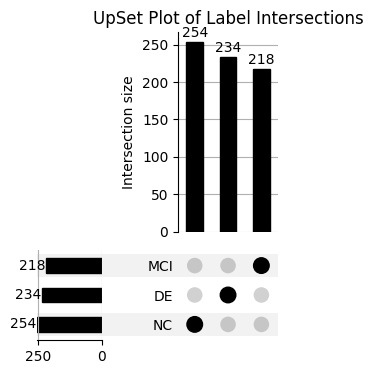

In [24]:
for target in main_labels:
    print(adni_data[target].value_counts())
    print("-"*30)
label_data = adni_data[main_labels].fillna(0).astype(int)
import matplotlib.pyplot as plt
from upsetplot import UpSet, from_indicators

label_data = adni_data[main_labels].fillna(0).astype(bool)

indicator_series = from_indicators(main_labels, label_data)

upset = UpSet(indicator_series, subset_size='count', show_counts='%d')
upset.plot()
plt.title("UpSet Plot of Label Intersections")
plt.savefig(f'./pic/{creative_day}/ADNI_UpSet Plot of Label Intersections')
plt.show()

# ADNI_statistics

In [ ]:

data= pd.read_csv('./dataset/nacc_oasis_merged_data.csv')
label_sum = data[main_labels].sum(axis=1)
multiple_main_labels = data[label_sum > 1]
if not multiple_main_labels.empty:
    print("出现多个NC/MCI/DE标签的病人：")
    print(multiple_main_labels[['ID'] + main_labels ])
else:
    print("所有病人都只有一个三分类标签，数据干净！")
data_cleaned = data[~((data[main_labels].fillna(0).sum(axis=1)) == 0)].reset_index(drop=True)
data = data_cleaned


adni_data= pd.read_csv('./dataset/adni/pre_csv/adni_final0929.csv')
label_sum = adni_data[main_labels].sum(axis=1)
multiple_main_labels = adni_data[label_sum > 1]
if not multiple_main_labels.empty:
    print("出现多个NC/MCI/DE标签的病人：")
    print(multiple_main_labels[['ID'] + main_labels ])
else:
    print("所有病人都只有一个三分类标签，数据干净！")
data_cleaned = adni_data[~((adni_data[main_labels].fillna(0).sum(axis=1)) == 0)].reset_index(drop=True)
adni_data = data_cleaned
for target in main_labels:
    print(adni_data[target].value_counts())
    print("-"*30)

In [ ]:


def clean_data(df):
    df = df.astype(str).replace(['.', '', 'NaN', 'nan', 'null', 'NULL'], np.nan)
    df = df.apply(pd.to_numeric, errors='coerce')
    return df

def calculate_missing_rate(df, name, consider_zero_as_missing=False, detailed=False):
    if df.empty:
        print(f"\n{name} 是空DataFrame，无法计算缺失率。")
        return None
    
    total_rows, total_cols = df.shape
    nan_missing_rate = df.isnull().mean() * 100
    avg_nan_rate = nan_missing_rate.mean()
    num_missing_features = (nan_missing_rate > 0).sum()
    max_nan_rate = nan_missing_rate.max()
    min_nan_rate = nan_missing_rate.min()
    total_nan = df.isnull().sum().sum()
    
    print(f"\n=== {name} 的整体NaN缺失率总结 ===")
    print(f"- 总行数/列数: {total_rows} / {total_cols}")
    print(f"- 平均NaN缺失率: {avg_nan_rate:.2f}%")
    print(f"- 存在缺失的特征数: {num_missing_features} / {total_cols} ({num_missing_features / total_cols * 100:.2f}% of columns)")
    print(f"- 最高NaN缺失率: {max_nan_rate:.2f}% (在列: {nan_missing_rate.idxmax() if not pd.isna(max_nan_rate) else 'N/A'})")
    print(f"- 最低NaN缺失率: {min_nan_rate:.2f}% (在列: {nan_missing_rate.idxmin() if not pd.isna(min_nan_rate) else 'N/A'})")
    print(f"- 总NaN缺失值数量: {total_nan} ({total_nan / (total_rows * total_cols) * 100:.2f}% of all data)")
    
    if detailed:
        print(f"\n{name} 的详细NaN缺失率（%）：")
        print(nan_missing_rate)
    
    if consider_zero_as_missing:
        zero_rate = (df == 0).mean() * 100
        avg_zero_rate = zero_rate.mean()
        num_zero_features = (zero_rate > 0).sum()
        total_zeros = (df == 0).sum().sum()
        
        print(f"\n=== {name} 的整体0值比例总结（视作'缺失'） ===")
        print(f"- 平均0值比例: {avg_zero_rate:.2f}%")
        print(f"- 存在0值的特征数: {num_zero_features} / {total_cols}")
        print(f"- 总0值数量: {total_zeros} ({total_zeros / (total_rows * total_cols) * 100:.2f}% of all data)")
        
        if detailed:
            print(f"\n{name} 的详细0值比例（%）：")
            print(zero_rate)
    
    return nan_missing_rate

def calculate_correlation(df, name):
    numeric_df = df.select_dtypes(include=[np.number]).dropna(axis=1, how='all')
    if numeric_df.empty:
        print(f"\n{name} 无数值列，无法计算相关性。")
        return None
    corr_matrix = numeric_df.corr(method='pearson')
    print(f"\n{name} 的相关性矩阵：")
    print(corr_matrix)
    return corr_matrix

def compare_correlations(corr1, corr2, name1, name2):
    if corr1 is None or corr2 is None:
        print("无法比较相关性：至少一个数据集无有效相关矩阵。")
        return
    common_cols = corr1.columns.intersection(corr2.columns)
    if common_cols.empty:
        print("两个数据集无共同数值列，无法比较。")
        return
    corr1_common = corr1.loc[common_cols, common_cols]
    corr2_common = corr2.loc[common_cols, common_cols]
    diff = np.linalg.norm(corr1_common - corr2_common)
    print(f"\n{name1} 和 {name2} 相关性矩阵的差异（Frobenius范数）：{diff}")

X_nums = data[features]
X_nums = clean_data(X_nums)
X_nums = X_nums.astype(np.float32)
null_count = (X_nums == 0).mean()
num_features = null_count[null_count < 1].index
X_nums = X_nums[num_features]
X_texts = convert_text_to_numeric(data, text_columns)

adni_X_nums = adni_data[features]
adni_X_nums = clean_data(adni_X_nums)
adni_X_nums = adni_X_nums.astype(np.float32)

missing_num_features = [col for col in X_nums.columns if col not in adni_X_nums.columns]
num_missing_num = len(missing_num_features)
if num_missing_num > 0:
    print(f"\n=== adni_X_nums 的完全缺失数值特征总结 ===")
    print(f"- 完全缺失（100%）的数值特征数: {num_missing_num} (列名: {missing_num_features})")

adni_X_texts = convert_text_to_numeric(adni_data, text_columns)

missing_features = [col for col in X_texts.columns if col not in adni_X_texts.columns]
num_missing_text = len(missing_features)
if num_missing_text > 0:
    print(f"\n=== adni_X_texts 的完全缺失文本特征总结 ===")
    print(f"- 完全缺失（100%）的文本特征数: {num_missing_text} (列名: {missing_features})")

print("\n=== 第一个队列的缺失率 ===")
calculate_missing_rate(X_nums, "X_nums", consider_zero_as_missing=True, detailed=False)
calculate_missing_rate(data, "data", consider_zero_as_missing=True, detailed=False)
calculate_missing_rate(X_texts, "X_texts", consider_zero_as_missing=True, detailed=False)

print("\n=== 第二个队列的缺失率 ===")
calculate_missing_rate(adni_X_nums, "adni_X_nums", consider_zero_as_missing=True, detailed=False)
calculate_missing_rate(adni_data, "adni_data", consider_zero_as_missing=True, detailed=False)
calculate_missing_rate(adni_X_texts, "adni_X_texts", consider_zero_as_missing=True, detailed=False)

print("\n=== 相关性计算 ===")
corr_X_nums = calculate_correlation(X_nums, "X_nums")
corr_data = calculate_correlation(data, "data")
corr_X_texts = calculate_correlation(X_texts, "X_texts")

corr_adni_X_nums = calculate_correlation(adni_X_nums, "adni_X_nums")
corr_adni_data = calculate_correlation(adni_data, "adni_data")
corr_adni_X_texts = calculate_correlation(adni_X_texts, "adni_X_texts")

print("\n=== 两个队列的相关性比较 ===")
compare_correlations(corr_X_nums, corr_adni_X_nums, "X_nums", "adni_X_nums")
compare_correlations(corr_data, corr_adni_data, "data", "adni_data")
compare_correlations(corr_X_texts, corr_adni_X_texts, "X_texts", "adni_X_texts")


In [ ]:

def clean_data(df):
    df = df.astype(str).replace(['.', '', 'NaN', 'nan', 'null', 'NULL'], np.nan)
    df = df.apply(pd.to_numeric, errors='coerce')
    return df

def calculate_missing_rate(df, name, consider_zero_as_missing=False, detailed=False):
    if df.empty:
        print(f"\n{name} 是空DataFrame，无法计算缺失率。")
        return None
    
    total_rows, total_cols = df.shape
    nan_missing_rate = df.isnull().mean() * 100
    avg_nan_rate = nan_missing_rate.mean()
    num_missing_features = (nan_missing_rate > 0).sum()
    max_nan_rate = nan_missing_rate.max()
    min_nan_rate = nan_missing_rate.min()
    total_nan = df.isnull().sum().sum()
    
    print(f"\n=== {name} 的整体NaN缺失率总结 ===")
    print(f"- 总行数/列数: {total_rows} / {total_cols}")
    print(f"- 平均NaN缺失率: {avg_nan_rate:.2f}%")
    print(f"- 存在缺失的特征数: {num_missing_features} / {total_cols} ({num_missing_features / total_cols * 100:.2f}% of columns)")
    print(f"- 最高NaN缺失率: {max_nan_rate:.2f}% (在列: {nan_missing_rate.idxmax() if not pd.isna(max_nan_rate) else 'N/A'})")
    print(f"- 最低NaN缺失率: {min_nan_rate:.2f}% (在列: {nan_missing_rate.idxmin() if not pd.isna(min_nan_rate) else 'N/A'})")
    print(f"- 总NaN缺失值数量: {total_nan} ({total_nan / (total_rows * total_cols) * 100:.2f}% of all data)")
    
    if detailed:
        print(f"\n{name} 的详细NaN缺失率（%）：")
        print(nan_missing_rate)
    
    if consider_zero_as_missing:
        zero_rate = (df == 0).mean() * 100
        avg_zero_rate = zero_rate.mean()
        num_zero_features = (zero_rate > 0).sum()
        total_zeros = (df == 0).sum().sum()
        
        print(f"\n=== {name} 的整体0值比例总结（视作'缺失'） ===")
        print(f"- 平均0值比例: {avg_zero_rate:.2f}%")
        print(f"- 存在0值的特征数: {num_zero_features} / {total_cols}")
        print(f"- 总0值数量: {total_zeros} ({total_zeros / (total_rows * total_cols) * 100:.2f}% of all data)")
        
        if detailed:
            print(f"\n{name} 的详细0值比例（%）：")
            print(zero_rate)
    
    return nan_missing_rate

def calculate_correlation(df, name):
    numeric_df = df.select_dtypes(include=[np.number]).dropna(axis=1, how='all')
    if numeric_df.empty:
        print(f"\n{name} 无数值列，无法计算相关性。")
        return None
    corr_matrix = numeric_df.corr(method='pearson')
    print(f"\n{name} 的相关性矩阵：")
    print(corr_matrix)
    return corr_matrix

def compare_correlations(corr1, corr2, name1, name2):
    if corr1 is None or corr2 is None:
        print(f"无法比较 {name1} 和 {name2} 的相关性：至少一个数据集无有效相关矩阵。")
        return
    common_cols = corr1.columns.intersection(corr2.columns)
    if common_cols.empty:
        print(f"{name1} 和 {name2} 无共同数值列，无法比较。")
        return
    corr1_common = corr1.loc[common_cols, common_cols]
    corr2_common = corr2.loc[common_cols, common_cols]
    
    diff_matrix = np.abs(corr1_common - corr2_common)
    mad = np.nanmean(diff_matrix.values)
    
    if np.isnan(mad):
        print(f"{name1} 和 {name2} 相关性矩阵的差异：无法计算（无有效共同元素）。")
    else:
        print(f"\n{name1} 和 {name2} 相关性矩阵的平均绝对差异 (MAD)：{mad:.4f}")
        print("  - MAD 越小，表示两个矩阵越相似（0 为完全相同）。")
        print("  - 这可以说明外部队列（如 adni_data）的数据结构与内部队列相似，因此可用作评估模型的验证集：")
        print("    - 在内部数据上训练模型后，在外部数据上测试性能（e.g., 准确率、损失），以评估泛化能力。")

X_nums = data[features]
X_nums = clean_data(X_nums)
X_nums = X_nums.astype(np.float32)
null_count = (X_nums == 0).mean()
num_features = null_count[null_count < 1].index
X_nums = X_nums[num_features]
X_texts = convert_text_to_numeric(data, text_columns)

adni_X_nums = adni_data[features]
adni_X_nums = clean_data(adni_X_nums)
adni_X_nums = adni_X_nums.astype(np.float32)

missing_num_features = [col for col in X_nums.columns if col not in adni_X_nums.columns]
num_missing_num = len(missing_num_features)
if num_missing_num > 0:
    print(f"\n=== adni_X_nums 的完全缺失数值特征总结 ===")
    print(f"- 完全缺失（100%）的数值特征数: {num_missing_num} (列名: {missing_num_features})")

adni_X_texts = convert_text_to_numeric(adni_data, text_columns)

missing_features = [col for col in X_texts.columns if col not in adni_X_texts.columns]
num_missing_text = len(missing_features)
if num_missing_text > 0:
    print(f"\n=== adni_X_texts 的完全缺失文本特征总结 ===")
    print(f"- 完全缺失（100%）的文本特征数: {num_missing_text} (列名: {missing_features})")

print("\n=== 第一个队列的缺失率 ===")
calculate_missing_rate(X_nums, "X_nums", consider_zero_as_missing=True, detailed=False)
calculate_missing_rate(data, "data", consider_zero_as_missing=True, detailed=False)
calculate_missing_rate(X_texts, "X_texts", consider_zero_as_missing=True, detailed=False)

print("\n=== 第二个队列的缺失率 ===")
calculate_missing_rate(adni_X_nums, "adni_X_nums", consider_zero_as_missing=True, detailed=False)
calculate_missing_rate(adni_data, "adni_data", consider_zero_as_missing=True, detailed=False)
calculate_missing_rate(adni_X_texts, "adni_X_texts", consider_zero_as_missing=True, detailed=False)

print("\n=== 相关性计算 ===")
corr_X_nums = calculate_correlation(X_nums, "X_nums")
corr_data = calculate_correlation(data, "data")
corr_X_texts = calculate_correlation(X_texts, "X_texts")

corr_adni_X_nums = calculate_correlation(adni_X_nums, "adni_X_nums")
corr_adni_data = calculate_correlation(adni_data, "adni_data")
corr_adni_X_texts = calculate_correlation(adni_X_texts, "adni_X_texts")

print("\n=== 两个队列的相关性比较 ===")
compare_correlations(corr_X_nums, corr_adni_X_nums, "X_nums", "adni_X_nums")
compare_correlations(corr_data, corr_adni_data, "data", "adni_data")
compare_correlations(corr_X_texts, corr_adni_X_texts, "X_texts", "adni_X_texts")


# ADNI_all_statistics

In [ ]:
print(adni_data['Visit_Age'].head())
is_all_missing = adni_data['Visit_Age'].isna().all()

if is_all_missing:
    print("'his_RACE' 列完全缺失")
else:
    print("'his_RACE' 列不是完全缺失的")



In [ ]:
race_counts = adni_data['his_RACE'].value_counts()

race_percentage = (race_counts / race_counts.sum()) * 100

print("\nRace distribution:")
for race, count in race_counts.items():
    print(f"{race}: {count} ({race_percentage[race]:.2f}%)")

In [ ]:
def format_p_value(p_value):
    if p_value < 1e-300:
        p_value = 1e-300
    return f"{p_value:.4e}"

labels = [
    "NC",
    "MCI",
    "DE"
]

race_mapping = {
    'whi': 'White',
    'blk': 'Black',
    'asi': 'Asian',
    'ind': 'American Indian',
    'oth': 'multirace',
    'haw': 'Pacific',
    'White': 'White',
    'Black': 'Black',
    'ASIAN': 'Asian',
    'more than one': 'multirace',
    'AIAN': 'American Indian'
}

adni_count = adni_data['IDage'].str.contains('ADNI', na=False).sum()
print(f"ADNI 队列数量: {adni_count}")

adni_data['his_RACE_mapped'] = adni_data['his_RACE'].map(race_mapping).fillna('multirace')

adni_t1_exist_count = adni_data['t1_path'].apply(os.path.exists).sum()
adni_t2_exist_count = adni_data['t2_path'].apply(os.path.exists).sum()

print(f"ADNI 队列中 t1_path 文件存在的行数: {adni_t1_exist_count}")
print(f"ADNI 队列中 t2_path 文件存在的行数: {adni_t2_exist_count}")

adni_age_mean = adni_data['Visit_Age'].mean()
adni_age_std = adni_data['Visit_Age'].std()
print(f"ADNI Age: mean ± s.d. = {adni_age_mean:.2f} ± {adni_age_std:.2f}")

adni_sex_counts = adni_data['his_SEX'].value_counts()
adni_sex_percentage = (adni_sex_counts / adni_sex_counts.sum()) * 100
print("\nADNI Sex distribution:")
for sex, count in adni_sex_counts.items():
    print(f"{sex}: {count} ({adni_sex_percentage[sex]:.2f}%)")

adni_educ_mean = adni_data['his_EDUC'].mean()
adni_educ_std = adni_data['his_EDUC'].std()
print(f"\nADNI Education (years): mean ± s.d. = {adni_educ_mean:.2f} ± {adni_educ_std:.2f}")

adni_race_counts = adni_data['his_RACE_mapped'].value_counts()
adni_race_percentage = (adni_race_counts / adni_race_counts.sum()) * 100
print("\nADNI Race distribution:")
for race, count in adni_race_counts.items():
    print(f"{race}: {count} ({adni_race_percentage[race]:.2f}%)")

adni_cdr_counts = adni_data['cdr_CDRGLOB'].value_counts()
adni_cdr_percentage = (adni_cdr_counts / adni_cdr_counts.sum()) * 100
print("\nADNI CDR distribution:")
for cdr, count in adni_cdr_counts.items():
    print(f"{cdr}: {count} ({adni_cdr_percentage[cdr]:.2f}%)")

print("\nADNI 标签分布情况:")
for target in labels:
    if target in adni_data.columns:
        counts = adni_data[target].value_counts()
        total = counts.sum()
        percentage = (counts / total) * 100 if total > 0 else pd.Series()
        print(f"标签: {target}")
        for val, count in counts.items():
            print(f"  {val}: {count} ({percentage.get(val, 0):.2f}%)")
        print(f"  总计: {total}")
        print("-" * 30)
    else:
        print(f"警告: 列 '{target}' 在 ADNI 数据中不存在，跳过。")

print("\n组间 P 值计算 (针对 ADNI 队列的所有非空诊断标签子集):")

subsets = {}
for target in labels:
    if target in adni_data.columns:
        subset = adni_data[adni_data[target] == 1]
        if not subset.empty:
            subsets[target] = subset

if len(subsets) < 2:
    print("不足 2 个非空子集，无法计算 P 值。")
else:
    age_groups = [subset['Visit_Age'].dropna().values for subset in subsets.values()]
    educ_groups = [subset['his_EDUC'].dropna().values for subset in subsets.values()]
    cdr_groups = [subset['cdr_CDRGLOB'].dropna().values for subset in subsets.values()]

    age_p = stats.f_oneway(*age_groups).pvalue if all(len(g) > 0 for g in age_groups) else np.nan
    educ_p = stats.f_oneway(*educ_groups).pvalue if all(len(g) > 0 for g in educ_groups) else np.nan
    cdr_p = stats.f_oneway(*cdr_groups).pvalue if all(len(g) > 0 for g in cdr_groups) else np.nan

    male_table = np.array([
        [(subset['his_SEX'] == 'male').sum(), len(subset) - (subset['his_SEX'] == 'male').sum()]
        for subset in subsets.values()
    ])
    if np.any(male_table):
        _, male_p, _, _ = stats.chi2_contingency(male_table)
    else:
        male_p = np.nan

    race_table = np.array([
        [subset['his_RACE_mapped'].value_counts().get(cat, 0) for cat in race_mapping.values()]
        for subset in subsets.values()
    ])
    if np.any(race_table):
        _, race_p, _, _ = stats.chi2_contingency(race_table)
    else:
        race_p = np.nan

    print(f"Age P-value (ANOVA): {format_p_value(age_p)} {'(显著差异)' if age_p < 0.05 else '(无显著差异)'}")
    print(f"Male P-value (Chi-square): {format_p_value(male_p)} {'(显著差异)' if male_p < 0.05 else '(无显著差异)'}")
    print(f"Education P-value (ANOVA): {format_p_value(educ_p)} {'(显著差异)' if educ_p < 0.05 else '(无显著差异)'}")

